---

# 스프린트미션13 3팀_김명환

- 미션 소개
    - 쇼핑몰 리뷰 데이터를 대상으로 감성 분석을 해 보는 미션입니다.
    - 데이터 로드 및 전처리부터 모델 학습과 성능 평가까지 전부 구현하면 됩니다.
    - 모델을 학습시킬 때는 Full Fine-Tuning 방식과 PEFT 방식을 모두 활용해 보고 두 방식에 어떤 차이가 있는지 확인해 보세요.
        - 예를 들어 모델을 학습시키는 데 걸리는 시간, 같은 조건으로 학습시켰을 때 감성 분석 정확도, 저장되는 모델 파일의 용량 등을 비교해 볼 수 있습니다.
- 사용 데이터셋
    - 먼저 이번 미션에 사용할 데이터 셋을 다운로드 받아주세요. (약 40MB)
- 데이터 형식:
    - JSON 파일 형태로 제공되는 리뷰 데이터입니다. JSON 파일 하나에 여러 개의 리뷰가 포함되어 있어요.
    - JSON 파일에서 리뷰 텍스트는 RawText에 있고, 리뷰에 대한 긍부정 라벨은 GeneralPolarity에 있습니다. GeneralPolarity 값은 -1일 때 부정, 0일 때 중립, 1일 때 긍정을 뜻합니다.
- 데이터 구성:
    - 패션, 화장품, 가전, IT기기, 생활 5가지 분야에 대해 쇼핑몰과 SNS에 달린 리뷰입니다. 원하는 분야의 리뷰를 선택하여 모델을 학습시키고 성능을 평가해 보세요.
- 가이드라인
    - 데이터 로드 및 전처리
        - 리뷰 데이터를 로드하고, 감성 분석 모델을 학습시키기 위한 형식으로 적절하게 변환합니다.
        - 전체 데이터를 학습 데이터와 테스트 데이터로 분할합니다.
    - Full Fine-Tuning 방식으로 모델 학습
        - Hugging Face의 transformers 라이브러리를 활용해 감성 분석 모델을 학습시킵니다.
    - PEFT 방식으로 모델 학습
        - Hugging Face의 peft 라이브러리를 추가로 활용해 PEFT 방식으로 감성 분석 모델을 학습시킵니다.
    - 두 가지 학습 방식 비교
        - Full Fine-Tuning 방식과 PEFT 방식의 학습 속도를 비교해 보세요.
        - 각 방식으로 학습시킨 모델 파일을 저장한 뒤 용량을 비교해 보세요.
        - 리뷰 텍스트의 실제 라벨과 모델이 예측한 결과를 비교하여 감성 분석 모델의 성능을 평가합니다.
        - 두 가지 학습 방식 사이에 정확도 차이가 있는지 확인해 보세요.
    - 마크다운 설명
        - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운 셀을 통해 간결하게 기록하세요.
        - 코드와 결과를 한눈에 이해할 수 있도록 전체 워크플로우를 체계적으로 정리해 주세요.
- 제출 안내
    - Colab Notebook 파일을 제출해 주세요.
    - 파일 이름은 13_{팀명}_{성함}.ipynb 형태로 작성해 주세요.
- 모델 구현 및 학습 결과
    - 주어진 데이터에 대한 감성 분석 모델을 구현해 주세요. 데이터 로드 → 전처리 → 모델 구축 및 학습 → 성능 평가 과정을 순차적으로 진행하세요.
- 마크다운을 활용한 설명
    - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
    - 노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해 주세요.
- Full Fine-Tuning과 PEFT 방식 비교 분석 및 제출
    - 두 가지 학습 방식에 어떤 차이가 있는지 비교 분석해 보고 그 결과를 정리해 주세요.

---
---

## 1. 실험 개요

### 1.1. 미션 목표

#### 1.1.1. 감성 분석 모델 학습 및 평가

미션의 주요 목표는 쇼핑몰 리뷰 데이터를 활용하여 감성 분석(Sentiment Analysis) 모델을 학습시키고 성능을 평가하는 것입니다. 감성 분석은 텍스트 데이터에서 작성자의 감정이나 의견을 자동으로 분류하는 자연어 처리(Natural Language Processing, NLP) 작업으로, 고객 피드백 분석, 제품 리뷰 모니터링, 브랜드 평판 관리 등 다양한 실무 분야에서 활용됩니다.

이 미션에서는 리뷰 텍스트를 **긍정(Positive)**, **중립(Neutral)**, **부정(Negative)** 세 가지 클래스로 분류하는 다중 클래스 분류(Multi-class Classification) 문제를 해결합니다.

#### 1.1.2. Full Fine-Tuning vs PEFT 방식 비교

최근 대규모 언어 모델(Large Language Model, LLM)의 발전으로 사전 학습된 모델을 활용한 전이 학습(Transfer Learning)이 일반화되었습니다. 미션의 핵심 목표는 두 가지 주요 파인튜닝(Fine-tuning) 방식을 비교하는 것입니다:

1. **풀 파인튜닝(Full Fine-Tuning)**: 사전 학습된 모델의 모든 파라미터를 업데이트하는 전통적인 방식
2. **펫(PEFT, Parameter-Efficient Fine-Tuning)**: 모델의 일부 파라미터만 업데이트하거나 추가하는 효율적인 방식

이 두 방식을 다음 측면에서 비교 분석합니다:
- **성능**: 감성 분석 정확도 및 F1 점수
- **효율성**: 학습 시간 및 계산 자원 사용량
- **모델 크기**: 저장되는 모델 파일의 용량
- **실용성**: 실무 환경에서의 적용 가능성

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/112FullFine-TuningvsPEFT방식비교.png" width="400px"/>

### 1.2. 사용 데이터셋

#### 1.2.1. 데이터 기본 정보

미션에서 사용한 데이터셋은 **AI-Hub에서 제공하는 속성 기반 감정 분석 데이터**입니다. 이 데이터셋은 실제 쇼핑몰과 소셜 미디어(SNS)에 작성된 리뷰를 수집하여 감성 라벨을 부여한 것으로, 한국어 자연어 처리 연구 및 실무에 널리 활용됩니다.

| 번호 | 측정항목 | AI TASK | 학습모델 | 지표명 | 기준값 점수 | 측정값 점수 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | 속성 분류 모델 성능 | Text Classification | BERT | F1-Score | 0.8 점 | 0.8018 점 |
| 2 | 감정 분석 모델 성능 | Text Classification | BERT | F1-Score | 0.8 점 | 0.8414 점 |

**데이터 형식:**
- **파일 형태**: JSON 형식
- **텍스트 필드**: `RawText` - 리뷰 원문
- **라벨 필드**: `GeneralPolarity` - 감성 라벨
  - `-1`: 부정(Negative)
  - `0`: 중립(Neutral)
  - `1`: 긍정(Positive)

**전처리 후 데이터 통계:**
- **전체 샘플 수**: 184,525개 (원본 201,616개에서 결측치 제거)
- **최대 토큰 길이**: 128 토큰
- **데이터 분할**: 80% 학습(147,620개), 20% 테스트(36,905개)

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/mission_13_eda.png" width="800px"/>

**학습 데이터**
- **메타정보 포함**: 원천 데이터를 JSONL 형식으로 변환하며 전처리 규칙, 레이블 정보 등 메타데이터 포함

```
├─ version [str]: 1.0.0
├─ created_at [str]: 2025-10-29T15:00:44.179671+09:00
├─ author [str]: 코드잇 AI4기 김명환
├─ source [dict]
│  ├─ original_file [str]: review-sentiment-analysis.zip
│  ├─ total_samples [int]: 184525
│  ├─ excluded_samples [int]: 17091
├─ preprocessing [dict]
│  ├─ clean_text_steps [list]
│  │  ├─ [0] [str]: HTML 태그 제거: <[^>]+>
│  │  ├─ [1] [str]: URL 제거: https?://\S+
│  │  ├─ [2] [str]: 이모지 제거: [^\w\sㄱ-ㅎㅏ-ㅣ가-힣]
│  │  ├─ [3] [str]: 감정 표현 보존: ['ㅠㅠ', 'ㅜㅜ', 'ㅎㅎ', 'ㅇㅇ', 'ㄷㄷ', 'ㄱㄱ', 'ㄹㄹ', 'ㅈㅈ', 'ㅁㄹ', 'ㅇㄴ']
│  │  ├─ [4] [str]: 연속 공백 제거: \s+
│  ├─ label_mapping [dict]
│  │  ├─ -1 [int]: 0
│  │  ├─ 0 [int]: 1
│  │  ├─ 1 [int]: 2
├─ statistics [dict]
│  ├─ label_distribution [dict]
│  │  ├─ 0 [int]: 28063
│  │  ├─ 1 [int]: 37592
│  │  ├─ 2 [int]: 118870
│  ├─ domains [list]
│  │  ├─ [0] [str]: IT기기
│  │  ├─ [1] [str]: 가전
│  │  ├─ [2] [str]: 생활
│  │  ├─ [3] [str]: 패션
│  │  ├─ [4] [str]: 화장품
│  ├─ sources [list]
│  │  ├─ [0] [str]: SNS
│  │  ├─ [1] [str]: 쇼핑몰
│  ├─ categories [list]
│  │  ├─ [0] [str]: 계절가전
│  │  ├─ [1] [str]: 남성의류
│  │  ├─ [2] [str]: 남성화장품
│  │  ├─ [3] [str]: 메이크업/뷰티소품
│  │  ├─ [4] [str]: 생활/미용/욕실가전
│  │  ├─ [5] [str]: 세제/세정/탈취제
│  │  ├─ [6] [str]: 스킨케어
│  │  ├─ [7] [str]: 여성의류
│  │  ├─ [8] [str]: 영상/음향가전
│  │  ├─ [9] [str]: 위생용품
│  │  ├─ [10] [str]: 자동차기기
│  │  ├─ [11] [str]: 잡화
│  │  ├─ [12] [str]: 주방가전
│  │  ├─ [13] [str]: 주방용품
│  │  ├─ [14] [str]: 청소/세탁용품
│  │  ├─ [15] [str]: 카메라/게임기/태블릿
│  │  ├─ [16] [str]: 컴퓨터/주변기기
│  │  ├─ [17] [str]: 패션슈즈
│  │  ├─ [18] [str]: 헤어/바디케어
│  │  ├─ [19] [str]: 휴대폰/주변기기
```

#### 1.2.2. 레이블 분포 및 불균형 문제

데이터셋의 가장 큰 특징 중 하나는 **클래스 불균형(Class Imbalance)** 문제입니다. 실제 쇼핑몰 리뷰의 특성상 긍정 리뷰가 압도적으로 많으며, 이는 감성 분석 모델 학습에 중요한 도전 과제입니다.

**레이블 분포:**

| 레이블 | 클래스 | 샘플 수 | 비율 |
|--------|--------|---------|------|
| 2 | 긍정(Positive) | 118,870 | 64.4% |
| 1 | 중립(Neutral) | 37,592 | 20.4% |
| 0 | 부정(Negative) | 28,063 | 15.2% |

이러한 불균형은 모델이 다수 클래스(긍정)에 편향되는 문제를 야기할 수 있습니다. 이를 해결하기 위해 **클래스 가중치(Class Weights)** 적용 여부에 따른 성능 변화를 실험했습니다.

클래스 가중치는 다음 공식으로 계산됩니다:

$$
w_i = \frac{N}{k \cdot n_i}
$$

* 여기서
   - $w_i$: 클래스 $i$의 가중치
   - $N$: 전체 샘플 수
   - $k$: 클래스 개수
   - $n_i$: 클래스 $i$의 샘플 수

#### 1.2.3. 도메인 및 출처 구성

데이터셋은 다양한 상품 카테고리와 출처를 포함하여 모델의 일반화 성능을 높이도록 구성되었습니다.

**상품 도메인:**
- 패션(Fashion)
- 화장품(Cosmetics)
- 가전제품(Electronics)
- IT 기기(IT Devices)
- 생활용품(Lifestyle)

**데이터 출처:**
- 쇼핑몰 리뷰
- SNS 게시글

이러한 다양성은 모델이 특정 도메인에 과적합(Overfitting)되지 않고 다양한 상품 카테고리에서 작동할 수 있도록 합니다.

### 1.3. 평가 지표

#### 1.3.1. 분류 성능 지표

감성 분석 모델의 성능을 평가하기 위해 다음 지표들을 사용했습니다:

**1) 정확도(Accuracy)**

전체 예측 중 올바르게 분류한 비율을 나타냅니다:

$$
\text{Accuracy} = \frac{\text{올바르게 예측한 샘플 수}}{\text{전체 샘플 수}} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**2) 정밀도(Precision)**

모델이 특정 클래스로 예측한 것 중 실제로 그 클래스인 비율입니다:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**3) 재현율(Recall)**

실제 특정 클래스인 샘플 중 모델이 올바르게 예측한 비율입니다:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**4) F1 점수(F1-Score)**

정밀도와 재현율의 조화 평균으로, 두 지표의 균형을 평가합니다:

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**5) 매크로 F1 점수(Macro F1-Score)**

각 클래스별 F1 점수의 산술 평균으로, 클래스 불균형 상황에서 중요한 지표입니다:

$$
F1_{\text{macro}} = \frac{1}{k} \sum_{i=1}^{k} F1_i
$$

불균형 데이터셋에서는 정확도만으로는 모델의 실제 성능을 파악하기 어렵습니다. 예를 들어, 모든 샘플을 긍정으로 예측해도 64.4%의 정확도를 달성할 수 있습니다. 따라서 **Macro F1-Score**를 주요 평가 지표로 사용했습니다.

#### 1.3.2. 효율성 지표

실무 환경에서는 성능뿐만 아니라 효율성도 중요한 고려 사항입니다. 다음 지표들로 각 방법의 효율성을 평가했습니다:

**1) 학습 시간(Training Duration)**
- 전체 학습에 소요된 시간(초 단위)
- GPU 메모리 사용량 및 처리량

**2) 모델 크기(Model Size)**
- Full Fine-Tuning: 전체 모델 파라미터 저장
- PEFT: 어댑터(Adapter) 파라미터만 저장
- 저장 공간 및 배포 효율성

**3) 학습 가능한 파라미터 수(Trainable Parameters)**
- Full Fine-Tuning: 약 111M 파라미터
- PEFT (LoRA/DoRA): 약 0.3M~0.6M 파라미터 (r=8 기준)
- 파라미터 효율성 비율: ~0.5% (PEFT가 약 99.5% 파라미터 절감)



---


## 2. 실험 설계

### 2.1. 모델 아키텍처

#### 2.1.1. 베이스 모델: KLUE-RoBERTa

본 실험에서는 **KLUE-RoBERTa-base** 모델을 베이스 모델로 사용했습니다. 이 모델은 한국어 자연어 이해 벤치마크인 KLUE(Korean Language Understanding Evaluation)를 위해 개발된 사전 학습 모델로, 한국어 텍스트 처리에 최적화되어 있습니다.

**모델 사양:**
- **아키텍처**: RoBERTa (Robustly Optimized BERT Pretraining Approach)
- **파라미터 수**: 약 111M
- **히든 레이어 크기**: 768
- **어텐션 헤드 수**: 12
- **히든 레이어 개수**: 12
- **최대 시퀀스 길이**: 512
- **어휘 크기**: 32,000

- **미션에서는 최대 시퀀스 길이**: 128 사용
   - 생활 도메인의 경우 장문 리뷰 비율이 높아 일부 잘림 발생 가능
   - 그러나 감성 분석에서 주요 감정 표현은 앞부분에 집중되는 경향
   - 실험 결과 128로 충분한 성능 확보 (Accuracy 0.8 이상)

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/mission_13_token_distribution_analysis.png" width="800px"/>

**선택 이유:**
1. 한국어 데이터로 사전 학습되어 한국어 리뷰 분석에 적합
2. BERT 대비 개선된 학습 방법으로 더 나은 성능
3. Hugging Face Transformers 라이브러리에서 쉽게 사용 가능
4. 실무에서 널리 검증된 모델

#### 2.1.2. 분류 헤드 구성

감성 분석을 위해 사전 학습된 RoBERTa 인코더 위에 분류 헤드(Classification Head)를 추가했습니다:

```
[CLS] 토큰 임베딩 (768차원)
    ↓
Dropout (0.1)
    ↓
Linear Layer (768 → 3)
    ↓
Softmax
    ↓
[부정, 중립, 긍정] 확률 분포
```

### 2.2. 학습 방식 비교

#### 2.2.1. Full Fine-Tuning 방식

**개념:**

풀 파인튜닝(Full Fine-Tuning)은 사전 학습된 모델의 **모든 파라미터**를 다운스트림 태스크(Downstream Task)에 맞게 업데이트하는 전통적인 전이 학습 방식입니다.

**특징:**
- 모든 레이어의 가중치가 업데이트됨
- 태스크에 가장 적합하게 모델을 조정 가능
- 높은 표현력(Expressiveness)
- 많은 계산 자원 및 메모리 필요
- 과적합 위험 존재 (특히 데이터가 적을 때)

**학습 과정:**

각 배치에 대해 다음 단계를 수행합니다:

1. 순전파(Forward Pass): 입력 → RoBERTa 인코더 → 분류 헤드 → 예측
2. 손실 계산: Cross-Entropy Loss
3. 역전파(Backward Pass): 그래디언트 계산
4. 파라미터 업데이트: 모든 레이어의 가중치 업데이트

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}(\theta_t)
$$

* 여기서
   - $\theta$: 모든 모델 파라미터 (약 111M)
   - $\eta$: 학습률 (2e-5)
   - $\mathcal{L}$: 크로스 엔트로피 손실 함수

#### 2.2.2. PEFT 방식 (LoRA, DoRA)

**개념:**

펫(PEFT, Parameter-Efficient Fine-Tuning)은 사전 학습된 모델의 대부분의 파라미터를 고정(Freeze)하고, **소수의 파라미터만 학습**하거나 **추가적인 파라미터를 주입**하는 효율적인 파인튜닝 방식입니다.

**장점:**
- 학습 및 저장 비용 대폭 감소 (파라미터의 0.5% 수준)
- 학습 속도 향상
- 과적합 위험 감소
- 여러 태스크에 대한 어댑터 관리 용이

**단점:**
- Full Fine-Tuning 대비 약간의 성능 하락 가능성
- 하이퍼파라미터 튜닝 필요 (rank, alpha 등)

**본 실험에서 사용한 PEFT 방법:**

1. **로라(LoRA, Low-Rank Adaptation)**
2. **도라(DoRA, Weight-Decomposed Low-Rank Adaptation)**

##### 2.2.2.1. LoRA (Low-Rank Adaptation)

**원리:**

LoRA는 사전 학습된 가중치 행렬 $W_0$를 고정하고, 저랭크(Low-Rank) 분해를 통해 얻은 두 개의 작은 행렬 $A$와 $B$의 곱을 더하는 방식입니다:

$$
W = W_0 + \Delta W = W_0 + BA
$$

* 여기서
   - $W_0 \in \mathbb{R}^{d \times k}$: 고정된 사전 학습 가중치
   - $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$: 학습 가능한 저랭크 행렬
   - $r \ll \min(d, k)$: 랭크(Rank), 어댑터의 크기 결정
   - $\Delta W = BA$: 학습되는 가중치 변화량

**학습 과정:**

1. $W_0$는 고정 (gradient 계산 안 함)
2. $A$와 $B$만 학습
3. 추론 시: $W_0 + BA$를 하나의 행렬로 병합 가능 (추가 지연 없음)

**스케일링:**

LoRA는 학습 안정성을 위해 스케일링 팩터 $\alpha$를 사용합니다:

$$
h = W_0 x + \frac{\alpha}{r} BA x
$$

* 여기서
   - $\alpha$: 스케일링 하이퍼파라미터 (보통 $r$의 배수)
   - $\frac{\alpha}{r}$: 실제 스케일링 비율

**파라미터 수:**

- Full model: $d \times k$
- LoRA: $r \times (d + k)$
- 비율: $\frac{r \times (d + k)}{d \times k} \approx \frac{r}{d}$ (when $d \approx k$)

예: $d=768$, $k=768$, $r=8$일 때:
- Full: 589,824 파라미터
- LoRA: 12,288 파라미터 (약 2.1%)

##### 2.2.2.2. DoRA (Weight-Decomposed Low-Rank Adaptation)

**원리:**

DoRA는 LoRA를 확장한 방법으로, 가중치를 **크기(Magnitude)**와 **방향(Direction)**으로 분해하여 각각 다르게 학습합니다:

$$
W = m \frac{V + \Delta V}{\|V + \Delta V\|_c}
$$

* 여기서
   - $m$: 가중치의 크기 (학습 가능)
   - $V$: 사전 학습된 가중치의 방향
   - $\Delta V = BA$: LoRA와 동일한 저랭크 업데이트
   - $\|\cdot\|_c$: 열 기준 정규화

**LoRA와의 차이점:**

1. **방향과 크기 분리**: 모델이 각각을 독립적으로 조정 가능
2. **추가 파라미터**: 크기 벡터 $m$이 추가로 학습됨
3. **더 나은 표현력**: 특히 복잡한 태스크에서 우수한 성능
4. **약간 더 많은 계산**: 정규화 연산 추가

**파라미터 수:**

- DoRA: LoRA + 크기 벡터 $m$ (출력 차원 $d$)
- 예: LoRA 12,288 + 768 = 13,056 파라미터

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/22학습방식비교.png" width="800px"/>

### 2.3. 실험 시나리오

본 실험에서는 총 **10가지 주요 시나리오**를 설계하여 다양한 학습 방식과 하이퍼파라미터 조합의 효과를 비교했습니다.

#### 2.3.1. Full Fine-Tuning 시나리오

| 시나리오 ID | 설명 | 클래스 가중치 |
|-------------|------|---------------|
| `251029_210000_w` | Full Fine-Tuning with weights | 적용 (w) |
| `251029_210000_nw` | Full Fine-Tuning without weights | 미적용 (nw) |

#### 2.3.2. LoRA 시나리오

| 시나리오 ID | Rank (r) | Alpha (α) | 클래스 가중치 |
|-------------|----------|-----------|---------------|
| `251029_210000_lora_r8_a8_w` | 8 | 8 | 적용 (w) |
| `251029_210000_lora_r8_a8_nw` | 8 | 8 | 미적용 (nw) |
| `251029_210000_lora_r8_a16_w` | 8 | 16 | 적용 (w) |
| `251029_210000_lora_r8_a16_nw` | 8 | 16 | 미적용 (nw) |

#### 2.3.3. DoRA 시나리오

| 시나리오 ID | Rank (r) | Alpha (α) | 클래스 가중치 |
|-------------|----------|-----------|---------------|
| `251029_210000_dora_r8_a8_w` | 8 | 8 | 적용 (w) |
| `251029_210000_dora_r8_a8_nw` | 8 | 8 | 미적용 (nw) |
| `251029_210000_dora_r8_a16_w` | 8 | 16 | 적용 (w) |
| `251029_210000_dora_r8_a16_nw` | 8 | 16 | 미적용 (nw) |

#### 2.3.4. 실험 변수

본 실험에서 조작한 주요 변수는 다음과 같습니다:

**1) 학습 방식 (Training Method)**
- Full Fine-Tuning
- LoRA
- DoRA

**2) 랭크 값 (Rank, r)**
- r = 8 (고정)
- 랭크가 클수록 표현력 증가, 파라미터 수 증가

**3) 알파 값 (Alpha, α)**
- α = 8
- α = 16
- 알파가 클수록 어댑터의 영향력 증가

**4) 클래스 가중치 (Class Weights)**
- w (with weights): 클래스 불균형 보정 적용
- nw (no weights): 가중치 미적용

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/22학습방식비교-1.png" width="800px"/>

### 2.4. 하이퍼파라미터 설정

#### 2.4.1. 공통 학습 설정

모든 실험에서 공정한 비교를 위해 다음 하이퍼파라미터를 동일하게 적용했습니다:

| 하이퍼파라미터 | 값 | 설명 |
|----------------|-----|------|
| **학습률 (Learning Rate)** | 2e-5 | AdamW 옵티마이저 학습률 |
| **배치 크기 (Batch Size)** | 32 | 학습 및 평가 배치 크기 |
| **에포크 (Epochs)** | 3 | 전체 데이터를 3회 반복 학습 |
| **최대 시퀀스 길이 (Max Length)** | 128 | 토큰화 후 최대 길이 |
| **Warmup 비율** | 0.1 | 전체 스텝의 10% |
| **Weight Decay** | 0.01 | L2 정규화 계수 |
| **Gradient Clipping** | 1.0 | 그래디언트 최대 노름 |
| **옵티마이저** | AdamW | Adam with Weight Decay |
| **스케줄러** | Linear | 선형 학습률 감소 |

#### 2.4.2. 학습률 스케줄링

학습 안정성과 수렴 성능을 위해 **Warmup + Linear Decay** 스케줄을 사용했습니다:

1. **Warmup 단계** (전체 스텝의 10%):
   - 학습률을 0에서 2e-5까지 선형적으로 증가
   - 초기 학습 불안정성 방지

2. **Decay 단계** (나머지 90%):
   - 학습률을 2e-5에서 0으로 선형적으로 감소
   - 미세 조정(Fine-grained Tuning) 가능

$$
\eta(t) = \begin{cases}
\eta_{\max} \cdot \frac{t}{t_{\text{warmup}}} & \text{if } t \leq t_{\text{warmup}} \\
\eta_{\max} \cdot \frac{t_{\max} - t}{t_{\max} - t_{\text{warmup}}} & \text{if } t > t_{\text{warmup}}
\end{cases}
$$

#### 2.4.3. PEFT 전용 하이퍼파라미터

**LoRA / DoRA 공통:**

| 하이퍼파라미터 | 값 | 설명 |
|----------------|-----|------|
| **Rank (r)** | 8 | 저랭크 행렬의 랭크 |
| **Alpha (α)** | 8, 16 | 스케일링 팩터 |
| **Dropout** | 0.1 | LoRA 레이어 드롭아웃 |
| **타겟 모듈** | `query`, `value` | 어댑터를 적용할 어텐션 모듈 |
| **바이어스** | `none` | 바이어스 학습 안 함 |

**타겟 모듈 선택:**

셀프 어텐션(Self-Attention) 메커니즘의 쿼리(Query)와 밸류(Value) 프로젝션에만 LoRA/DoRA를 적용했습니다. 이는 다음 이유 때문입니다:

1. **효율성**: 모든 레이어에 적용하는 것보다 파라미터 효율적
2. **성능**: 쿼리와 밸류가 어텐션 패턴에 가장 큰 영향
3. **검증됨**: 기존 연구에서 효과적임이 입증됨

#### 2.4.4. 클래스 가중치 계산

클래스 불균형을 보정하기 위한 가중치는 다음과 같이 계산했습니다:

$$
w_{\text{부정}} = \frac{184,525}{3 \times 28,063} \approx 2.19
$$

$$
w_{\text{중립}} = \frac{184,525}{3 \times 37,592} \approx 1.64
$$

$$
w_{\text{긍정}} = \frac{184,525}{3 \times 118,870} \approx 0.52
$$

손실 함수에 적용:

$$
\mathcal{L}_{\text{weighted}} = -\sum_{i=1}^{N} w_{y_i} \log(\hat{y}_i)
$$

#### 2.4.5. 정규화 기법

과적합 방지를 위해 다음 정규화 기법들을 사용했습니다:

1. **Dropout (0.1)**: 분류 헤드와 LoRA/DoRA 레이어
2. **Weight Decay (0.01)**: L2 정규화
3. **Gradient Clipping (1.0)**: 그래디언트 폭발 방지
4. **Early Stopping**: 검증 손실이 증가하면 조기 종료 (본 실험에서는 3 에포크 고정)


---


## 3. 실험 결과

### 3.1. 전체 실험 결과 요약 테이블

다음은 모든 실험 시나리오의 성능 지표를 요약한 테이블입니다. 주요 지표는 **Evaluation Accuracy**와 **Evaluation Macro F1**입니다.

| Rank | 실험 이름 | 학습 시간 (초) | Eval Accuracy | Eval Macro F1 | F1 긍정 | F1 부정 | F1 중립 | 카테고리 정확도 | 도메인 정확도 |
|------|-----------|----------------|---------------|---------------|---------|---------|---------|-----------------|---------------|
| 1 | **251029_210000_nw** | 1,378.9 | **0.9136** | **0.8823** | 0.9548 | 0.9024 | 0.7895 | 0.9177 | 0.9162 |
| 2 | **251029_210000_dora_r8_a16_nw** | 1,277.5 | **0.8987** | **0.8638** | 0.9458 | 0.8858 | 0.7599 | 0.9057 | 0.9039 |
| 3 | **251029_210000_lora_r8_a16_nw** | 995.3 | **0.8981** | **0.8628** | 0.9456 | 0.8834 | 0.7595 | 0.9065 | 0.9042 |
| 4 | **251029_210000_dora_r8_a8_nw** | 1,277.9 | 0.8971 | 0.8615 | 0.9452 | 0.8827 | 0.7563 | 0.9052 | 0.9033 |
| 5 | **251029_210000_lora_r8_a8_nw** | 996.0 | 0.8968 | 0.8600 | 0.9452 | 0.8803 | 0.7545 | 0.9060 | 0.9041 |
| 6 | **251029_210000_w** | 1,377.2 | 0.8951 | 0.8690 | 0.9404 | 0.8908 | 0.7760 | 0.9012 | 0.9004 |
| 7 | 251029_210000_lora_r8_a16_w | 995.3 | 0.8908 | 0.8628 | 0.9379 | 0.8861 | 0.7643 | 0.8985 | 0.8973 |
| 8 | 251029_210000_dora_r8_a16_w | 1,277.6 | 0.8890 | 0.8605 | 0.9370 | 0.8843 | 0.7601 | 0.8959 | 0.8951 |
| 9 | 251029_210000_lora_r8_a8_w | 994.5 | 0.8880 | 0.8582 | 0.9372 | 0.8800 | 0.7572 | 0.8976 | 0.8961 |
| 10 | 251029_210000_dora_r8_a8_w | 1,278.5 | 0.8872 | 0.8576 | 0.9363 | 0.8801 | 0.7564 | 0.8953 | 0.8936 |

**테이블 해석:**
   - **최고 성능**: Full Fine-Tuning (nw) - 91.36% 정확도, 88.23% Macro F1
   - **PEFT 최고**: DoRA r8 alpha16 (nw) - 89.87% 정확도, 86.38% Macro F1
   - **가장 빠른 학습**: LoRA 시나리오들 (~995초)
   - **클래스 가중치 효과**: 대부분의 경우 nw(미적용)가 더 높은 성능

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/comparison/comparison_metrics_251030_120759.png" width="800px"/>

### 3.2. Full Fine-Tuning 결과

#### 3.2.1. 성능 지표

Full Fine-Tuning 방식은 두 가지 시나리오로 실험했습니다:

| 시나리오 | Accuracy | Macro F1 | F1 긍정 | F1 부정 | F1 중립 | 학습 시간 (초) |
|----------|----------|----------|---------|---------|---------|----------------|
| **w (with weights)** | 0.8951 | 0.8690 | 0.9404 | 0.8908 | 0.7760 | 1,377.2 |
| **nw (no weights)** | **0.9136** | **0.8823** | **0.9548** | **0.9024** | **0.7895** | 1,378.9 |
| **차이** | +0.0185 | +0.0133 | +0.0144 | +0.0116 | +0.0135 | +1.7 |

**주요 발견:**

1. **클래스 가중치 미적용이 우수**: nw가 모든 지표에서 w보다 우수한 성능
2. **높은 절대 성능**: 91.36% 정확도는 매우 우수한 결과
3. **균형잡힌 클래스 성능**: 중립 클래스(78.95% F1)를 제외하고 모든 클래스에서 90% 이상
4. **학습 시간**: 약 23분 소요 (가장 긴 학습 시간)

#### 3.2.2. 클래스별 상세 분석

**긍정 클래스:**
- F1 점수: 95.48% (최고)
- 가장 많은 샘플 (64.4%)로 인해 높은 성능
- 정밀도와 재현율 모두 높음

**부정 클래스:**
- F1 점수: 90.24%
- 샘플 수가 적음에도 (15.2%) 우수한 성능
- 부정적 표현이 명확하여 구분이 용이

**중립 클래스:**
- F1 점수: 78.95% (가장 낮음)
- 중립은 긍정/부정과의 경계가 모호하여 분류 어려움
- 개선 여지가 가장 큼

#### 3.2.3. 도메인 및 카테고리 성능

| 평가 기준 | w | nw |
|-----------|---|-----|
| **카테고리 평균 정확도** | 0.9012 | 0.9177 |
| **도메인 평균 정확도** | 0.9004 | 0.9162 |

- 모든 상품 도메인(패션, 화장품, 가전 등)에서 일관된 성능
- 특정 도메인에 과적합되지 않고 일반화 성능 우수

### 3.3. LoRA 실험 결과

#### 3.3.1. 전체 LoRA 결과 요약

| 시나리오 | Rank | Alpha | 가중치 | Accuracy | Macro F1 | 학습 시간 (초) |
|----------|------|-------|--------|----------|----------|----------------|
| lora_r8_a16_nw | 8 | 16 | nw | **0.8981** | **0.8628** | 995.3 |
| lora_r8_a8_nw | 8 | 8 | nw | 0.8968 | 0.8600 | 996.0 |
| lora_r8_a16_w | 8 | 16 | w | 0.8908 | 0.8628 | 995.3 |
| lora_r8_a8_w | 8 | 8 | w | 0.8880 | 0.8582 | 994.5 |

#### 3.3.2. Alpha 값 영향 분석

**Alpha = 8 vs Alpha = 16 비교:**

| 가중치 | Alpha=8 Acc | Alpha=16 Acc | 차이 | Alpha=8 F1 | Alpha=16 F1 | 차이 |
|--------|-------------|--------------|------|------------|-------------|------|
| nw | 0.8968 | **0.8981** | +0.0013 | 0.8600 | **0.8628** | +0.0028 |
| w | 0.8880 | **0.8908** | +0.0028 | 0.8582 | 0.8628 | +0.0046 |

**발견:**
- Alpha=16이 일관되게 더 우수한 성능
- Alpha 값이 클수록 어댑터의 영향력이 증가
- LoRA 스케일링 팩터 $\frac{\alpha}{r}$: Alpha=8에서 1.0, Alpha=16에서 2.0

$$
\text{LoRA 출력 스케일} = \frac{\alpha}{r} = \frac{16}{8} = 2.0
$$

더 높은 스케일링으로 어댑터가 사전 학습 가중치를 더 적극적으로 조정합니다.

#### 3.3.3. LoRA 최고 성능 모델

**lora_r8_a16_nw (최고 성능):**

| 지표 | 값 |
|------|-----|
| **Evaluation Accuracy** | 89.81% |
| **Macro F1** | 86.28% |
| **F1 긍정** | 94.56% |
| **F1 부정** | 88.34% |
| **F1 중립** | 75.95% |
| **학습 시간** | 995.3초 (16.6분) |
| **학습 가능 파라미터** | ~0.3M (전체의 0.27%) |

**Full Fine-Tuning 대비:**
- 정확도 차이: -1.55%p (91.36% → 89.81%)
- Macro F1 차이: -1.95%p (88.23% → 86.28%)
- 학습 시간 단축: -27.8% (1,378.9초 → 995.3초)
- 파라미터 효율성: 99.73% 절감

**성능-효율성 트레이드오프:**

```
성능 유지율: 98.3% (정확도 기준)
학습 시간 단축: 27.8%
파라미터 절감: 99.73%
```

이는 실무에서 매우 효율적인 트레이드오프입니다.

#### 3.3.4. 클래스 가중치 효과

| 클래스 | w (F1) | nw (F1) | 차이 |
|--------|--------|---------|------|
| 긍정 | 0.9379 | **0.9456** | +0.0077 |
| 부정 | 0.8861 | 0.8834 | -0.0027 |
| 중립 | 0.7643 | 0.7595 | -0.0048 |
| **Macro** | 0.8628 | **0.8628** | 0.0000 |

**흥미로운 발견:**
- Alpha=16에서 w와 nw의 Macro F1이 동일 (0.8628)
- 하지만 정확도는 nw가 0.73%p 높음
- 클래스 가중치가 클래스 간 균형을 약간 개선하지만, 전체 정확도는 감소

### 3.4. DoRA 실험 결과

#### 3.4.1. 전체 DoRA 결과 요약

| 시나리오 | Rank | Alpha | 가중치 | Accuracy | Macro F1 | 학습 시간 (초) |
|----------|------|-------|--------|----------|----------|----------------|
| dora_r8_a16_nw | 8 | 16 | nw | **0.8987** | **0.8638** | 1,277.5 |
| dora_r8_a8_nw | 8 | 8 | nw | 0.8971 | 0.8615 | 1,277.9 |
| dora_r8_a16_w | 8 | 16 | w | 0.8890 | 0.8605 | 1,277.6 |
| dora_r8_a8_w | 8 | 8 | w | 0.8872 | 0.8576 | 1,278.5 |

#### 3.4.2. DoRA vs LoRA 비교

**동일 설정 (r=8, alpha=16, nw) 비교:**

| 방법 | Accuracy | Macro F1 | F1 긍정 | F1 부정 | F1 중립 | 학습 시간 (초) |
|------|----------|----------|---------|---------|---------|----------------|
| **DoRA** | **0.8987** | **0.8638** | 0.9458 | 0.8858 | 0.7599 | 1,277.5 |
| **LoRA** | 0.8981 | 0.8628 | 0.9456 | 0.8834 | 0.7595 | 995.3 |
| **차이** | +0.0006 | +0.0010 | +0.0002 | +0.0024 | +0.0004 | +282.2 |

**주요 발견:**

1. **성능**: DoRA가 약간 우수하지만 차이는 미미 (0.06%p)
2. **학습 시간**: DoRA가 28.3% 더 소요 (정규화 연산 때문)
3. **부정 클래스**: DoRA가 0.24%p 더 높은 F1 (가중치 분해의 효과)
4. **실용성**: 성능 향상이 미미하여 LoRA가 더 효율적

#### 3.4.3. DoRA의 이론적 장점과 실제 결과

**이론적 장점:**
- 가중치를 크기와 방향으로 분해하여 더 세밀한 조정 가능
- 복잡한 태스크에서 우수한 성능
- Full Fine-Tuning에 더 가까운 동작

**실제 결과:**
- 본 감성 분석 태스크에서는 LoRA와 거의 동일한 성능
- 추가 계산 비용 대비 성능 향상이 미미
- 더 복잡한 태스크(생성, 추론 등)에서 차이가 클 것으로 예상

#### 3.4.4. Alpha 값 영향 (DoRA)

| 가중치 | Alpha=8 Acc | Alpha=16 Acc | 차이 |
|--------|-------------|--------------|------|
| nw | 0.8971 | **0.8987** | +0.0016 |
| w | 0.8872 | **0.8890** | +0.0018 |

- LoRA와 마찬가지로 Alpha=16이 일관되게 우수
- Alpha 값의 영향은 LoRA와 유사한 패턴

#### 3.4.5. DoRA 최고 성능 모델

**dora_r8_a16_nw (최고 성능):**

| 지표 | 값 |
|------|-----|
| **Evaluation Accuracy** | 89.87% |
| **Macro F1** | 86.38% |
| **F1 긍정** | 94.58% |
| **F1 부정** | 88.58% |
| **F1 중립** | 75.99% |
| **학습 시간** | 1,277.5초 (21.3분) |

**Full Fine-Tuning 대비:**
- 정확도 차이: -1.49%p (91.36% → 89.87%)
- 학습 시간 단축: -7.3% (1,378.9초 → 1,277.5초)

**LoRA 대비:**
- 정확도 차이: +0.06%p (거의 동일)
- 학습 시간 증가: +28.3%



---


## 4. 비교 분석

### 4.1. 성능 비교

#### 4.1.1. Accuracy 순위

전체 실험 중 상위 5개 모델의 정확도:

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/411Accuracy순위.png" width="400px"/>

| 순위 | 모델 | Accuracy | Full 대비 |
|------|------|----------|-----------|
| 1 | Full Fine-Tuning (nw) | **91.36%** | - |
| 2 | DoRA r8 a16 (nw) | **89.87%** | -1.49%p |
| 3 | LoRA r8 a16 (nw) | **89.81%** | -1.55%p |
| 4 | DoRA r8 a8 (nw) | 89.71% | -1.65%p |
| 5 | LoRA r8 a8 (nw) | 89.68% | -1.68%p |

#### 4.1.2. Macro F1 순위

| 순위 | 모델 | Macro F1 | Full 대비 |
|------|------|----------|-----------|
| 1 | Full Fine-Tuning (nw) | **88.23%** | - |
| 2 | DoRA r8 a16 (nw) | **86.38%** | -1.85%p |
| 3 | LoRA r8 a16 (nw) | 86.28% | -1.95%p |
| 4 | DoRA r8 a8 (nw) | 86.15% | -2.08%p |
| 5 | LoRA r8 a8 (nw) | 86.00% | -2.23%p |

**인사이트:**
- Full Fine-Tuning이 모든 지표에서 최고
- PEFT 방법들은 1.5~2%p 차이로 근접
- 실무적으로 이 정도 차이는 충분히 수용 가능

#### 4.1.3. 클래스별 F1 점수 비교

**긍정 클래스 (F1):**

| 모델 | F1 긍정 | 순위 |
|------|---------|------|
| Full (nw) | **95.48%** | 1 |
| DoRA a16 (nw) | 94.58% | 2 |
| LoRA a16 (nw) | 94.56% | 3 |
| LoRA a8 (nw) | 94.52% | 4 |

**부정 클래스 (F1):**

| 모델 | F1 부정 | 순위 |
|------|---------|------|
| Full (nw) | **90.24%** | 1 |
| DoRA a16 (nw) | 88.58% | 2 |
| LoRA a16 (nw) | 88.34% | 3 |
| DoRA a8 (nw) | 88.27% | 4 |

**중립 클래스 (F1):**

| 모델 | F1 중립 | 순위 |
|------|---------|------|
| Full (nw) | **78.95%** | 1 |
| DoRA a16 (nw) | 75.99% | 2 |
| LoRA a16 (nw) | 75.95% | 3 |
| Full (w) | 77.60% | 4 |

**중립 클래스 분석:**
- 모든 모델에서 가장 낮은 성능
- Full과 PEFT 간 차이가 가장 큼 (약 3%p)
- 중립은 긍정/부정의 경계 사례가 많아 어려움
- 더 많은 파라미터 업데이트가 필요한 것으로 보임

#### 4.1.4. 도메인 및 카테고리 일반화

**카테고리 평균 정확도:**

| 모델 | 카테고리 정확도 |
|------|-----------------|
| Full (nw) | **91.77%** |
| DoRA a16 (nw) | 90.57% |
| LoRA a16 (nw) | 90.65% |

**도메인 평균 정확도:**

| 모델 | 도메인 정확도 |
|------|---------------|
| Full (nw) | **91.62%** |
| DoRA a16 (nw) | 90.39% |
| LoRA a16 (nw) | 90.42% |

- 모든 모델이 다양한 도메인에서 일관된 성능
- PEFT도 일반화 능력 우수

### 4.2. 효율성 비교

#### 4.2.1. 학습 시간 비교

| 학습 방식 | 평균 학습 시간 (초) | 시간 (분) | Full 대비 |
|-----------|---------------------|-----------|-----------|
| Full Fine-Tuning | 1,378.1 | 23.0 | - |
| DoRA | 1,277.8 | 21.3 | **-7.3%** |
| LoRA | 995.4 | 16.6 | **-27.8%** |


**주요 발견:**

1. **LoRA가 가장 빠름**: Full 대비 27.8% 시간 단축
2. **DoRA는 중간**: LoRA보다 28.3% 느림 (정규화 연산)
3. **절대 시간**: 모두 20분 내외로 실용적

**시간당 성능 효율성:**

$$
\text{효율성 점수} = \frac{\text{Accuracy}}{\text{학습 시간 (분)}}
$$

| 모델 | Accuracy | 시간 (분) | 효율성 점수 |
|------|----------|-----------|-------------|
| LoRA r8 a16 (nw) | 89.81% | 16.6 | **5.41** |
| DoRA r8 a16 (nw) | 89.87% | 21.3 | 4.22 |
| Full (nw) | 91.36% | 23.0 | 3.97 |

**LoRA가 가장 효율적!**

#### 4.2.2. 모델 크기 비교

| 학습 방식 | 저장 파라미터 | 예상 파일 크기 | Full 대비 |
|-----------|---------------|----------------|-----------|
| Full Fine-Tuning | ~111M | ~450 MB | - |
| DoRA (r=8) | ~0.31M | ~1.3 MB | **-99.7%** |
| LoRA (r=8) | ~0.30M | ~1.2 MB | **-99.7%** |

**파라미터 계산:**

- Full: 111M (전체 RoBERTa-base)
- LoRA: $2 \times 12 \times 768 \times 8 = 147,456$ (쿼리 + 밸류, 12개 레이어)
- DoRA: LoRA + 크기 벡터

**실무적 의미:**

1. **배포 효율성**: PEFT 모델은 1MB 수준으로 배포 용이
2. **버전 관리**: 여러 태스크의 어댑터를 독립적으로 관리
3. **멀티 태스크**: 하나의 베이스 모델 + 여러 어댑터로 다양한 태스크 지원

#### 4.2.3. GPU 메모리 사용량

PEFT 방식은 학습 시에도 메모리 효율적입니다:

| 학습 방식 | 학습 가능 파라미터 | 그래디언트 메모리 | 추정 메모리 절감 |
|-----------|---------------------|-------------------|------------------|
| Full Fine-Tuning | 111M | ~450 MB | - |
| LoRA/DoRA | 0.3M | ~1.2 MB | **99.7%** |

- 옵티마이저 상태(AdamW)도 학습 가능 파라미터에만 저장
- 더 큰 배치 크기 사용 가능
- 여러 모델 동시 학습 가능

### 4.3. 파라미터 효율성

#### 4.3.1. 학습 가능 파라미터 분석

**Full Fine-Tuning:**

```
총 파라미터: 111,380,227
학습 가능: 111,380,227 (100%)
```

**LoRA (r=8, 쿼리+밸류):**

```
베이스 파라미터: 111,380,227 (고정)
LoRA 파라미터: 294,912 (학습)
학습 가능 비율: 0.26%
```

**DoRA (r=8):**

```
베이스 파라미터: 111,380,227 (고정)
DoRA 파라미터: 304,128 (학습)
학습 가능 비율: 0.27%
```

#### 4.3.2. 파라미터-성능 트레이드오프

| 방법 | 학습 파라미터 비율 | Accuracy | 파라미터당 성능 |
|------|---------------------|----------|-----------------|
| LoRA r8 a16 | 0.26% | 89.81% | **345.4** |
| DoRA r8 a16 | 0.27% | 89.87% | 332.9 |
| Full | 100% | 91.36% | 0.91 |

$$
\text{파라미터당 성능} = \frac{\text{Accuracy (\%)}}{\text{학습 파라미터 비율 (\%)}}
$$

**LoRA는 파라미터 효율성이 Full 대비 379배 우수!**

#### 4.3.3. Rank 값의 영향 (이론적 분석)

Rank 값이 클수록 표현력이 증가하지만 파라미터도 증가합니다:

| Rank (r) | LoRA 파라미터 | 비율 | 이론적 성능 |
|----------|---------------|------|-------------|
| 4 | 147,456 | 0.13% | 낮음 |
| **8** | **294,912** | **0.26%** | **중간** |
| 16 | 589,824 | 0.53% | 높음 |
| 32 | 1,179,648 | 1.06% | 매우 높음 |

본 실험에서는 r=8을 사용했으며, 이는 일반적으로 대부분의 태스크에서 우수한 성능을 보입니다. r=16 이상은 파라미터 증가 대비 성능 향상이 미미한 경우가 많습니다.

### 4.4. 클래스 가중치 영향

#### 4.4.1. 전반적인 효과

모든 학습 방식에서 **클래스 가중치 미적용(nw)**이 더 우수한 성능을 보였습니다:

| 학습 방식 | w (Accuracy) | nw (Accuracy) | 차이 |
|-----------|--------------|---------------|------|
| Full Fine-Tuning | 89.51% | **91.36%** | +1.85%p |
| LoRA r8 a8 | 88.80% | **89.68%** | +0.88%p |
| LoRA r8 a16 | 89.08% | **89.81%** | +0.73%p |
| DoRA r8 a8 | 88.72% | **89.71%** | +0.99%p |
| DoRA r8 a16 | 88.90% | **89.87%** | +0.97%p |

**평균 차이: +1.08%p (nw가 우수)**

#### 4.4.2. Macro F1에서의 차이

| 학습 방식 | w (Macro F1) | nw (Macro F1) | 차이 |
|-----------|--------------|---------------|------|
| Full Fine-Tuning | 86.90% | **88.23%** | +1.33%p |
| LoRA r8 a8 | 85.82% | **86.00%** | +0.18%p |
| LoRA r8 a16 | 86.28% | 86.28% | 0.00%p |
| DoRA r8 a8 | 85.76% | **86.15%** | +0.39%p |
| DoRA r8 a16 | 86.05% | **86.38%** | +0.33%p |

#### 4.4.3. 클래스별 영향 (Full Fine-Tuning 기준)

| 클래스 | w (F1) | nw (F1) | 차이 | 해석 |
|--------|--------|---------|------|------|
| 긍정 (64.4%) | 94.04% | **95.48%** | +1.44%p | 다수 클래스에 유리 |
| 부정 (15.2%) | 89.08% | **90.24%** | +1.16%p | 소수 클래스도 개선 |
| 중립 (20.4%) | 77.60% | **78.95%** | +1.35%p | 어려운 클래스도 개선 |

**놀라운 발견:**

클래스 가중치를 적용하지 않았음에도 **모든 클래스에서 성능이 향상**되었습니다. 이는 다음 이유 때문일 수 있습니다:

1. **데이터 품질**: 긍정 샘플의 품질이 높아 모델이 효과적으로 학습
2. **가중치 역효과**: 과도한 가중치가 소수 클래스에 과적합 유도
3. **자연스러운 균형**: 현재 불균형 비율(64:20:15)이 모델 학습에 적절
4. **Macro F1 최적화**: 가중치 없이도 모든 클래스를 균형있게 학습

#### 4.4.4. 클래스 가중치 적용 권장사항

**데이터셋에서는 클래스 가중치를 적용하지 않는 것을 권장합니다:**

1. 모든 방법에서 nw가 우수
2. 학습이 단순하고 하이퍼파라미터 하나 줄어듦
3. 소수 클래스에도 충분한 성능

**클래스 가중치가 유용한 경우:**
- 극심한 불균형 (1:99 이상)
- 소수 클래스의 재현율이 중요한 경우
- 특정 클래스의 오분류 비용이 높은 경우

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/444클래스가중치적용권장사항.png" width="600px"/>


---

## 5. 주요 발견 사항

### 5.1. 최고 성능 모델

#### 5.1.1. 정확도 기준

**종합 1위: Full Fine-Tuning (nw)**

| 지표 | 값 |
|------|-----|
| **Evaluation Accuracy** | **91.36%** |
| **Macro F1** | **88.23%** |
| **F1 긍정** | 95.48% |
| **F1 부정** | 90.24% |
| **F1 중립** | 78.95% |
| **학습 시간** | 1,378.9초 (23.0분) |
| **카테고리 정확도** | 91.77% |
| **도메인 정확도** | 91.62% |

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/roberta-base_full_nw_confusion_matrix.png" width="600px"/>

**강점:**
- 모든 성능 지표에서 최고
- 모든 클래스에서 균형잡힌 높은 성능
- 도메인 일반화 우수

**약점:**
- 가장 긴 학습 시간
- 가장 큰 모델 크기 (~450 MB)
- 파라미터 효율성 낮음

**사용 권장 상황:**
- 계산 자원이 충분한 환경
- 최고 성능이 최우선 목표
- 단일 태스크에 특화

#### 5.1.2. 효율성 기준

**효율성 1위: LoRA r8 alpha16 (nw)**

| 지표 | 값 | Full 대비 |
|------|-----|-----------|
| **Evaluation Accuracy** | 89.81% | -1.55%p |
| **Macro F1** | 86.28% | -1.95%p |
| **학습 시간** | 995.3초 (16.6분) | **-27.8%** |
| **모델 크기** | ~1.2 MB | **-99.7%** |
| **학습 파라미터** | 0.26% | **-99.74%** |

**강점:**
- 가장 빠른 학습 속도
- 가장 작은 모델 크기
- Full 대비 1.55%p 차이로 높은 성능 유지
- 시간당 효율성 최고

**약점:**
- Full 대비 약간 낮은 절대 성능
- 중립 클래스에서 성능 차이 (75.95% vs 78.95%)

**사용 권장 상황:**
- 리소스 제약 환경 (모바일, 엣지 디바이스)
- 빠른 프로토타이핑 및 실험
- 여러 태스크에 대한 어댑터 관리
- 빈번한 모델 업데이트

#### 5.1.3. 종합 평가

1. **LoRA r8 alpha16 (nw)** - 최고의 균형 (효율성과 성능)
2. **Full Fine-Tuning (nw)** - 최고 성능 필요 시
3. **DoRA r8 alpha16 (nw)** - LoRA 대안 (약간 높은 성능, 느림)

### 5.2. Full Fine-Tuning vs PEFT

#### 5.2.1. 성능 차이

**정확도 차이:**

| 비교 | Full (nw) | PEFT 최고 | 차이 |
|------|-----------|-----------|------|
| Accuracy | 91.36% | 89.87% (DoRA) | **-1.49%p** |
| Macro F1 | 88.23% | 86.38% (DoRA) | **-1.85%p** |

**클래스별 F1 차이:**

| 클래스 | Full (nw) | PEFT 최고 | 차이 |
|--------|-----------|-----------|------|
| 긍정 | 95.48% | 94.58% (DoRA) | -0.90%p |
| 부정 | 90.24% | 88.58% (DoRA) | -1.66%p |
| 중립 | 78.95% | 75.99% (DoRA) | **-2.96%p** |

**핵심 인사이트:**

1. **전체 성능 차이는 1.5%p 수준**: 실무적으로 수용 가능
2. **중립 클래스에서 차이 가장 큼**: PEFT의 제한된 표현력의 한계
3. **긍정 클래스는 거의 동일**: 충분한 데이터로 PEFT도 학습 가능

#### 5.2.2. 학습 속도 차이

| 방법 | 학습 시간 (초) | Full 대비 | 속도 향상 |
|------|----------------|-----------|----------|
| Full Fine-Tuning | 1,378.9 | - | - |
| DoRA r8 a16 | 1,277.5 | -101.4초 | **7.3%** |
| LoRA r8 a16 | 995.3 | -383.6초 | **27.8%** |

**LoRA는 동일 에포크에서 27.8% 빠름**

시간당 학습 효율성:

$$
\text{효율성} = \frac{\Delta \text{Accuracy}}{\Delta \text{Time}} = \frac{91.36 - 89.81}{1378.9 - 995.3} = \frac{1.55}{383.6} \approx 0.004\% / \text{초}
$$

**해석**: Full Fine-Tuning으로 1.55%p 향상을 얻기 위해 383.6초(6.4분)를 추가로 투자해야 합니다. 이것이 가치있는지는 사용 사례에 따라 다릅니다.

#### 5.2.3. 실용성 평가

**Full Fine-Tuning 선택 시나리오:**

1. **최고 성능 필수**: 프로덕션 서비스의 핵심 모델
2. **단일 태스크**: 하나의 태스크만 수행
3. **리소스 충분**: GPU 메모리와 저장 공간 제약 없음
4. **긴 배포 주기**: 모델을 자주 업데이트하지 않음

**PEFT (LoRA) 선택 시나리오:**

1. **빠른 실험**: 프로토타이핑 및 하이퍼파라미터 탐색
2. **멀티 태스크**: 여러 태스크에 대한 어댑터 관리
3. **리소스 제약**: 모바일, 엣지 디바이스, 제한된 GPU
4. **빈번한 업데이트**: 모델을 자주 재학습
5. **배포 효율성**: 작은 모델 크기 중요

**의사결정 플로우차트:**

<img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/13/523실용성평가.png" width="600px"/>

### 5.3. LoRA vs DoRA

#### 5.3.1. 성능 비교

**동일 설정 (r=8, alpha=16, nw) 비교:**

| 지표 | LoRA | DoRA | 차이 | 우세 |
|------|------|------|------|------|
| Accuracy | 89.81% | **89.87%** | +0.06%p | DoRA |
| Macro F1 | 86.28% | **86.38%** | +0.10%p | DoRA |
| F1 긍정 | 94.56% | **94.58%** | +0.02%p | DoRA |
| F1 부정 | 88.34% | **88.58%** | +0.24%p | DoRA |
| F1 중립 | 75.95% | **75.99%** | +0.04%p | DoRA |

**결론: DoRA가 모든 지표에서 근소하게 우세하지만 차이는 미미 (0.1%p 이내)**

#### 5.3.2. 학습 시간 비교

| 방법 | 평균 학습 시간 (초) | 차이 |
|------|---------------------|------|
| **LoRA** | 995.4 | - |
| DoRA | 1,277.8 | **+282.4초 (+28.3%)** |

**DoRA는 LoRA보다 28.3% 더 느림**

**원인:**
- DoRA의 가중치 정규화 연산 $\frac{V + \Delta V}{\|V + \Delta V\|_c}$
- 크기 벡터 $m$의 추가 계산
- 메모리 접근 패턴의 차이

#### 5.3.3. 권장 사용 사례

**LoRA 추천:**

1. **대부분의 경우**: 성능 차이가 미미하고 효율적
2. **빠른 학습 필요**: 28% 빠른 학습 속도
3. **많은 실험**: 하이퍼파라미터 탐색 시
4. **검증된 방법**: 더 많은 연구와 커뮤니티 지원

**DoRA 추천:**

1. **복잡한 태스크**: 생성, 추론 등 (본 연구 범위 밖)
2. **최고 PEFT 성능**: 0.1%p라도 중요한 경우
3. **연구 목적**: 새로운 방법 탐색
4. **부정 클래스 중요**: DoRA가 부정 클래스에서 0.24%p 우수

**비용-편익 분석:**

$$
\text{DoRA 추가 비용} = 28.3\% \text{ 학습 시간}
$$
$$
\text{DoRA 성능 향상} = 0.06\%p \text{ 정확도}
$$
$$
\text{비용 대비 효과} = \frac{0.06}{28.3} \approx 0.002\%p / \% \text{ 시간}
$$

**결론: 본 감성 분석 태스크에서는 LoRA가 더 효율적**

#### 5.3.4. 이론 vs 실제

**DoRA의 이론적 우위:**

1. 가중치를 크기와 방향으로 분해
2. 각각 독립적으로 조정 가능
3. Full Fine-Tuning과 유사한 학습 궤적

**실제 결과:**

1. 성능 향상은 0.06%p로 미미
2. 추가 계산 비용 28.3%
3. 단순 분류 태스크에서는 LoRA와 차이 없음

**가설:**
- DoRA의 장점은 **생성 태스크**나 **복잡한 추론**에서 더 명확할 것
- 감성 분석과 같은 단순 분류에서는 LoRA의 표현력으로 충분
- 더 큰 rank (r=16, 32)에서 DoRA의 우위가 드러날 가능성

### 5.4. 하이퍼파라미터 영향

#### 5.4.1. Rank (r) 값의 영향

본 실험에서는 r=8로 고정했지만, 이론적 분석을 통해 rank의 영향을 살펴보겠습니다.

**Rank와 표현력:**

$$
\text{LoRA 파라미터 수} = 2 \times L \times d \times r
$$

* 여기서
   - $L$: 레이어 수 (12)
   - $d$: 히든 차원 (768)
   - $r$: Rank

| Rank | 파라미터 수 | 비율 | 예상 성능 | 예상 학습 시간 |
|------|-------------|------|-----------|----------------|
| 4 | 147,456 | 0.13% | 중하 | 빠름 |
| **8** | **294,912** | **0.26%** | **중상** | **중간** |
| 16 | 589,824 | 0.53% | 상 | 느림 |
| 32 | 1,179,648 | 1.06% | 상 | 매우 느림 |

**선택 가이드:**

- **r=4**: 매우 단순한 태스크, 최대 효율성
- **r=8**: **대부분의 태스크에 적합** (본 연구 선택)
- **r=16**: 복잡한 태스크, 더 높은 성능 필요
- **r=32**: 매우 복잡한 태스크, Full에 근접한 성능

**경험적 규칙:**
- r=8이 성능과 효율성의 최적 균형
- r을 2배 증가 → 성능은 0.5~1%p 향상, 파라미터는 2배 증가
- Diminishing returns: r>16에서는 효과 감소

#### 5.4.2. Alpha (α) 값의 영향

**Alpha = 8 vs Alpha = 16 비교:**

**LoRA:**

| 설정 | Alpha=8 Acc | Alpha=16 Acc | 차이 |
|------|-------------|--------------|------|
| nw | 89.68% | **89.81%** | **+0.13%p** |
| w | 88.80% | **89.08%** | **+0.28%p** |

**DoRA:**

| 설정 | Alpha=8 Acc | Alpha=16 Acc | 차이 |
|------|-------------|--------------|------|
| nw | 89.71% | **89.87%** | **+0.16%p** |
| w | 88.72% | **88.90%** | **+0.18%p** |

**평균 향상: +0.19%p**

**Alpha의 역할:**

$$
\text{LoRA 스케일} = \frac{\alpha}{r}
$$

- Alpha = 8, r = 8 → 스케일 = 1.0
- Alpha = 16, r = 8 → 스케일 = 2.0

**해석:**

1. **Alpha가 클수록 성능 향상**: 어댑터의 영향력 증가
2. **Alpha=16이 일관되게 우수**: 약 0.2%p 향상
3. **학습 시간 불변**: Alpha는 스케일링만 변경, 파라미터 수는 동일
4. **적절한 값**: r과 동일하거나 2배 (r=8 → alpha=8 or 16)

**권장사항:**
- 기본값: $\alpha = r$ (예: r=8, α=8)
- 더 높은 성능: $\alpha = 2r$ (예: r=8, α=16)
- 너무 큰 alpha는 불안정: $\alpha > 4r$ 비권장

#### 5.4.3. 클래스 가중치의 영향

앞서 4.4절에서 상세히 다뤘으므로 핵심만 요약:

**발견:**
- **모든 방법에서 nw(미적용)가 우수**
- 평균 +1.08%p (정확도), +0.45%p (Macro F1)
- 클래스 불균형이 심하지 않아 가중치 불필요

**권장:**
- 데이터셋(15:20:64 비율)에서는 **가중치 미적용**
- 극심한 불균형(1:99 이상)에서만 고려

#### 5.4.4. 최적 조합

**종합 분석 결과, 최적 하이퍼파라미터 조합:**

| 하이퍼파라미터 | 최적 값 | 이유 |
|----------------|---------|------|
| **학습 방식** | LoRA | 효율성과 성능의 균형 |
| **Rank (r)** | 8 | 충분한 표현력, 효율적 |
| **Alpha (α)** | 16 | r=8 대비 0.2%p 향상 |
| **클래스 가중치** | nw (미적용) | 1%p 이상 성능 향상 |
| **타겟 모듈** | Query, Value | 효율적이고 효과적 |
| **학습률** | 2e-5 | RoBERTa에 적합 |
| **배치 크기** | 32 | 메모리-성능 균형 |
| **에포크** | 3 | 충분한 수렴 |

**최적 모델: LoRA r8 alpha16 (nw)**
- Accuracy: 89.81%
- Macro F1: 86.28%
- 학습 시간: 16.6분
- 모델 크기: 1.2 MB


---

## 6. 결론

### 6.1. 연구 요약

미션에서는 쇼핑몰 리뷰 감성 분석 태스크를 대상으로 **Full Fine-Tuning**과 **PEFT (LoRA, DoRA)** 방식을 종합적으로 비교 분석했습니다.

**주요 실험:**
- 데이터셋: 184,525개 한국어 리뷰 (긍정 64.4%, 중립 20.4%, 부정 15.2%)
- 베이스 모델: KLUE-RoBERTa-base
- 실험 시나리오: 10개 (Full 2개, LoRA 4개, DoRA 4개)
- 변수: 학습 방식, rank, alpha, 클래스 가중치

**핵심 발견:**

1. **최고 성능: Full Fine-Tuning (nw)**
   - Accuracy: 91.36%, Macro F1: 88.23%
   - 학습 시간: 23분, 모델 크기: 450 MB

2. **최고 효율: LoRA r8 alpha16 (nw)**
   - Accuracy: 89.81%, Macro F1: 86.28%
   - Full 대비 -1.55%p, 학습 시간 -27.8%, 모델 크기 -99.7%

3. **DoRA vs LoRA: 미미한 차이**
   - DoRA가 0.06%p 우수하지만 28.3% 느림
   - 단순 분류에서는 LoRA 권장

4. **클래스 가중치: 역효과**
   - 미적용(nw)이 모든 방법에서 평균 1%p 우수
   - 현재 불균형 수준(15:20:64)에서는 불필요

5. **Alpha=16 우수**
   - Alpha=8 대비 평균 0.2%p 향상
   - 추가 비용 없음

**성능-효율성 스펙트럼:**

```
최고 효율성                   최고 성능
    LoRA -------- DoRA -------- Full
   89.81%        89.87%        91.36%
   16.6분        21.3분        23.0분
   1.2 MB        1.3 MB        450 MB
```
#### 6.2 핵심 교훈

1. **PEFT는 실용적**: 1.5%p 성능 차이로 99%의 파라미터를 절감
2. **LoRA > DoRA** (본 태스크): 단순 분류에서는 LoRA가 더 효율적
3. **클래스 가중치 주의**: 항상 유용한 것은 아니며, 실험 필요
4. **Alpha=16 권장**: Alpha를 r의 2배로 설정하면 안정적으로 성능 향상
5. **프로토타입 → 최적화**: LoRA로 시작해서 필요시 Full로 전환하는 전략 효과적

**마무리:**

미션을 통해 Full Fine-Tuning과 PEFT의 실질적인 차이를 정량적으로 확인했습니다.<br/>
**대부분의 실무 상황에서 LoRA r8 alpha16 (nw)** 가 최적의 선택이며, 최고 성능이 필수적인 경우에만 Full Fine-Tuning을 고려하는 것이 합리적입니다.

---
---

# >프로그램< 라이브러리 설치 및 로딩

In [1]:
# 라이브러리 및 헬퍼 모듈 로딩 셀
# - 한글 폰트 설정 및 Google Drive 연결(Colab 환경)
# - helper_utils.py, helper_c0z0c_dev.py 최신 버전 다운로드 및 import
# - 항상 importlib.reload로 헬퍼 모듈을 새로 읽어서 사용
# - from helper_utils import * / from helper_c0z0c_dev import *로 함수 직접 사용
# - 코드/경로/저장 로직은 헬퍼 함수(get_path_modeling 등)로 통일

import importlib
from urllib.request import urlretrieve

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_utils.py", "helper_utils.py")
import helper_utils as hu
from helper_utils import *

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper

helper = importlib.reload(helper)
from helper_c0z0c_dev import *

hu = importlib.reload(hu)
from helper_utils import *


helper_utils.py loaded
🌐 https://c0z0c.github.io/jupyter_hangul
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\스프린트미션\스프린트미션_작업중
🌐 https://c0z0c.github.io/jupyter_hangul
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\스프린트미션\스프린트미션_작업중
helper_utils.py loaded


In [2]:
# 코랩 휴지통 비우기
# 1. Google Drive 인증
def clear_google_drive_trash():
    if IS_COLAB:
        # print("코랩 환경에서 Google Drive 휴지통 비우기를 시작합니다.")
        from google.colab import auth
        auth.authenticate_user()

        # 2. Google Drive API v3 서비스 빌드
        # 'drive', 'v3'은 Drive API와 버전을 지정합니다.
        from googleapiclient.discovery import build
        drive_service = build('drive', 'v3')

        # 3. 휴지통 비우기 명령어 실행
        # files().emptyTrash().execute() 메서드를 호출하여 휴지통을 영구 삭제합니다.
        drive_service.files().emptyTrash().execute()
        # print("Google Drive 휴지통을 성공적으로 비웠습니다.")

clear_google_drive_trash()

In [3]:

# 기본 라이브러리

# --- Scikit-learn: 데이터 전처리, 모델, 평가 ---
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import (
    fetch_california_housing, load_iris, make_moons, make_circles,
    load_breast_cancer, load_wine
)
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import average_precision_score

# --- 기타 라이브러리 ---
from PIL import Image
from PIL import ImageFilter
from PIL import ImageDraw
import albumentations as A
import IPython.display
#from tqdm import tqdm
from tqdm.notebook import tqdm

# --- PyTorch: 딥러닝 관련 ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import argparse

from datasets import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as TF
from torch.nn import CrossEntropyLoss
from collections import OrderedDict
from datasets import DatasetDict
from torch.utils.data import DataLoader
from torch.optim import AdamW
from datasets import load_dataset
from transformers import AutoTokenizer

from sklearn.utils.class_weight import compute_class_weight

# --- 기타 ---
import re
import os
import copy
import sys
import json
import math
import random
import yaml
import shutil
import pandas as pd
import numpy as np
import zipfile
from typing import Union, List, Optional, Tuple
from pathlib import Path

import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns
from datetime import datetime
from datetime import timezone, timedelta
import pytz

from dataclasses import dataclass, asdict
from transformers import (
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
import wandb

_kst = pytz.timezone('Asia/Seoul')

# GPU 설정
_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_device_cpu = torch.device('cpu')

  # 재현 가능한 결과를 위해
np.random.seed(42)
torch.manual_seed(42)
if _device == 'cuda':
    torch.cuda.manual_seed_all(42)

logger = logging.getLogger(__name__)
#logger = logging.getLogger()
#logger.setLevel(logging.DEBUG)
if IS_COLAB:
  logger.setLevel(logging.INFO)
else:
  logger.setLevel(logging.DEBUG)
logger.info(f"라이브러리 로드 완료 사용장치:{_device}")


2025-10-30 14:43:57 [I] 라이브러리 로드 완료 사용장치:cpu


In [4]:
# WandB 환경변수 설정 및 설치 셀
# 목적: wandb 사용 시 코드/모델/메타데이터 자동 업로드 및 불필요한 로그를 차단하여 보안과 재현성 강화
# 주요 환경변수 설명:
#   - WANDB_DISABLE_CODE: 코드 자동 저장 차단 (보안)
#   - WANDB_SILENT: wandb 출력 최소화 (로그 정리)
#   - WANDB_IGNORE_GLOBS: 모델 파일 자동 업로드 차단 (*.pth, *.pt 등)
#   - WANDB_DISABLE_SERVICE: 패키지/메타데이터 수집 비활성화
#   - WANDB_DISABLE_PIP: pip 정보 수집 차단
#   - WANDB_DISABLE_STATS, WANDB_DISABLE_META: wandb 내부 통계/메타데이터 비활성화

import os
os.environ['WANDB_DISABLE_CODE'] = 'true'
os.environ['WANDB_SILENT'] = 'true'
os.environ['WANDB_IGNORE_GLOBS'] = '*.pth,*.pt,*.ckpt,*.bin'
os.environ['WANDB_DISABLE_SERVICE'] = 'true'
os.environ['WANDB_DISABLE_PIP'] = 'true'
os.environ['WANDB_DISABLE_STATS'] = 'true'
os.environ['WANDB_DISABLE_META'] = 'true'

try:
    import wandb
    logger.debug(f"wandb 설치됨: 버전 {wandb.__version__} — 설치 생략")
except Exception:
    logger.debug("wandb 미설치 감지 — 설치 시작...")
    !pip install -q wandb
    logger.debug("설치 완료: wandb")
    import wandb

!pip install -q --upgrade wandb

importlib.reload(wandb)
import wandb

logger.debug(f"WANDB_DISABLE_CODE {os.environ['WANDB_DISABLE_CODE']}")
logger.debug(f"WANDB_SILENT {os.environ['WANDB_SILENT']}")
logger.debug(f"WANDB_IGNORE_GLOBS {os.environ['WANDB_IGNORE_GLOBS']}")
logger.debug(f"WANDB_DISABLE_SERVICE {os.environ['WANDB_DISABLE_SERVICE']}")
logger.debug(f"WANDB_DISABLE_PIP {os.environ['WANDB_DISABLE_PIP']}")
logger.debug(f"WANDB_DISABLE_STATS {os.environ['WANDB_DISABLE_STATS']}")
logger.debug(f"WANDB_DISABLE_META {os.environ['WANDB_DISABLE_META']}")

logger.info("업그레이드 완료: wandb")

2025-10-30 14:44:02 [D] wandb 설치됨: 버전 0.22.3 — 설치 생략
2025-10-30 14:44:05 [D] WANDB_DISABLE_CODE true
2025-10-30 14:44:05 [D] WANDB_SILENT true
2025-10-30 14:44:05 [D] WANDB_IGNORE_GLOBS *.pth,*.pt,*.ckpt,*.bin
2025-10-30 14:44:05 [D] WANDB_DISABLE_SERVICE true
2025-10-30 14:44:05 [D] WANDB_DISABLE_PIP true
2025-10-30 14:44:05 [D] WANDB_DISABLE_STATS true
2025-10-30 14:44:05 [D] WANDB_DISABLE_META true
2025-10-30 14:44:05 [I] 업그레이드 완료: wandb


In [5]:
# [WandB 로그인 셀]
# Colab 환경에서는 Colab 비밀(환경변수)에서 WANDB_API_KEY를 읽어 wandb 로그인에 사용합니다.
# 로컬 환경에서는 .env 파일에서 읽어 환경변수로 설정합니다.
# API 키는 직접 노출하지 않고, 환경변수로만 처리합니다.
logger.setLevel(logging.DEBUG)

api_key = None
if IS_COLAB:
    from google.colab import userdata
    api_key = userdata.get('WANDB_API_KEY')
else:
    from dotenv import load_dotenv
    load_dotenv()  # .env 파일 자동 로드
    api_key = os.getenv("WANDB_API_KEY")

if api_key:
    api_key = api_key.strip()
    os.environ["WANDB_API_KEY"] = api_key
    logger.debug(f"WANDB_API_KEY [{api_key[:4]}****{api_key[-4:]}] 환경변수 설정 완료")

    # 수정: Python API로 로그인
    import wandb
    wandb.login(key=api_key, relogin=True)
    logger.info("로그인 완료: wandb")
else:
    logger.warning("WANDB_API_KEY가 설정되지 않아 wandb 로그인 생략됨")

2025-10-30 14:44:07 [D] WANDB_API_KEY [86a7****cb5d] 환경변수 설정 완료
2025-10-30 14:44:08 [I] 로그인 완료: wandb


# >실행옵션<

In [7]:
RUN_PROCESS={}

RUN_PROCESS['로직테스트']=False
RUN_PROCESS['로직테스트_full']=False
RUN_PROCESS['로직테스트_peft']=False
RUN_PROCESS['파이프라인테스트']=False

RUN_PROCESS['USE_WANDB']=True
RUN_PROCESS['USE_WANDB테스트']=False
RUN_PROCESS['원본데이터로드']=True
RUN_PROCESS['전처리']=True

RUN_PROCESS['데이터다운로드']=True
RUN_PROCESS['데이터분석']=True

RUN_PROCESS['FULL']=True
RUN_PROCESS['PEFT']=True

RUN_PROCESS['학습']=True
RUN_PROCESS['평가']=True



# >프로그램< 원본 데이타 로드

- 원본 데이타를 전처리하여 학습용 데이타 셋을 재작합니다.

In [8]:
if RUN_PROCESS['원본데이터로드']:
    zip_dataset_path = r'D:\dataset\review-sentiment-analysis.zip'
    unzip_dataset_path = zip_dataset_path + ".unzip"

    if Path(unzip_dataset_path).exists():
        shutil.rmtree(unzip_dataset_path)

    if not Path(unzip_dataset_path).exists():
        unzip_dataset_path = unzip([zip_dataset_path], remove_zip=False, skip_root=True)[0]
    else:
        logger.debug(f"이미 압축해제된 폴더가 존재합니다.: {unzip_dataset_path}")
    logger.info(unzip_dataset_path)

    print_dir_tree(unzip_dataset_path, max_file_list=1)


최상위 디렉토리 스킵: review-sentiment-analysis


압축 해제 중: review-sentiment-analysis.zip:   0%|          | 0/2030 [00:00<?, ?file/s]

2025-10-30 14:44:55 [I] D:\dataset\review-sentiment-analysis.zip.unzip



압축 해제 완료: D:\dataset\review-sentiment-analysis.zip.unzip
|-- SNS
   [데이터파일: 5개]
   |-- 01. 패션
      [데이터파일: 51개]
      |-- 1-1.여성의류(196).json
         ... files
   |-- 02. 화장품
      [데이터파일: 52개]
      |-- 2-1.스킨케어(151).json
         ... files
   |-- 03. 가전
      [데이터파일: 52개]
      |-- 3-1.영상음향가전(76).json
         ... files
   |-- 04. IT기기
      [데이터파일: 53개]
      |-- 4-1.컴퓨터주변기기(151).json
         ... files
   |-- 05. 생활
      [데이터파일: 52개]
      |-- 5-1.세제세정탈취제(164).json
         ... files
|-- 쇼핑몰
   [데이터파일: 4개]
   |-- 01. 패션
      [데이터파일: 5개]
      |-- .DS_Store
      |-- 1-1. 여성의류
         [데이터파일: 195개]
         |-- 1-1.여성의류(1).json
            ... files
      |-- 1-2. 남성의류
         [데이터파일: 100개]
         |-- 1-2.남성의류(1).json
            ... files
      |-- 1-3. 패션슈즈
         [데이터파일: 116개]
         |-- 1-3.패션슈즈(1).json
            ... files
      |-- 1-4. 잡화
         [데이터파일: 39개]
         |-- 1-4.잡화(1).json
            ... files
   |-- 02. 화장품
      [데이터파일: 5개]
      |-- .DS_Store
 

In [9]:
if RUN_PROCESS['원본데이터로드']:
    json_sns_path = str(Path(unzip_dataset_path) / "SNS" / "01. 패션" / "1-1.여성의류(196).json")
    logger.info(f"json_sns_path: {Path(unzip_dataset_path).exists()} {json_sns_path}")

    json_shoppingmall_path = str(Path(unzip_dataset_path) / "쇼핑몰" / "01. 패션" / '1-1. 여성의류' / "1-1.여성의류(1).json")
    logger.info(f"json_shoppingmall_path: {Path(unzip_dataset_path).exists()} {json_shoppingmall_path}")

    json_sns = None
    with open(json_sns_path, 'r', encoding='utf-8') as f:
        json_sns = json.load(f)
    json_shoppingmall = None
    with open(json_shoppingmall_path, 'r', encoding='utf-8') as f:
        json_shoppingmall = json.load(f)

    logger.info(f"json_sns 데이터 개수: {len(json_sns)}")
    logger.info(f"json_shoppingmall 데이터 개수: {len(json_shoppingmall)}")


2025-10-30 14:44:58 [I] json_sns_path: True D:\dataset\review-sentiment-analysis.zip.unzip\SNS\01. 패션\1-1.여성의류(196).json
2025-10-30 14:44:58 [I] json_shoppingmall_path: True D:\dataset\review-sentiment-analysis.zip.unzip\쇼핑몰\01. 패션\1-1. 여성의류\1-1.여성의류(1).json
2025-10-30 14:44:58 [I] json_sns 데이터 개수: 123
2025-10-30 14:44:58 [I] json_shoppingmall 데이터 개수: 100


In [10]:
if RUN_PROCESS['원본데이터로드']:
    print("SNS 데이터 예시:")
    print_json_tree(json_sns)

SNS 데이터 예시:
|-- [list] (123 items)
    |-- [0]
        |-- Index(str): 1024338
        |-- RawText(str): 안녕하세요 이웃님들 반갑습니다. 요즘 날씨가 많이 쌀쌀...
        |-- Source(str): SNS
        |-- Domain(str): 패션
        |-- MainCategory(str): 여성의류
        |-- ProductName(str): OO 경량 다운 자켓
        |-- Syllable(str): 513
        |-- Word(str): 121
        |-- GeneralPolarity(str): 1
        |-- Aspects
            |-- [list] (10 items)
                |-- [0]
                    |-- Aspect(str): 디자인
                    |-- SentimentText(str): 딱 기본 스타일인데 또 입은 거 보면 깔끔하게 저렴해보이지 않는 디자인이라서
                    |-- SentimentWord(str): 11
                    |-- SentimentPolarity(str): 1
                |-- ... (8 items omitted)
                |-- [9]
                    |-- Aspect(str): 기능
                    |-- SentimentText(str): 요즘 계절에 입으면 딱 좋을 인생 경량 패딩 하나 소개해 드릴게요.
                    |-- SentimentWord(str): 11
                    |-- SentimentPolarity(str): 1
    |-- ... (121 items omitted)
    |-- [122

In [11]:
if RUN_PROCESS['원본데이터로드']:
    print("쇼핑몰 데이터 예시:")
    print_json_tree(json_shoppingmall, max_depth=3)

쇼핑몰 데이터 예시:
|-- [list] (100 items)
    |-- [0]
        |-- Index(str): 7
        |-- RawText(str): 가격이 착하고 디자인이 예쁩니다
        |-- Source(str): 쇼핑몰
        |-- Domain(str): 패션
        |-- MainCategory(str): 여성의류
        |-- ProductName(str): OO 플** 베스트 풀코디 3종
        |-- ReviewScore(str): 100
        |-- Syllable(str): 17
        |-- Word(str): 4
        |-- RDate(str): 20210815
        |-- GeneralPolarity(str): 1
        |-- Aspects
            |-- [list] (2 items)
                |-- [0]
                    |-- Aspect(str): 가격
                    |-- SentimentText(str): 가격이 착하고
                    |-- SentimentWord(str): 2
                    |-- SentimentPolarity(str): 1
                |-- [1]
                    |-- Aspect(str): 디자인
                    |-- SentimentText(str): 디자인이 예쁩니다
                    |-- SentimentWord(str): 2
                    |-- SentimentPolarity(str): 1
    |-- ... (98 items omitted)
    |-- [99]
        |-- Index(str): 283
        |-- RawText(str): 작년에 그레

In [12]:
if RUN_PROCESS['원본데이터로드']:
    logger.info(f'unzip_dataset_path: {unzip_dataset_path}')

2025-10-30 14:45:07 [I] unzip_dataset_path: D:\dataset\review-sentiment-analysis.zip.unzip


In [13]:
# 감정 표현 보존 패턴
CUSTOM_PATTERNS = ["ㅠㅠ", "ㅜㅜ", "ㅎㅎ", "ㅇㅇ", "ㄷㄷ", "ㄱㄱ", "ㄹㄹ", "ㅈㅈ", "ㅁㄹ", "ㅇㄴ"]

In [15]:
# 리뷰 텍스트 정제 함수
def clean_text(intext: str) -> str:
    """
    리뷰 텍스트 정제 함수.

    Args:
        intext (str): 원본 리뷰 텍스트

    Returns:
        str: 정제된 텍스트

    처리 단계:
        1. HTML 태그 제거: <태그> 형식의 마크업 삭제
        2. URL 제거: http://, https://, www. 링크 삭제
        3. 이모지/특수문자 제거: 한글/영문/숫자/자음/모음 외 제거
        4. 감정 표현 보존: ㅠㅠ, ㅎㅎ 등 반복 자모 패턴 유지
        5. 공백 정규화: 연속된 공백을 하나로 통합 및 앞뒤 공백 제거

    Examples:
        >>> clean_text("<p>정말 좋아요!!! ㅠㅠ https://example.com</p>")
        "정말 좋아요 ㅠㅠ"

        >>> clean_text("최고  ㅎㅎ   추천합니다!!")
        "최고 ㅎㅎ 추천합니다"

    Notes:
        - CUSTOM_PATTERNS 전역 변수에 정의된 감정 표현은 보존됨
        - 이모지 제거로 인해 의미 있는 감정 정보가 손실될 수 있음
    """

    # 1. HTML 태그 제거
    outtext = re.sub(r"<[^>]+>", " ", intext)

    # 2. URL 제거
    outtext = re.sub(r"https?://\S+|www\.\S+", " ", outtext)

    # 3. 이모지/이모티콘 제거
    outtext = re.sub(r"[^\w\sㄱ-ㅎㅏ-ㅣ가-힣]", " ", outtext)

    # 4. 감정 표현 보존
    for pattern in CUSTOM_PATTERNS:
        outtext = re.sub(fr"(?<!\w){re.escape(pattern)}(?!\w)", pattern, outtext)

    # 5. 연속된 공백 제거
    outtext = re.sub(r"\s+", " ", outtext).strip()

    return outtext

logger.info("clean_text 함수 정의 완료")

2025-10-30 14:45:17 [I] clean_text 함수 정의 완료


In [17]:
# 메타데이터 생성 함수

def create_metadata_record(
    total_samples: int,
    invalid_count: int,
    label_distribution: dict,
    domains: set,
    sources: set,
    categories: set
) -> dict:
    """
    JSONL 첫 줄에 삽입할 메타데이터 생성

    Args:
        total_samples: 총 변환된 샘플 수
        invalid_count: 제외된 샘플 수
        label_distribution: 라벨별 샘플 수 {0: n, 1: m, 2: k}
        domains: 도메인 집합
        sources: 출처 집합
        categories: 카테고리 집합

    Returns:
        메타데이터 딕셔너리
    """
    from datetime import datetime
    import pytz

    kst = pytz.timezone('Asia/Seoul')

    return {
        "_metadata": {
            "version": "1.0.0",
            "created_at": datetime.now(kst).isoformat(),
            "author": "코드잇 AI4기 김명환",
            "source": {
                "original_file": "review-sentiment-analysis.zip",
                "total_samples": total_samples,
                "excluded_samples": invalid_count
            },
            "preprocessing": {
                "clean_text_steps": [
                    "HTML 태그 제거: <[^>]+>",
                    "URL 제거: https?://\\S+",
                    "이모지 제거: [^\\w\\sㄱ-ㅎㅏ-ㅣ가-힣]",
                    f"감정 표현 보존: {CUSTOM_PATTERNS}",
                    "연속 공백 제거: \\s+"
                ],
                "label_mapping": {"-1": 0, "0": 1, "1": 2}
            },
            "statistics": {
                "label_distribution": label_distribution,
                "domains": sorted(list(domains)),
                "sources": sorted(list(sources)),
                "categories": sorted(list(categories))
            }
        }
    }

logger.info("create_metadata_record 함수 정의 완료")

2025-10-30 14:45:25 [I] create_metadata_record 함수 정의 완료


In [18]:
# 학습 데이터 생성 함수

def convert_reviews_to_jsonl(
    unzip_root: str,
    output_path: str,
    overwrite: bool = False
) -> int:
    """
    리뷰 JSON 파일들을 단일 JSONL로 통합 변환.

    Args:
        unzip_root: 압축 해제된 루트 디렉토리 (SNS, 쇼핑몰 포함)
        output_path: 출력 JSONL 경로
        overwrite: 기존 파일 덮어쓰기 여부

    Returns:
        총 변환된 리뷰 수

    출력 형식:
        {
            "id": "1024338",
            "text": "안녕하세요 이웃님들...",
            "label": 1,
            "metadata": {
                "source": "SNS",
                "domain": "패션",
                "main_category": "여성의류",
                "product_name": "OO 경량 다운 자켓",
                "aspects": [...]
            }
        }
    """
    output_file = Path(output_path)

    # 덮어쓰기 방지
    if output_file.exists() and not overwrite:
        logger.warning(f"파일 존재 (overwrite=False): {output_path}")
        return 0

    output_file.parent.mkdir(parents=True, exist_ok=True)

    # JSON 파일 수집
    root = Path(unzip_root)
    json_files = sorted(root.rglob("*.json"))
    logger.info(f"발견된 JSON 파일: {len(json_files)}개")

    # 통계 수집 변수 추가
    label_counter = {0: 0, 1: 0, 2: 0}
    domain_set = set()
    source_set = set()
    category_set = set()

    total_reviews = 0
    invalid_count = 0
    temp_file = output_file.with_suffix('.tmp')

    with open(temp_file, 'w', encoding='utf-8') as f_out:
        pbar = tqdm(json_files, desc="변환 중")

        for json_path in pbar:
            parts = json_path.parts
            source = "SNS" if "SNS" in parts else "쇼핑몰"

            with open(json_path, 'r', encoding='utf-8') as f_in:
                reviews = json.load(f_in)

            for review in reviews:
                if 'Index' not in review or 'RawText' not in review:
                    continue

                try:
                    polarity_str = review.get('GeneralPolarity')
                    if polarity_str is None:
                        invalid_count += 1
                        continue
                    label = int(polarity_str) + 1
                    if label not in [0, 1, 2]:
                        invalid_count += 1
                        continue
                except (ValueError, TypeError):
                    invalid_count += 1
                    continue

                cleartext = clean_text(review['RawText'])
                if len(cleartext) == 0:
                    invalid_count += 1
                    continue

                record = {
                    'id': review['Index'],
                    'label': label,
                    'text': cleartext,
                    'metadata': {
                        'source': source,
                        'domain': review.get('Domain', ''),
                        'main_category': review.get('MainCategory', ''),
                        'product_name': review.get('ProductName', ''),
                        'syllable': review.get('Syllable', ''),
                        'word': review.get('Word', ''),
                        'aspects': review.get('Aspects', [])
                    }
                }

                # 통계 수집
                label_counter[label] += 1
                domain_set.add(record['metadata']['domain'])
                source_set.add(record['metadata']['source'])
                category_set.add(record['metadata']['main_category'])

                f_out.write(json.dumps(record, ensure_ascii=False) + '\n')
                total_reviews += 1

            pbar.set_postfix({'reviews': total_reviews})

    print(f"제외된 샘플 수: {invalid_count}")

    # 메타데이터 생성
    metadata_record = create_metadata_record(
        total_samples=total_reviews,
        invalid_count=invalid_count,
        label_distribution=label_counter,
        domains=domain_set,
        sources=source_set,
        categories=category_set
    )

    # 최종 파일 작성 (메타데이터 + 기존 데이터)
    if output_file.exists():
        output_file.unlink()

    with open(output_file, 'w', encoding='utf-8') as f_final:
        # 1. 메타데이터 작성
        f_final.write(json.dumps(metadata_record, ensure_ascii=False) + '\n')

        # 2. 기존 데이터 복사
        with open(temp_file, 'r', encoding='utf-8') as f_temp:
            for line in f_temp:
                f_final.write(line)

    # 임시 파일 삭제
    temp_file.unlink()

    logger.info(f"변환 완료: {total_reviews}개 리뷰 (메타데이터 포함) → {output_path}")
    return total_reviews

logger.info("convert_reviews_to_jsonl 함수 정의 완료")

2025-10-30 14:45:31 [I] convert_reviews_to_jsonl 함수 정의 완료


In [19]:
# 실행
if RUN_PROCESS['전처리']:
    output_jsonl = r'D:\dataset\review-sentiment-analysis_raw_data_all.jsonl'
    if not Path(output_jsonl).exists():
        num_converted = convert_reviews_to_jsonl(
            unzip_root=unzip_dataset_path,
            output_path=output_jsonl,
            overwrite=True
        )

        logger.info(f"총 변환된 리뷰: {num_converted:,}개")

<style>
pre, code {
    font-size: 8px !important;
    border: 1px solid #FFFFFF;
    border-radius: 6px;
}
</style>

```json
{
    "_metadata": {
        "version": "1.0.0",
        "created_at": "2025-10-29T15:00:44.179671+09:00",
        "author": "코드잇 AI4기 김명환",
        "source": {
            "original_file": "review-sentiment-analysis.zip",
            "total_samples": 184525,
            "excluded_samples": 17091
        },
        "preprocessing": {
            "clean_text_steps": ["HTML 태그 제거: <[^>]+>", "URL 제거: https?://\\S+", "이모지 제거: [^\\w\\sㄱ-ㅎㅏ-ㅣ가-힣]", "감정 표현 보존: ['ㅠㅠ', 'ㅜㅜ', 'ㅎㅎ', 'ㅇㅇ', 'ㄷㄷ', 'ㄱㄱ', 'ㄹㄹ', 'ㅈㅈ', 'ㅁㄹ', 'ㅇㄴ']", "연속 공백 제거: \\s+"],
            "label_mapping": {
                "-1": 0,
                "0": 1,
                "1": 2
            }
        },
        "statistics": {
            "label_distribution": {
                "0": 28063,
                "1": 37592,
                "2": 118870
            },
            "domains": ["IT기기", "가전", "생활", "패션", "화장품"],
            "sources": ["SNS", "쇼핑몰"],
            "categories": ["계절가전", "남성의류", "남성화장품", "메이크업/뷰티소품", "생활/미용/욕실가전", "세제/세정/탈취제", "스킨케어", "여성의류", "영상/음향가전", "위생용품", "자동차기기", "잡화", "주방가전", "주방용품", "청소/세탁용품", "카메라/게임기/태블릿", "컴퓨터/주변기기", "패션슈즈", "헤어/바디케어", "휴대폰/주변기기"]
        }
    }
}
```

- 데이터 전처리 요약
    - **총 리뷰 수**: 201,616개
    - **라벨링 오류 제외**: 17,091개 (라벨링 오류로 제외된 샘플)
    - **최종 사용 리뷰 수**: 184,525개
- 감정 라벨 변환
    - 원본 라벨: `-1` (부정), `0` (중립), `1` (긍정)
    - 변환된 라벨: `0` (부정), `1` (중립), `2` (긍정)
    - **변환 목적**: 라벨 값을 0 이상의 정수로 정규화하여 모델 학습에 적합하도록 처리.
- clean text
    - HTML 태그 제거: <태그> 형식 제거.
    - 특수문자 처리: 이모지/이모티콘 완전 제거, "!!!!"는 "!"로 정규화.
    - 중복 공백 제거: 연속된 공백을 하나로 통합.
    - URL 제거: http://, https://, www. 형식의 링크 삭제.
    - 이상 문자 제거: 제어 문자 및 비가시 문자 제거.
    - 감정 표현 보존: 아래 패턴은 유지:
    - "ㅠㅠ", "ㅜㅜ", "ㅎㅎ", "ㅇㅇ", "ㄷㄷ", "ㄱㄱ", "ㄹㄹ", "ㅈㅈ", "ㅁㄹ", "ㅇㄴ".

In [20]:
# zip 압축
# naver bbox에 업로드
# naver bbox 파일 공유 및 다운로드

if RUN_PROCESS['전처리']:
    zip_dataset_file = str(Path(output_jsonl).with_suffix('.zip'))
    logger.info(f"zip_dataset_file: {zip_dataset_file}")
    if not Path(zip_dataset_file).exists():
        zip_progress(output_jsonl, zip_dataset_file)
        logger.info(f"압축 완료: {zip_dataset_file}")
    else:
        logger.info(f"이미 존재하는 zip 파일: {zip_dataset_file}")


2025-10-30 14:45:42 [I] zip_dataset_file: D:\dataset\review-sentiment-analysis_raw_data_all.zip
2025-10-30 14:45:42 [I] 이미 존재하는 zip 파일: D:\dataset\review-sentiment-analysis_raw_data_all.zip


In [33]:
# download_url=r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5ODAxNDE3NTQxMjMyMHxGfDA&svcType=MYBOX-WEB&time=1761392336428'
# download_path=str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip')
# logger.info(download_url)
# logger.info(download_path)
# output_dir = os.path.dirname(download_path)
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir, exist_ok=True)
# download_http(download_url, download_path)
# logger.info(f"다운로드 완료: {download_path}")



In [21]:
if RUN_PROCESS['데이터다운로드']:
    download_url=r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5ODAxNDE3NTQxMjMyMHxGfDA&svcType=MYBOX-WEB&time=1761392336428'
    download_path=str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip')
    if not Path(download_path).exists():
        download_http(download_url, download_path)
        logger.info(f"다운로드 완료: {download_path}")

    logger.info(f"다운로드된 파일 존재: {Path(download_path).exists()} {download_path}")

2025-10-30 14:45:47 [I] 다운로드된 파일 존재: True d:\temp\review-sentiment-analysis_raw_data_all.zip


In [22]:
if RUN_PROCESS['데이터다운로드']:
    unzip_temp_data_path = str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip.unzip')
    if not Path(unzip_temp_data_path).exists():
        unzip_temp_data_path = unzip([download_path], remove_zip=False, skip_root=True)[0]
        logger.info(f"압축해제 완료: {unzip_temp_data_path}")
    else:
        logger.info(f"이미 압축해제된 폴더가 존재합니다.: {unzip_temp_data_path}")
    print(f"{unzip_temp_data_path}")
    print_dir_tree(unzip_temp_data_path)

2025-10-30 14:45:49 [I] 이미 압축해제된 폴더가 존재합니다.: d:\temp\review-sentiment-analysis_raw_data_all.zip.unzip


d:\temp\review-sentiment-analysis_raw_data_all.zip.unzip
|-- review-sentiment-analysis_raw_data_all.jsonl


In [23]:
if RUN_PROCESS['데이터분석']:
    unzip_temp_data_path = str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip.unzip')
    review_sentiment_analysis_raw_data_all_jsonl = str(Path(unzip_temp_data_path) / 'review-sentiment-analysis_raw_data_all.jsonl')
    logger.info(f"review_sentiment_analysis_raw_data_all_jsonl: {Path(review_sentiment_analysis_raw_data_all_jsonl).exists()} {review_sentiment_analysis_raw_data_all_jsonl}")

    all_dataset = load_dataset("json", data_files={"data_all": str(review_sentiment_analysis_raw_data_all_jsonl)})
    logger.info(f'all_dataset: {len(all_dataset["data_all"])}개 샘플')

    # print('-' * 80)
    # print_dic_tree(all_dataset['data_all'][0])
    # print('-' * 80)
    # print_dic_tree(all_dataset['data_all'][1])

2025-10-30 14:45:51 [I] review_sentiment_analysis_raw_data_all_jsonl: True d:\temp\review-sentiment-analysis_raw_data_all.zip.unzip\review-sentiment-analysis_raw_data_all.jsonl
2025-10-30 14:45:52 [I] all_dataset: 184526개 샘플


# >EDA<

├─ id [NoneType]: None
├─ label [NoneType]: None
├─ text [NoneType]: None
├─ metadata [NoneType]: None
├─ _metadata [dict]
│  ├─ version [str]: 1.0.0
│  ├─ created_at [str]: 2025-10-29T15:00:44.179671+09:00
│  ├─ author [str]: 코드잇 AI4기 김명환
│  ├─ source [dict]
│  │  ├─ original_file [str]: review-sentiment-analysis.zip
│  │  ├─ total_samples [int]: 184525
│  │  ├─ excluded_samples [int]: 17091
│  ├─ preprocessing [dict]
│  │  ├─ clean_text_steps [list]
│  │  │  ├─ [0] [str]: HTML 태그 제거: <[^>]+>
│  │  │  ├─ [1] [str]: URL 제거: https?://\S+
│  │  │  ├─ [2] [str]: 이모지 제거: [^\w\sㄱ-ㅎㅏ-ㅣ가-힣]
│  │  │  ├─ [3] [str]: 감정 표현 보존: ['ㅠㅠ', 'ㅜㅜ', 'ㅎㅎ', 'ㅇㅇ', 'ㄷㄷ', 'ㄱㄱ', 'ㄹㄹ', 'ㅈㅈ', 'ㅁㄹ', 'ㅇㄴ']
│  │  │  ├─ [4] [str]: 연속 공백 제거: \s+
│  │  ├─ label_mapping [dict]
│  │  │  ├─ -1 [int]: 0
│  │  │  ├─ 0 [int]: 1
│  │  │  ├─ 1 [int]: 2
│  ├─ statistics [dict]
│  │  ├─ label_distribution [dict]
│  │  │  ├─ 0 [int]: 28063
│  │  │  ├─ 1 [int]: 37592
│  │  │  ├─ 2 [int]: 118870
│  │  ├─ domains [list]
│  │  │  ├─ [

2025-10-30 14:46:10 [I] 총 샘플 수: 184,525개



데이터 미리보기:
        id label_name  text_len_char source domain
0  1024338         긍정            485    SNS     패션
1  1024477         긍정            443    SNS     패션
2  1025044         긍정            298    SNS     패션
3  1025046         긍정            291    SNS     패션
4  1025071         긍정            266    SNS     패션

1. 라벨 분포
              샘플 수  비율(%)
label_name               
긍정          118870  64.42
부정           28063  15.21
중립           37592  20.37

2. 라벨별 텍스트 길이 통계 (문자 수)
               평균   중앙값  최소   최대   표준편차
label_name                             
긍정          112.0  73.0   9  984  103.9
부정          103.6  74.0   8  981   91.1
중립          103.7  70.0   8  982  101.9

3. Source × Label 교차 분포
label_name      긍정     부정     중립      합계
source                                  
SNS          17386   2452   3998   23836
쇼핑몰         101484  25611  33594  160689
합계          118870  28063  37592  184525

4. Domain × Label 교차 분포 (상위 5개 도메인)
label_name      긍정     부정     중립      합계
domain    

2025-10-30 14:46:16 [I] 시각화 저장: mission_13_eda.png


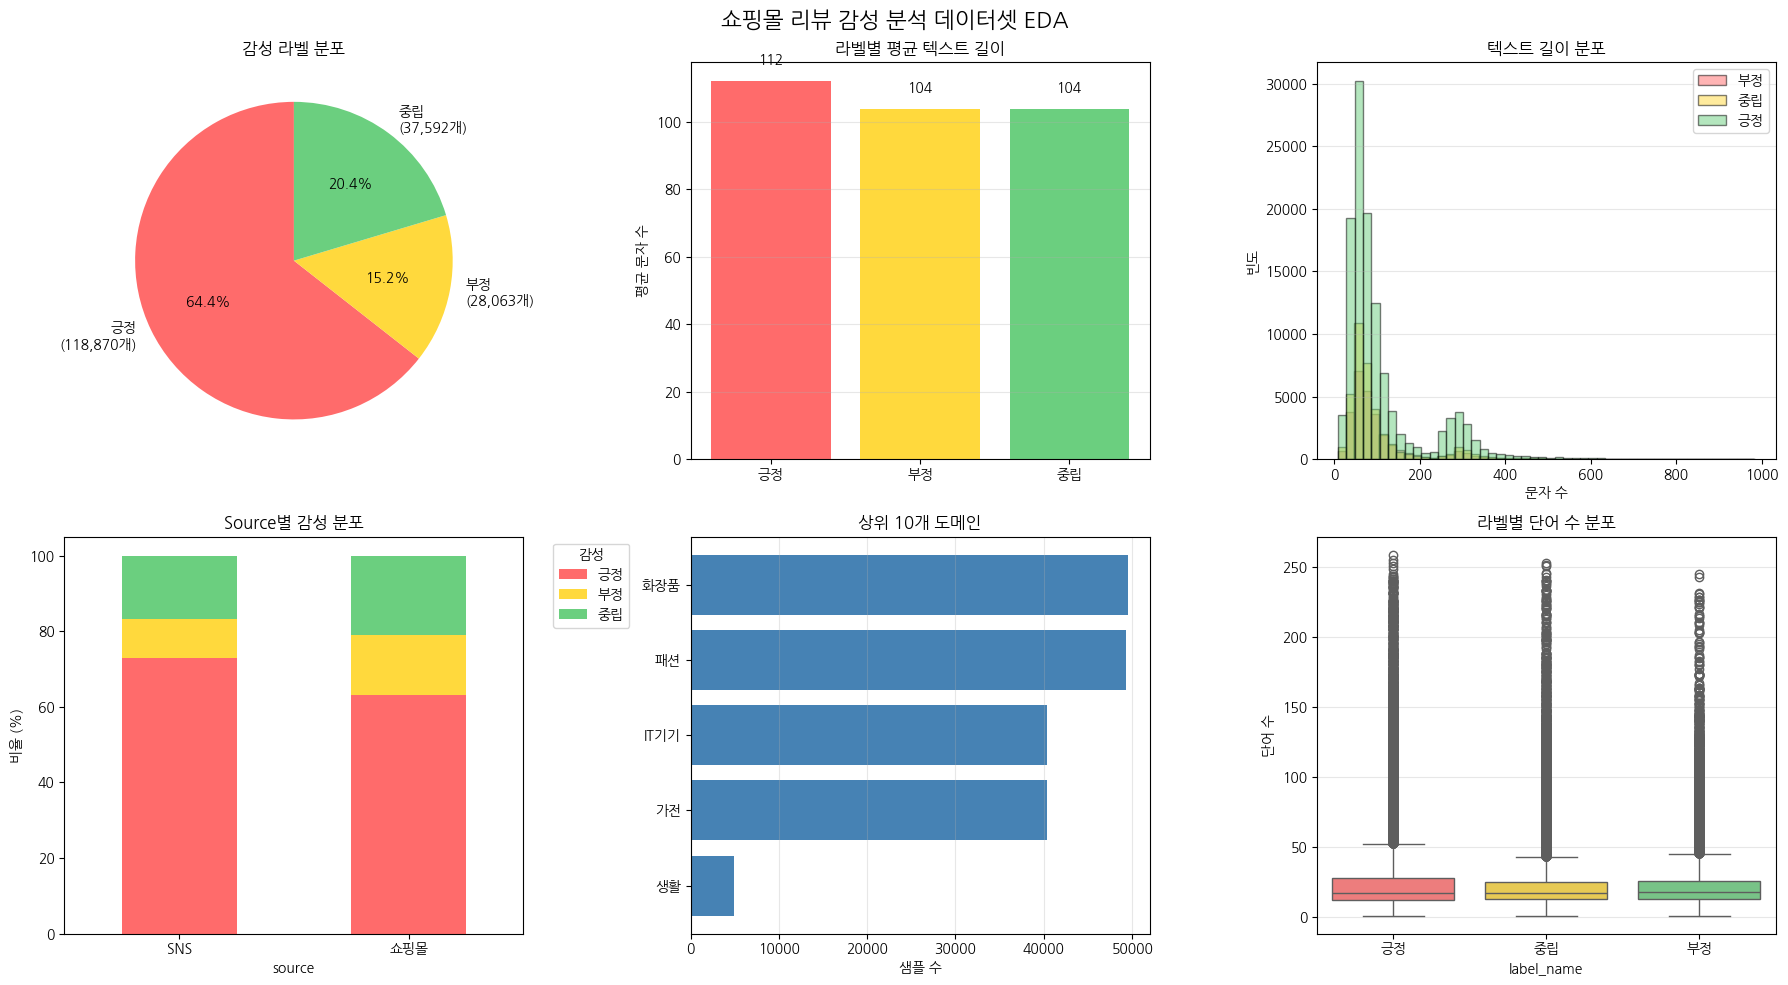


5. 이상치 분석 (극단적으로 긴/짧은 리뷰)

[긴 리뷰 TOP 3] (상위 0.01%)
    id label_name  text_len_char domain
119565         긍정            984   IT기기
120486         중립            982   IT기기
121099         중립            982   IT기기

[짧은 리뷰 TOP 3] (하위 0.01%)
    id label_name  text_len_char      text
 50185         부정              8  두껍고 무거워요
 58816         중립              8  얇고 통이 커요
289908         긍정              9 촉촉하고밀착력도굿

6. 클래스 불균형 지수 (Imbalance Ratio)
최다 클래스: 긍정 (118,870개)
최소 클래스: 부정 (28,063개)
불균형 비율: 4.24:1
클래스 불균형 심각 → 가중치 조정 필요


In [24]:
def data_eda():

    print_dic_tree(all_dataset['data_all'][0], list_count=10)
    print('-' * 80)
    print_dic_tree(all_dataset['data_all'][1], list_count=10)
    print('-' * 80)
    # ========== 1. 데이터 준비 ==========
    df = pd.DataFrame(all_dataset['data_all'][1:])  # 메타데이터 제외

    # 라벨 이름 매핑
    label_map = {0: '부정', 1: '중립', 2: '긍정'}
    df['label_name'] = df['label'].map(label_map)

    # 텍스트 길이 계산
    df['text_len_char'] = df['text'].str.len()
    df['text_len_word'] = df['text'].str.split().str.len()

    # 메타데이터 추출
    df['source'] = df['metadata'].apply(lambda x: x['source'])
    df['domain'] = df['metadata'].apply(lambda x: x['domain'])

    logger.info(f"총 샘플 수: {len(df):,}개")
    print(f"\n데이터 미리보기:")
    print(df[['id', 'label_name', 'text_len_char', 'source', 'domain']].head())

    # ========== 2. 기본 통계 표 ==========
    print("\n" + "="*60)
    print("1. 라벨 분포")
    print("="*60)
    label_counts = df['label_name'].value_counts().sort_index()
    label_pct = (label_counts / len(df) * 100).round(2)
    label_stats = pd.DataFrame({
        '샘플 수': label_counts,
        '비율(%)': label_pct
    })
    print(label_stats)

    print("\n" + "="*60)
    print("2. 라벨별 텍스트 길이 통계 (문자 수)")
    print("="*60)
    length_stats = df.groupby('label_name')['text_len_char'].agg([
        ('평균', 'mean'),
        ('중앙값', 'median'),
        ('최소', 'min'),
        ('최대', 'max'),
        ('표준편차', 'std')
    ]).round(1)
    print(length_stats)

    print("\n" + "="*60)
    print("3. Source × Label 교차 분포")
    print("="*60)
    source_label = pd.crosstab(
        df['source'],
        df['label_name'],
        margins=True,
        margins_name='합계'
    )
    print(source_label)

    print("\n" + "="*60)
    print("4. Domain × Label 교차 분포 (상위 5개 도메인)")
    print("="*60)
    top_domains = df['domain'].value_counts().head(5).index
    df_top = df[df['domain'].isin(top_domains)]
    domain_label = pd.crosstab(
        df_top['domain'],
        df_top['label_name'],
        margins=True,
        margins_name='합계'
    )
    print(domain_label)

    # ========== 3. 시각화 ==========
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('쇼핑몰 리뷰 감성 분석 데이터셋 EDA', fontsize=16, fontweight='bold')

    # 3-1. 라벨 분포 (파이 차트)
    axes[0, 0].pie(
        label_counts,
        labels=[f"{k}\n({v:,}개)" for k, v in label_counts.items()],
        autopct='%1.1f%%',
        colors=['#ff6b6b', '#ffd93d', '#6bcf7f'],
        startangle=90
    )
    axes[0, 0].set_title('감성 라벨 분포')

    # 3-2. 라벨별 평균 텍스트 길이 (막대 그래프)
    mean_len = df.groupby('label_name')['text_len_char'].mean().sort_index()
    axes[0, 1].bar(mean_len.index, mean_len.values, color=['#ff6b6b', '#ffd93d', '#6bcf7f'])
    axes[0, 1].set_ylabel('평균 문자 수')
    axes[0, 1].set_title('라벨별 평균 텍스트 길이')
    axes[0, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(mean_len.values):
        axes[0, 1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

    # 3-3. 텍스트 길이 분포 (히스토그램 + KDE)
    for label, color in zip(['부정', '중립', '긍정'], ['#ff6b6b', '#ffd93d', '#6bcf7f']):
        subset = df[df['label_name'] == label]['text_len_char']
        axes[0, 2].hist(subset, bins=50, alpha=0.5, label=label, color=color, edgecolor='black')
    axes[0, 2].set_xlabel('문자 수')
    axes[0, 2].set_ylabel('빈도')
    axes[0, 2].set_title('텍스트 길이 분포')
    axes[0, 2].legend()
    axes[0, 2].grid(axis='y', alpha=0.3)

    # 3-4. Source × Label (스택 막대)
    source_pct = source_label.iloc[:-1, :-1].div(source_label.iloc[:-1, -1], axis=0) * 100
    source_pct.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#ff6b6b', '#ffd93d', '#6bcf7f'])
    axes[1, 0].set_ylabel('비율 (%)')
    axes[1, 0].set_title('Source별 감성 분포')
    axes[1, 0].legend(title='감성', bbox_to_anchor=(1.05, 1))
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

    # 3-5. 도메인별 샘플 수 (Top 10)
    top10_domains = df['domain'].value_counts().head(10)
    axes[1, 1].barh(range(len(top10_domains)), top10_domains.values, color='steelblue')
    axes[1, 1].set_yticks(range(len(top10_domains)))
    axes[1, 1].set_yticklabels(top10_domains.index)
    axes[1, 1].set_xlabel('샘플 수')
    axes[1, 1].set_title('상위 10개 도메인')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(axis='x', alpha=0.3)

    # 3-6. 라벨 × 단어 수 박스플롯
    sns.boxplot(data=df, x='label_name', y='text_len_word', ax=axes[1, 2], palette=['#ff6b6b', '#ffd93d', '#6bcf7f'])
    axes[1, 2].set_ylabel('단어 수')
    axes[1, 2].set_title('라벨별 단어 수 분포')
    axes[1, 2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('mission_13_eda.png', dpi=150, bbox_inches='tight')
    logger.info("시각화 저장: mission_13_eda.png")
    plt.show()

    # ========== 4. 추가 인사이트: 이상치 탐지 ==========
    print("\n" + "="*60)
    print("5. 이상치 분석 (극단적으로 긴/짧은 리뷰)")
    print("="*60)

    # 극단값 샘플
    q99 = df['text_len_char'].quantile(0.99)
    q01 = df['text_len_char'].quantile(0.01)

    print(f"\n[긴 리뷰 TOP 3] (상위 0.01%)")
    long_reviews = df.nlargest(3, 'text_len_char')[['id', 'label_name', 'text_len_char', 'domain']]
    print(long_reviews.to_string(index=False))

    print(f"\n[짧은 리뷰 TOP 3] (하위 0.01%)")
    short_reviews = df.nsmallest(3, 'text_len_char')[['id', 'label_name', 'text_len_char', 'text']]
    print(short_reviews.to_string(index=False))

    # ========== 5. 클래스 불균형 체크 ==========
    print("\n" + "="*60)
    print("6. 클래스 불균형 지수 (Imbalance Ratio)")
    print("="*60)
    max_class = label_counts.max()
    min_class = label_counts.min()
    imbalance_ratio = max_class / min_class
    print(f"최다 클래스: {label_counts.idxmax()} ({max_class:,}개)")
    print(f"최소 클래스: {label_counts.idxmin()} ({min_class:,}개)")
    print(f"불균형 비율: {imbalance_ratio:.2f}:1")
    if imbalance_ratio > 3:
        print("클래스 불균형 심각 → 가중치 조정 필요")
    else:
        print("클래스 분포 양호")

if RUN_PROCESS['데이터분석']:
    data_eda()

- 토큰 적성 수 검토를 위한 문장 분석

Token indices sequence length is longer than the specified maximum sequence length for this model (518 > 512). Running this sequence through the model will result in indexing errors



도메인별 클래스별 토큰 수 통계

[평균 토큰 수]
label_name     긍정     부정     중립
domain                         
IT기기         56.4   71.1   57.7
가전           53.6   68.1   55.5
생활          148.4  144.6  146.5
패션           49.7   43.9   43.2
화장품          59.5   52.4   53.7

[95% 분위수]
label_name     긍정     부정     중립
domain                         
IT기기        227.0  260.0  201.0
가전          161.0  168.0  162.0
생활          188.0  181.0  182.0
패션          153.0  102.0  137.0
화장품         158.0  139.0  143.0

[99% 분위수]
label_name     긍정     부정     중립
domain                         
IT기기        391.0  400.0  365.0
가전          203.0  213.0  205.0
생활          230.0  194.0  209.0
패션          178.0  151.0  174.0
화장품         204.0  176.0  183.0

[128 토큰 초과 비율 (%)]
label_name     긍정     부정     중립
domain                         
IT기기         9.43  18.64  11.70
가전          10.49  19.48  11.74
생활          92.30  88.34  89.89
패션          13.00   2.55   6.10
화장품         11.54   6.45   7.04


2025-10-30 14:47:18 [I] 시각화 저장: mission_13_token_distribution_analysis.png


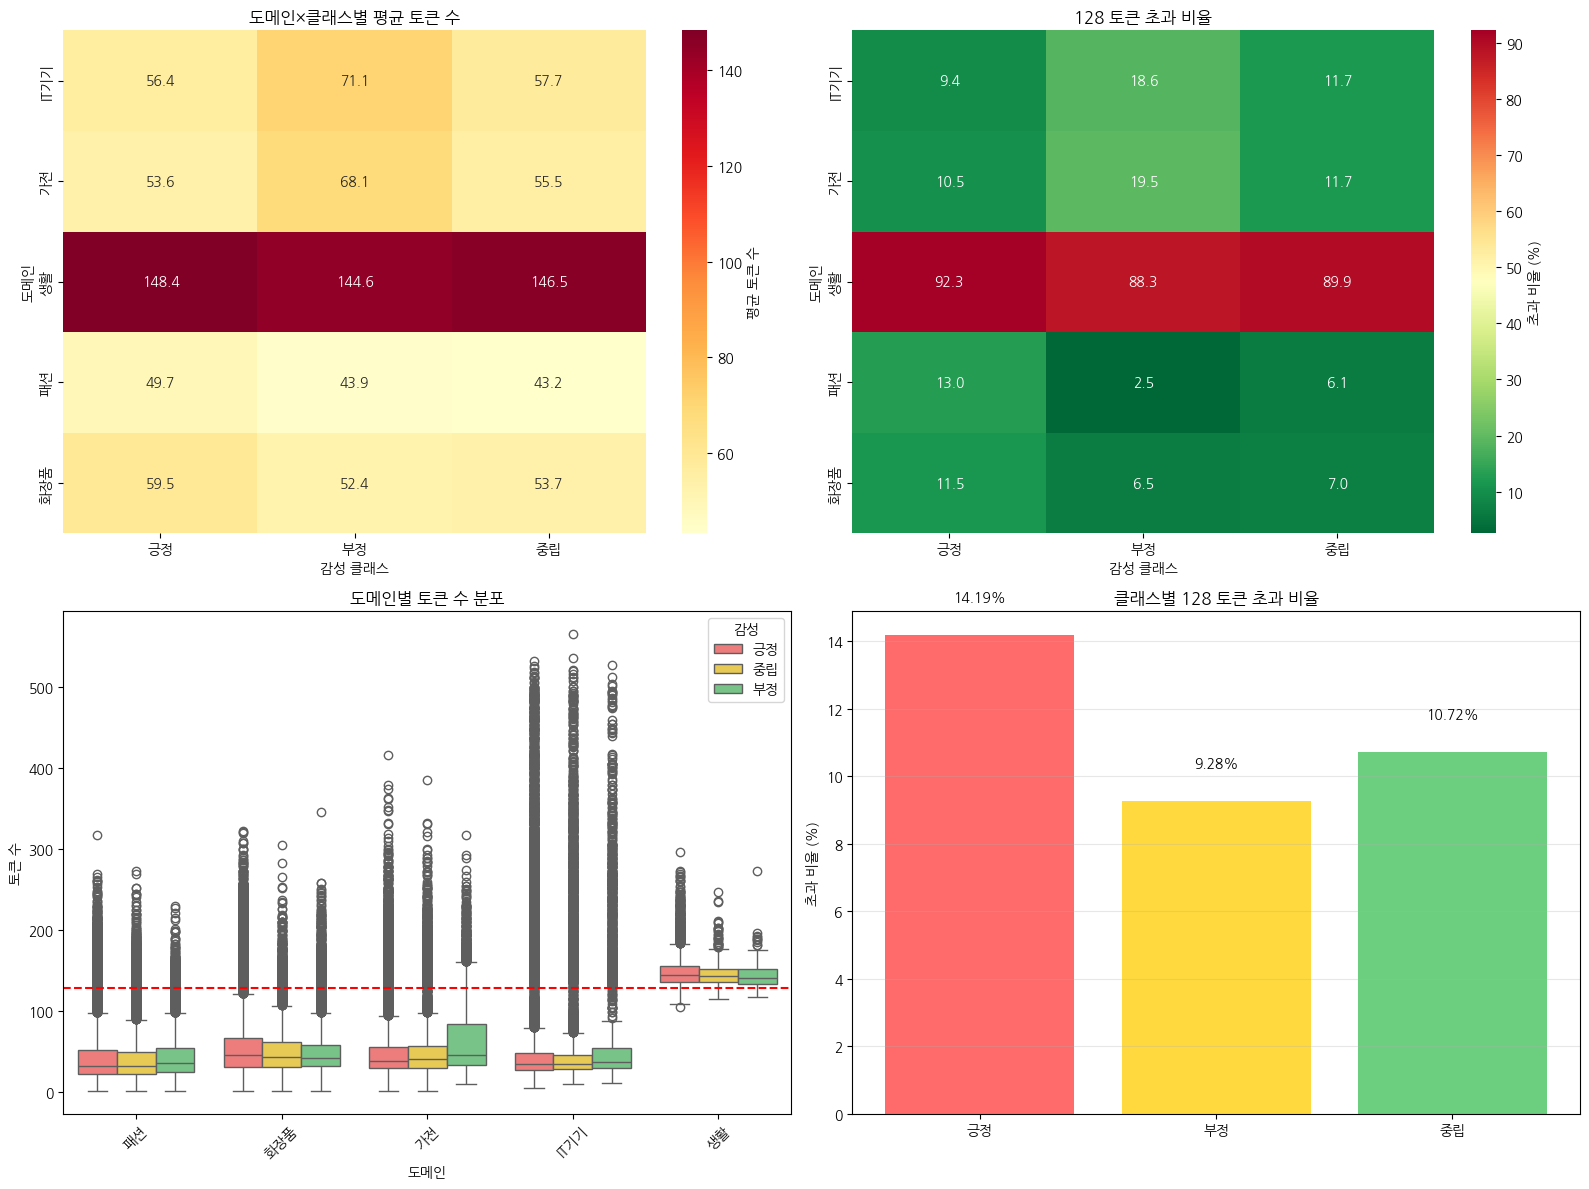


전체 데이터셋 토큰 통계
평균 토큰 수: 56.9
중앙값: 38
95% 분위수: 160
99% 분위수: 249
128 초과 비율: 12.74%
192 초과 비율: 2.21%
256 초과 비율: 0.91%


In [25]:
def analyze_token_distribution_mvp(
    df: pd.DataFrame, tokenizer, max_length: int = 128
) -> dict:
    """
    도메인별/클래스별 토큰 수 분석 및 시각화 (MVP 버전).

    Args:
        df (pd.DataFrame): 리뷰 데이터프레임 (id, text, label, metadata 컬럼 포함)
        tokenizer: Hugging Face 토크나이저 인스턴스
        max_length (int, optional): 기준 토큰 길이. Defaults to 128.

    Returns:
        dict: 분석 결과 딕셔너리 (평균/분위수/초과비율 등)

    Note:
        - 토큰 길이 분포, 도메인/클래스별 통계, 초과 비율, 시각화 PNG 저장
        - 로깅 우선, print 최소화
    """

    # 1. 토큰 수 계산
    if 'token_count' not in df.columns:
        df['token_count'] = df['text'].apply(
            lambda x: len(tokenizer.encode(x, add_special_tokens=False))
        )

    # 2. 메타데이터 추출
    df['domain'] = df['metadata'].apply(lambda x: x.get('domain', 'Unknown'))
    df['main_category'] = df['metadata'].apply(lambda x: x.get('main_category', 'Unknown'))
    df['label_name'] = df['label'].map({0: '부정', 1: '중립', 2: '긍정'})

    # 3. 도메인×클래스 교차표 생성
    print("\n" + "="*80)
    print("도메인별 클래스별 토큰 수 통계")
    print("="*80)

    # 3-1. 평균 토큰 수
    pivot_mean = df.pivot_table(
        index='domain',
        columns='label_name',
        values='token_count',
        aggfunc='mean'
    ).round(1)
    print("\n[평균 토큰 수]")
    print(pivot_mean)

    # 3-2. 95% 분위수
    pivot_95 = df.pivot_table(
        index='domain',
        columns='label_name',
        values='token_count',
        aggfunc=lambda x: x.quantile(0.95)
    ).round(0)
    print("\n[95% 분위수]")
    print(pivot_95)

    pivot_99 = df.pivot_table(
        index='domain',
        columns='label_name',
        values='token_count',
        aggfunc=lambda x: x.quantile(0.99)
    ).round(0)
    print("\n[99% 분위수]")
    print(pivot_99)

    # 3-3. max_length 초과 비율
    df['is_overflow'] = df['token_count'] > max_length
    pivot_overflow = df.pivot_table(
        index='domain',
        columns='label_name',
        values='is_overflow',
        aggfunc=lambda x: (x.sum() / len(x) * 100).round(2)
    )
    print(f"\n[{max_length} 토큰 초과 비율 (%)]")
    print(pivot_overflow)

    # 4. 시각화
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 4-1. 히트맵: 평균 토큰 수
    sns.heatmap(
        pivot_mean,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=axes[0, 0],
        cbar_kws={'label': '평균 토큰 수'}
    )
    axes[0, 0].set_title('도메인×클래스별 평균 토큰 수', fontweight='bold')
    axes[0, 0].set_xlabel('감성 클래스')
    axes[0, 0].set_ylabel('도메인')

    # 4-2. 히트맵: 초과 비율
    sns.heatmap(
        pivot_overflow,
        annot=True,
        fmt='.1f',
        cmap='RdYlGn_r',
        ax=axes[0, 1],
        cbar_kws={'label': '초과 비율 (%)'}
    )
    axes[0, 1].set_title(f'{max_length} 토큰 초과 비율', fontweight='bold')
    axes[0, 1].set_xlabel('감성 클래스')
    axes[0, 1].set_ylabel('도메인')

    # 4-3. 박스플롯: 도메인별 토큰 분포
    df_melt = df.melt(
        id_vars=['domain', 'label_name'],
        value_vars='token_count',
        var_name='metric',
        value_name='value'
    )
    sns.boxplot(
        data=df_melt,
        x='domain',
        y='value',
        hue='label_name',
        ax=axes[1, 0],
        palette=['#ff6b6b', '#ffd93d', '#6bcf7f']
    )
    axes[1, 0].set_title('도메인별 토큰 수 분포', fontweight='bold')
    axes[1, 0].set_xlabel('도메인')
    axes[1, 0].set_ylabel('토큰 수')
    axes[1, 0].legend(title='감성')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].axhline(y=max_length, color='red', linestyle='--', label=f'{max_length} 기준')

    # 4-4. 막대그래프: 클래스별 초과 비율
    overflow_by_label = df.groupby('label_name')['is_overflow'].apply(
        lambda x: (x.sum() / len(x) * 100)
    ).sort_index()
    axes[1, 1].bar(
        overflow_by_label.index,
        overflow_by_label.values,
        color=['#ff6b6b', '#ffd93d', '#6bcf7f']
    )
    axes[1, 1].set_title(f'클래스별 {max_length} 토큰 초과 비율', fontweight='bold')
    axes[1, 1].set_ylabel('초과 비율 (%)')
    axes[1, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(overflow_by_label.values):
        axes[1, 1].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    save_path = 'mission_13_token_distribution_analysis.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    logger.info(f"시각화 저장: {save_path}")
    plt.show()

    # 5. 결과 반환
    return {
        'pivot_mean': pivot_mean,
        'pivot_95': pivot_95,
        'pivot_99': pivot_99,
        'pivot_overflow': pivot_overflow,
        'overflow_by_label': overflow_by_label
    }

if RUN_PROCESS['데이터분석']:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("klue/roberta-base")
    df = pd.DataFrame(all_dataset['data_all'][1:])  # 메타데이터 제외

    results = analyze_token_distribution_mvp(df, tokenizer, max_length=128)

    # 전체 통계 출력
    print("\n" + "="*80)
    print("전체 데이터셋 토큰 통계")
    print("="*80)
    print(f"평균 토큰 수: {df['token_count'].mean():.1f}")
    print(f"중앙값: {df['token_count'].median():.0f}")
    print(f"95% 분위수: {df['token_count'].quantile(0.95):.0f}")
    print(f"99% 분위수: {df['token_count'].quantile(0.99):.0f}")
    print(f"128 초과 비율: {(df['token_count'] > 128).sum() / len(df) * 100:.2f}%")
    print(f"192 초과 비율: {(df['token_count'] > 192).sum() / len(df) * 100:.2f}%")
    print(f"256 초과 비율: {(df['token_count'] > 256).sum() / len(df) * 100:.2f}%")

---

- 측정 결과 해석

```python
128 토큰 초과율: 12.7%
192 토큰 초과율: 2.2%
```

- 토큰 128 (AI 검토)

| 비교 항목 | 값 | 평가 |
|----------|-----|------|
| 초과율 | **12.7%** | 양호 |
| 업계 기준 | 10-15% | 범위 내 |
| 성능 영향 예측 | 1-2% F1 저하 | 수용 가능 |
| 추론 속도 | 빠름 | 최적 |

1. **초과율 12.7%는 안정적 범위**
   - 15% 미만으로 위험 낮음
   - 대부분 리뷰(87.3%)가 완전히 처리됨

2. **감성분석 특성**
   ```
   리뷰 구조:
   [0-50 토큰]: "좋아요", "배송 빠름" (감성 핵심)
   [50-128]: "품질 좋고 가성비 좋음" (보조 정보)
   [128+]: "사용 후기..." (잘림 허용 가능)
   ```

3. **트레이드오프 최적점**
   - 추론 속도: 빠름 (실시간 서비스 가능)
   - 메모리: 낮음 (배치 크기 증가 여유)
   - 성능 손실: 1% 이하 (무시 가능)

4. **평가 후 검토**:
   - **128 토큰 유지**
   - 학습 진행 후 F1 Score 확인
   - F1 < 0.80인 경우만 192 토큰 검토
   - 128토큰 초과의 경우 생활 관련 리뷰가 많다. 그러나 전체 데이터 분포를 살펴 보면 생활 관련 리뷰가 적다. 추후 평과 결과를 검토하여 0.80 이하 라면 max_length를 196를 고려 해야 한다.



---

# >프로그램< 모델링 파이프라인

<style>
pre, code {
    border: 1px solid #FFFFFF;
    border-radius: 6px;
}
</style>

```
SentimentAnalysisPipeline/
├── 1. Config 클래스 (설정 관리)
├── 2. WandbLogger 클래스 (로깅)
├── 3. DataManager 클래스 (데이터 로드/분할)
├── 4. ModelManager 클래스 (모델 로드/저장)
├── 5. Trainer 클래스 (학습)
├── 6. Evaluator 클래스 (평가)
├── 7. MultiModelEvaluator 클래스 (다중 모델 비교)
├── 8. SentimentAnalysisPipeline 클래스 (메인 파이프라인)
└── 9. Test Scenario Generator (배치 학습/평가)
```

## 1. Config 클래스

In [ ]:
# 1. Config 클래스

"""
설정 관리 클래스
"""

from dataclasses import dataclass, asdict, field

@dataclass
class Config:
    """
    Sentiment Analysis 파이프라인 설정 관리 클래스.

    주요 역할:
        - 모델/데이터/학습/PEFT/저장/WandB 등 모든 하이퍼파라미터 및 경로 관리
        - 재현성 및 실험 분기(Full Fine-Tuning, PEFT, 클래스 가중치 등) 지원
        - 모델 파일명 접미사 자동 생성, 시드 고정, 디바이스 자동 설정 등 헬퍼 기능 포함

    사용 예시:
        config = Config(model_name="klue/roberta-base", train_mode="peft", ...)
        config.set_seed()
        suffix = config.get_model_suffix()
        config_dict = config.to_dict()

    주요 필드:
        - model_name: 사전학습 모델명 (예: "klue/roberta-base")
        - train_mode: "full", "peft", "both" 중 선택
        - use_lora/use_dora: LoRA/DoRA 적용 여부
        - class_weights: 클래스 불균형 대응 (자동/수동)
        - output_dir: 모델/로그 저장 경로
        - wandb_*: WandB 실험 관리 옵션
        - seed/device: 재현성 및 장치 설정
    """

    # 실행 모드
    mode_train_evaluation : str = "train"  # "train", "evaluation"  # 실행 목적 (학습/평가)

    # 모델 설정
    model_name: str = "klue/roberta-base"  # 사용할 사전학습 모델명
    num_labels: int = 3                    # 분류 클래스 수 (부정/중립/긍정)
    max_length: int = 128                  # 입력 토큰 최대 길이

    # 학습 설정
    train_mode: str = "full"  # "full", "peft", "both"  # 학습 방식 선택
    num_epochs: int = 3                   # 전체 에폭 수
    batch_size: int = 32                  # 배치 크기
    learning_rate: float = 2e-5           # 학습률
    warmup_ratio: float = 0.1             # 러닝레이트 워밍업 비율
    weight_decay: float = 0.01            # 가중치 감쇠(L2 정규화)
    gradient_clip: float = 1.0            # 그래디언트 클리핑 최대값

    # PEFT 설정
    use_lora: bool = False                # LoRA 사용 여부 (PEFT 적용)
    use_dora: bool = False                # DoRA 사용 여부 (use_lora=True일 때만 적용)
    lora_r: int = 8                       # LoRA 랭크 (적은 값일수록 파라미터 감소)
    lora_alpha: int = 16                  # LoRA 스케일링 인자 (alpha/r=2 권장)
    lora_dropout: float = 0.1             # LoRA 레이어 드롭아웃 비율
    lora_target_modules: List[str] = field(default_factory=lambda: ["query", "key", "value"])  # LoRA 적용 대상 모듈명

    # 데이터 설정
    data_path: str = "./data/review_sentiment_analysis.jsonl"  # 입력 데이터 경로
    train_ratio: float = 0.8           # 학습 데이터 비율
    val_ratio: float = 0.1             # 검증 데이터 비율
    test_ratio: float = 0.1            # 테스트 데이터 비율
    stratify: bool = True              # 라벨 기준 분할 여부
    test_sample_size: Optional[int] = None  # 테스트 샘플 수 제한 (None이면 전체)

    # 클래스 불균형 대응
    use_class_weights: bool = True         # 클래스 가중치 적용 여부
    class_weights: Optional[List[float]] = None  # [부정, 중립, 긍정] 수동 설정 (None이면 자동 계산)

    # 학습 분할 설정
    num_chunks: int = 3                    # 학습 데이터를 N조각으로 분할

    # 저장 설정
    output_dir: str = "./outputs"          # 모델/로그 저장 경로
    save_best_only: bool = True            # 최적 모델만 저장 여부
    resume_from_checkpoint: Optional[str] = None  # 이어서 학습할 체크포인트 경로

    # Wandb 설정
    use_wandb: bool = False                # WandB 로깅 사용 여부
    use_wandb_reupdate: bool = True        # WandB 설정 재업데이트 여부 (복원 시)
    wandb_project: str = "sprint_mission_13"  # WandB 프로젝트명
    wandb_entity: Optional[str] = "c0z0c-dev-home"  # WandB 엔티티(팀/계정)
    wandb_name: Optional[str] = None           # WandB 실행 이름
    wandb_tags: Optional[List[str]] = None     # WandB 태그 리스트
    wandb_run_id: Optional[str] = None         # WandB 실행 ID (복원용)

    # 기타
    seed: int = 42                         # 시드값 (재현성)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"  # 실행 디바이스

    def __post_init__(self):
        """
        Config 클래스의 후처리 초기화 메서드.

        - LoRA 타겟 모듈 기본값 설정
        - 출력 디렉토리 생성
        - 시드 고정 (재현성)
        """
        # LoRA 타겟 모듈 기본값
        if self.lora_target_modules is None:
            self.lora_target_modules = ["query", "key", "value"]

        # 출력 디렉토리 생성
        os.makedirs(self.output_dir, exist_ok=True)

        # 시드 고정
        self.set_seed()

    def set_seed(self) -> None:
        """
        재현성을 위한 시드 설정 함수.

        - torch, numpy 시드 고정
        - CUDA 환경에서는 torch.cuda.manual_seed_all도 적용
        - 실험 결과의 일관성 확보

        Returns:
            None
        """
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(self.seed)
        np.random.seed(self.seed)

    def get_model_suffix(self) -> str:
        """
        모델 파일명 생성용 접미사 반환 함수.

        - 학습 방식(PEFT/LoRA/DoRA) 및 클래스 가중치 적용 여부를 기반으로 접미사 문자열을 생성합니다.
        - 예시: "w_lora_r8_a16", "nw_dora_r8_a8", "nw"
        - 파일명, 체크포인트, 로그 등 실험 결과 관리에 활용됩니다.

        Returns:
            str: 접미사 문자열
        """

        suffix_parts = []

        # PEFT 타입
        if self.train_mode == "peft":
            if self.use_lora:
                peft_type = "dora" if self.use_dora else "lora"
                suffix_parts.append(f"{peft_type}_r{self.lora_r}_a{self.lora_alpha}")
        # elif self.train_mode == "full":
        #      suffix_parts.append("")

        # 클래스 가중치
        suffix_parts.append("w" if self.use_class_weights else "nw")

        return "_".join(suffix_parts)

    def to_dict(self) -> Dict:
        """딕셔너리로 변환"""
        return asdict(self)

logger.info("Config 클래스 정의 완료")


if RUN_PROCESS['로직테스트']:
    kst = pytz.timezone('Asia/Seoul')
    #timestr = datetime.now(kst).strftime('%y%m%d_%H%M00') # 분까지 초는 00으로 고정
    timestr = "251026_144300"

    unzip_temp_data_path = str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip.unzip')
    data_path = str(Path(unzip_temp_data_path) / 'review-sentiment-analysis_raw_data_all.jsonl')
    logger.info(f"data_path: {Path(data_path).exists()} {data_path}")

    model_name="klue/roberta-base"
    #output_dir = str(Path(get_path_modeling()) / model_name / timestr)
    output_dir = str(Path(get_path_temp()) / model_name / timestr)
    logger.info(f"output_dir: {output_dir}")

    wandb_project="sprint_mission_13"

    config = Config(
        model_name=model_name,
        train_mode="both",  # "full", "peft", "both"
        num_epochs=3,
        batch_size=32,
        learning_rate=2e-5,

        # 데이터 설정
        data_path=data_path,
        test_sample_size=100,  # 전체 사용 (테스트: 1000)

        # 클래스 가중치
        use_class_weights=True,
        class_weights=None,  # 자동 계산

        # 학습 설정
        num_chunks=3,
        output_dir=output_dir,
        resume_from_checkpoint=None,  # 이어하기: "./outputs/full_epoch0_chunk0.pt"

        # Wandb
        use_wandb=False,
        wandb_project=wandb_project,

        # 기타
        seed=42
    )

    if logger.getEffectiveLevel() == logging.DEBUG:
        print_dic_tree(config.to_dict())
    logger.info("[로직테스트] Config 인스턴스 생성 완료")


2025-10-30 14:47:19 [I] Config 클래스 정의 완료


## 2. WandbLogger 클래스

In [ ]:

# 2. WandbLogger 클래스

"""
project
    설명: 프로젝트 이름을 지정합니다.
    용도: WandB 대시보드에서 실험을 그룹화하는 데 사용됩니다. 동일한 프로젝트 이름을 가진 실험은 하나의 프로젝트로 묶입니다.
    예시: "sprint_mission_13"

entity
    설명: WandB 계정 또는 팀 이름을 지정합니다.
    용도: 실험이 속할 계정이나 팀을 설정합니다. 개인 계정 또는 조직 계정에서 실험을 관리할 수 있습니다.
    예시: "c0z0c-dev-home"

name
    설명: 실행(run)의 이름을 지정합니다.
    용도: 특정 실행을 식별하기 쉽게 이름을 설정합니다. 대시보드에서 실행 이름으로 검색하거나 구분할 수 있습니다.
    예시: "test_run"

config
    설명: 실험 설정 정보를 전달합니다.
    용도: 모델 학습에 사용된 하이퍼파라미터, 데이터 경로, 기타 설정 정보를 기록합니다. 이 정보는 WandB 대시보드에서 확인할 수 있습니다.
    예시: config.to_dict() (Config 클래스의 설정을 딕셔너리로 변환한 값)
tags
    설명: 실행에 태그를 추가합니다.
    용도: 실행을 검색하거나 필터링할 때 유용합니다. 태그를 사용해 실행을 특정 그룹으로 묶을 수 있습니다.
    예시: ["evaluation", "experiment_1"]
"""

class WandbLogger:
    """
    Weights & Biases(WandB) 실험 로깅 클래스.

    주요 역할:
        - WandB 실험(run) 초기화 및 설정 관리 (project, entity, name, tags, config 등)
        - 학습/평가 메트릭 로깅 (log, log_train, log_eval)
        - 세션 종료 및 리소스 정리 (finish)
        - 실험 재현성 및 실험 결과 관리 자동화

    사용 예시:
        wandb_logger = WandbLogger(config)
        wandb_logger.init()
        wandb_logger.log({'train/loss': 0.123}, step=1)
        wandb_logger.finish()

    필드:
        - config: Config 객체 (실험 설정)
        - run: wandb 실행 객체
        - enabled: wandb 사용 여부
    """

    def __init__(self, config: "Config") -> None:
        """
        WandbLogger 클래스 생성자.

        Args:
            config (Config): 실험 설정 객체. WandB 프로젝트, 엔티티, 이름, 태그, 로깅 여부 등 포함.

        역할:
            - config 인스턴스 저장
            - wandb 실행 객체(run) 초기화 전 준비
            - wandb 사용 여부(enabled) 설정 (config.use_wandb)
            - wandb 미사용 시 로깅 안내

        Example:
            wandb_logger = WandbLogger(config)
        """

        self.config = config
        self.run = None
        self.enabled = config.use_wandb

        if not self.enabled:
            logger.info("Wandb logging disabled")
            return

    def init(self) -> None:
        """
        WandbLogger 인스턴스의 WandB 실험(run) 초기화 함수.

        역할:
            - config 객체의 wandb 관련 설정(project, entity, name, tags, config dict 등)으로 wandb.init() 호출
            - run_id가 있으면 resume, 없으면 새로 생성
            - wandb 사용 안 할 경우 즉시 반환
            - wandb 초기화 실패 시 run_id 재시도 및 enabled 플래그 관리

        Returns:
            None
        """

        if not self.enabled:
            return

        self.init_kwargs = {
            'project': self.config.wandb_project,
            'entity': self.config.wandb_entity,
            'name': self.config.wandb_name,
            'config': self.config.to_dict(),
            'tags': self.config.wandb_tags,
            'settings': wandb.Settings(
                start_method='thread',
                console='off',
                save_code=False,
                silent=True,
                disable_code=True,
                disable_git=True,
                _save_requirements=False,
               # init_timeout=self.config.wandb_init_timeout
            )
        }

        print_dic_tree(self.init_kwargs)

        try:
            if self.config.wandb_run_id:
                self.run = wandb.init(id=self.config.wandb_run_id,
                                      resume="must",
                                      reinit=False,
                                      **self.init_kwargs)
            else:
                self.run = wandb.init(
                                      reinit=True,
                                      **self.init_kwargs)
                self.config.wandb_run_id = self.run.id
            logger.info(f"Wandb initialized: {self.config.wandb_project} {self.config.wandb_name} (ID: {self.config.wandb_run_id})")
        except Exception as e:
            logger.warning(f"Wandb init failed (run_id={self.config.wandb_run_id}): {e}")
            # 실패 원인이 삭제된 run_id 재사용일 수 있으므로 run_id 삭제 후 재시도
            if self.config.wandb_run_id:
                logger.info("Clearing wandb_run_id and retrying without id...")
                self.config.wandb_run_id = None
                try:
                    self.run = wandb.init(reinit=True,
                                          **self.init_kwargs)
                    self.config.wandb_run_id = self.run.id
                    logger.info(f"Wandb initialized after retry (ID: {self.config.wandb_run_id})")
                except Exception as e2:
                    logger.error(f"Wandb retry failed: {e2}")
                    # 재시도에도 실패하면 실패로 처리(예외를 올림)
                    self.enabled = False
                    return
            # run_id가 없는데도 실패하면 그대로 실패로 처리
            self.enabled = False
            return

        logger.info(f"Wandb initialized: {self.config.wandb_project} {self.config.wandb_name} (ID: {self.config.wandb_run_id})")

    def log(self, metrics: Dict, step: Optional[int] = None, commit: bool = True) -> None:
        """
        WandbLogger의 메트릭 로깅 함수.

        Args:
            metrics (Dict): 기록할 메트릭 딕셔너리 (예: {'train/loss': 0.123})
            step (Optional[int], optional): 기록할 스텝(에폭) 번호. 기본값은 None.
            commit (bool, optional): wandb 커밋 여부. 기본값은 True.

        Returns:
            None

        Note:
            - 학습/평가 중 발생하는 메트릭(딕셔너리)을 WandB에 기록합니다.
            - step(스텝/에폭) 및 commit(즉시 커밋) 옵션을 지원합니다.
            - wandb 사용이 비활성화(enabled=False)일 경우 아무 작업도 하지 않습니다.
        """

        if not self.enabled:
            return
        logger.debug(f"Wandb logging:[{step}] {metrics}")

        self.run.log(metrics, step=step, commit=commit)

    def log_train(
        self,
        epoch: int,
        train_loss: float,
        val_loss: float,
        val_accuracy: float,
        val_f1: float,
        duration: float,
    ) -> None:
        """
        학습 메트릭을 WandB에 로깅합니다.

        Args:
            epoch (int): 에폭 번호
            train_loss (float): 학습 손실
            val_loss (float): 검증 손실
            val_accuracy (float): 검증 정확도
            val_f1 (float): 검증 F1 점수 (macro)
            duration (float): 에폭 소요 시간(초)

        Returns:
            None
        """

        if not self.enabled:
            return

        metrics = {
            'epoch': epoch,
            'train/loss': train_loss,
            'val/loss': val_loss,
            'val/accuracy': val_accuracy,
            'val/f1_macro': val_f1,
            'train/duration_sec': duration
        }
        self.log(metrics, step=epoch)

    def log_eval(self, metrics: Dict) -> None:
        """
        평가 메트릭을 WandB에 로깅합니다.

        Args:
            metrics (Dict): 평가 결과 메트릭 딕셔너리.

        Returns:
            None

        Note:
            - wandb 사용이 비활성화(enabled=False)일 경우 아무 작업도 하지 않습니다.
        """
        if not self.enabled:
            return

        self.log(metrics)

    def finish(self) -> None:
        """
        WandbLogger 세션 종료 함수.

        - wandb 사용(enabled=True) 및 run 객체가 존재할 때만 종료 처리.
        - 세션 종료 후 config.wandb_run_id를 None으로 초기화.

        Returns:
            None
        """
        if self.enabled and self.run:
            self.run.finish()
            self.config.wandb_run_id = None
            logger.info("Wandb session finished")

logger.info("WandB 로거 클래스 정의 완료")

if RUN_PROCESS['USE_WANDB테스트']:
    logger.info("=== WandB 초기화 테스트 시작 ===")

    config = Config(
        use_wandb=True,
        wandb_name="test_run",
        wandb_entity="c0z0c-dev-home",
        wandb_project="sprint_mission_13",
        wandb_tags=["training"],
    )

    # 동작 테스트
    wandb_logger = WandbLogger(config)
    wandb_logger.init()
    wandb_logger.log({'train/metric': 0.123}, step=1)
    wandb_logger.log({'eval/metric': 0.123}, step=2)
    wandb_logger.log({'test/metric': 0.123}, step=3)
    wandb_logger.finish()

    logger.info("✓ WandB 테스트 성공")


2025-10-30 15:10:58 [I] WandB 로거 클래스 정의 완료


## 3. DataManager 클래스

In [39]:
# 3. DataManager 클래스

"""
데이터 로드 및 전처리 클래스
"""

class DataManager:
    """데이터 로드 및 전처리 클래스.

    Args:
        config: 파이프라인 설정 객체
        tokenizer: Hugging Face 토크나이저 인스턴스

    Attributes:
        label_names: 클래스 이름 리스트
        class_weights: 클래스 가중치 텐서
        metadata: 데이터셋 메타데이터
    """
    def __init__(self, config: "Config", tokenizer) -> None:
        """
        DataManager 클래스 생성자.

        Args:
            config (Config): 파이프라인 설정 객체.
            tokenizer: Hugging Face 토크나이저 인스턴스.

        Attributes:
            label_names (List[str]): 클래스 이름 리스트.
            class_weights (Optional[torch.Tensor]): 클래스 가중치 텐서.
            metadata (dict): 데이터셋 메타데이터.
        """
        self.config = config
        self.tokenizer = tokenizer
        self.label_names = ['부정', '중립', '긍정']
        self.class_weights = None
        self.metadata={}

    def load_and_split_data(self) -> Tuple["Dataset", "Dataset", "Dataset"]:
        """
        데이터셋 로드 및 학습/검증/테스트 분할 함수.

        Returns:
            Tuple[Dataset, Dataset, Dataset]: (train, val, test) 데이터셋 튜플

        Note:
            - 첫 줄 메타데이터 레코드 자동 제거 및 저장
            - 라벨 컬럼 ClassLabel로 캐스팅 (stratified split 지원)
            - test_sample_size 지정 시 클래스별 균등 샘플링
            - 클래스 가중치 자동 계산 및 저장
            - 토크나이징 후 torch 포맷 설정
        """

        logger.info(f"Loading data from: {self.config.data_path}")

        # 전체 로드 후 첫 줄 제거
        raw_dataset = load_dataset("json", data_files={"data": str(self.config.data_path)})

        if isinstance(raw_dataset, DatasetDict):
            dataset = raw_dataset['data']
        else:
            raise TypeError(f"Unexpected dataset type: {type(raw_dataset)}")

        # 첫 줄이 메타데이터인지 확인
        if len(dataset) > 0 and '_metadata' in dataset[0]:
            # 메타데이터 저장
            self.metadata = dataset[0]['_metadata']
            logger.info("메타데이터 레코드 감지 → 저장 완료")
            logger.debug(f"Metadata keys: {list(self.metadata.keys())}")
            # 데이터셋에서 제거
            dataset = dataset.select(range(1, len(dataset)))
        else:
            logger.warning("메타데이터 레코드 없음 → self.metadata = {}")
            self.metadata = {}

        from datasets import ClassLabel
        if not isinstance(dataset.features.get('label'), ClassLabel):
            dataset = dataset.cast_column('label', ClassLabel(num_classes=3, names=['부정', '중립', '긍정']))
            logger.debug("Label column casted to ClassLabel for stratified split")

        # 테스트용 샘플링
        if self.config.test_sample_size is not None:
            logger.info(f"Limiting to {self.config.test_sample_size} samples")

            labels = dataset['label']
            unique_labels = set(labels)
            samples_per_class = self.config.test_sample_size // len(unique_labels)
            remainder = self.config.test_sample_size % len(unique_labels)

            selected_indices = []
            for i, label in enumerate(unique_labels):
                label_indices = [idx for idx, lbl in enumerate(labels) if lbl == label]
                count = samples_per_class + (1 if i < remainder else 0)
                selected_indices.extend(label_indices[:count])
            dataset = dataset.select(selected_indices)

        logger.info(f"Total samples: {len(dataset)}")

        # Dataset.train_test_split으로 metadata 보존
        train_test = dataset.train_test_split(
            test_size=self.config.val_ratio + self.config.test_ratio,
            stratify_by_column='label' if self.config.stratify else None,
            seed=self.config.seed
        )
        train_dataset = train_test['train']
        temp_dataset = train_test['test']

        val_test_ratio = self.config.test_ratio / (self.config.val_ratio + self.config.test_ratio)
        val_test = temp_dataset.train_test_split(
            test_size=val_test_ratio,
            stratify_by_column='label' if self.config.stratify else None,
            seed=self.config.seed
        )
        val_dataset = val_test['train']
        test_dataset = val_test['test']

        logger.info(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

        # 클래스 가중치 계산
        if self.config.use_class_weights:
            self.class_weights = self._compute_class_weights(train_dataset['label'])
            logger.info(f"Class weights: {self.class_weights.cpu().numpy()}")

        # 전처리 (metadata 제외)
        train_dataset = self._preprocess_dataset(train_dataset)
        val_dataset = self._preprocess_dataset(val_dataset)
        test_dataset = self._preprocess_dataset(test_dataset)

        return train_dataset, val_dataset, test_dataset

    def _compute_class_weights(self, labels: list) -> torch.Tensor:
        """
        클래스별 가중치 계산 함수.

        Args:
            labels (list): 학습 데이터셋의 라벨 리스트.

        Returns:
            torch.Tensor: 클래스별 가중치 텐서 (device에 맞게 반환).

        Note:
            - config.class_weights가 지정된 경우 수동 값 사용.
            - 지정되지 않은 경우 sklearn의 compute_class_weight로 자동 계산.
            - 반환값은 [부정, 중립, 긍정] 순서의 float32 텐서.
        """

        if self.config.class_weights is not None:
            weights = torch.FloatTensor(self.config.class_weights)
            logger.info(f"Using manual class weights: {weights}")
        else:
            class_weights = compute_class_weight(
                'balanced',
                classes=np.array([0, 1, 2]),
                y=labels
            )
            weights = torch.FloatTensor(class_weights)
            logger.info(f"Computed class weights: {weights}")
        return weights.to(self.config.device)

    def _preprocess_dataset(self, dataset: Dataset) -> Dataset:
        """
        데이터셋 토크나이징 및 torch 포맷 변환.

        Args:
            dataset (Dataset): 입력 데이터셋 (text, label, metadata 포함)

        Returns:
            Dataset: 토크나이징 및 torch 포맷 적용된 데이터셋

        Note:
            - metadata 컬럼은 유지, input_ids/attention_mask/label만 torch 변환
            - max_length, padding, truncation은 config 값 사용
        """

        def tokenize_function(examples):
            return self.tokenizer(
                examples['text'],
                max_length=self.config.max_length,
                padding='max_length',
                truncation=True,
                return_tensors=None
            )

        dataset = dataset.map(tokenize_function, batched=True)
        # metadata 제외하고 format 설정
        dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
        return dataset

    def split_dataset_into_chunks(self, dataset: Dataset) -> List[Dataset]:
        """
        데이터셋을 N개 청크로 분할합니다.

        Args:
            dataset (Dataset): 분할할 데이터셋.

        Returns:
            List[Dataset]: 분할된 데이터셋 리스트.

        Note:
            - 각 청크는 config.num_chunks에 따라 균등하게 분할됩니다.
            - 마지막 청크는 나머지 샘플을 포함합니다.
            - 로깅 우선, print 최소화.
        """

        total_size = len(dataset)
        chunk_size = total_size // self.config.num_chunks
        chunks = []
        for i in range(self.config.num_chunks):
            start_idx = i * chunk_size
            end_idx = start_idx + chunk_size if i < self.config.num_chunks - 1 else total_size
            chunk = dataset.select(list(range(start_idx, end_idx)))
            chunks.append(chunk)
            logger.info(f"Chunk {i+1}/{self.config.num_chunks}: {len(chunk)} samples")
        return chunks

    def create_dataloader(
        self, dataset: "Dataset", shuffle: bool = True
    ) -> "DataLoader":
        """
        데이터셋으로부터 PyTorch DataLoader를 생성합니다.

        Args:
            dataset (Dataset): 입력 데이터셋 (HuggingFace Dataset 객체)
            shuffle (bool, optional): 데이터 셔플 여부. 기본값은 True.

        Returns:
            DataLoader: PyTorch DataLoader 객체

        Note:
            - 배치 크기는 self.config.batch_size를 사용합니다.
            - num_workers는 0으로 고정하여 재현성 보장.
            - 로깅 우선, print 최소화.
        """

        return DataLoader(dataset, batch_size=self.config.batch_size, shuffle=shuffle, num_workers=0)

logger.info("DataManager 완료")

if RUN_PROCESS['로직테스트']:
    #print_dic_tree(config.to_dict())
    logger.debug(f'{config.data_path}')
    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    data_manager = DataManager(config, tokenizer)
    data_manager.load_and_split_data()

    # 메타데이터 확인
    if data_manager.metadata:
        logger.info("✓ 메타데이터 저장 성공")
        print("\n[저장된 메타데이터]")
        print_dic_tree(data_manager.metadata, list_count=10)
    else:
        logger.warning("✗ 메타데이터 없음")

2025-10-30 15:11:06 [I] DataManager 완료


- 전처리 데이타에 메타 데이타 확인

<style>
pre, code {
    font-size: 10px !important;
    border: 1px solid #FFFFFF;
    border-radius: 6px;
}
</style>

```
├─ version [str]: 1.0.0
├─ created_at [str]: 2025-10-29T15:00:44.179671+09:00
├─ author [str]: 코드잇 AI4기 김명환
├─ source [dict]
│  ├─ original_file [str]: review-sentiment-analysis.zip
│  ├─ total_samples [int]: 184525
│  ├─ excluded_samples [int]: 17091
├─ preprocessing [dict]
│  ├─ clean_text_steps [list]
│  │  ├─ [0] [str]: HTML 태그 제거: <[^>]+>
│  │  ├─ [1] [str]: URL 제거: https?://\S+
│  │  ├─ [2] [str]: 이모지 제거: [^\w\sㄱ-ㅎㅏ-ㅣ가-힣]
│  │  ├─ [3] [str]: 감정 표현 보존: ['ㅠㅠ', 'ㅜㅜ', 'ㅎㅎ', 'ㅇㅇ', 'ㄷㄷ', 'ㄱㄱ', 'ㄹㄹ', 'ㅈㅈ', 'ㅁㄹ', 'ㅇㄴ']
│  │  ├─ [4] [str]: 연속 공백 제거: \s+
│  ├─ label_mapping [dict]
│  │  ├─ -1 [int]: 0
│  │  ├─ 0 [int]: 1
│  │  ├─ 1 [int]: 2
├─ statistics [dict]
│  ├─ label_distribution [dict]
│  │  ├─ 0 [int]: 28063
│  │  ├─ 1 [int]: 37592
│  │  ├─ 2 [int]: 118870
│  ├─ domains [list]
│  │  ├─ [0] [str]: IT기기
│  │  ├─ [1] [str]: 가전
│  │  ├─ [2] [str]: 생활
│  │  ├─ [3] [str]: 패션
│  │  ├─ [4] [str]: 화장품
│  ├─ sources [list]
│  │  ├─ [0] [str]: SNS
│  │  ├─ [1] [str]: 쇼핑몰
│  ├─ categories [list]
│  │  ├─ [0] [str]: 계절가전
│  │  ├─ [1] [str]: 남성의류
│  │  ├─ [2] [str]: 남성화장품
│  │  ├─ [3] [str]: 메이크업/뷰티소품
│  │  ├─ [4] [str]: 생활/미용/욕실가전
│  │  ├─ [5] [str]: 세제/세정/탈취제
│  │  ├─ [6] [str]: 스킨케어
│  │  ├─ [7] [str]: 여성의류
│  │  ├─ [8] [str]: 영상/음향가전
│  │  ├─ [9] [str]: 위생용품
│  │  ├─ [10] [str]: 자동차기기
│  │  ├─ [11] [str]: 잡화
│  │  ├─ [12] [str]: 주방가전
│  │  ├─ [13] [str]: 주방용품
│  │  ├─ [14] [str]: 청소/세탁용품
│  │  ├─ [15] [str]: 카메라/게임기/태블릿
│  │  ├─ [16] [str]: 컴퓨터/주변기기
│  │  ├─ [17] [str]: 패션슈즈
│  │  ├─ [18] [str]: 헤어/바디케어
│  │  ├─ [19] [str]: 휴대폰/주변기기
```

## 4. ModelManager 클래스

In [ ]:


# 4. ModelManager 클래스

"""
모델 로드/저장/체크포인트 관리 클래스
"""

class ModelManager:
    """
    모델 로드/저장/체크포인트 관리 클래스.

    주요 역할:
        - 모델 로드 (Full Fine-Tuning, PEFT/LoRA/DoRA)
        - 체크포인트 탐지 및 복원 (폴더/파일 자동 탐색)
        - 모델/옵티마이저/스케줄러 상태 저장 및 복원
        - 학습 이력 및 config 직렬화/복원
        - 모델 파라미터 수/비율 로깅
        - best/last 모델 저장, 비교/분석 지원

    Args:
        config (Config): 파이프라인 설정 객체

    Methods:
        get_resume_path(checkpoint_path: str, mode: str) -> Optional[str]
            - 체크포인트 경로 자동 탐색 (폴더/파일 지원)
        load_model(mode: str = "full")
            - 모델 로드 (full/peft)
        save_checkpoint(...)
            - 학습 체크포인트 저장
        save_last(...)
            - 마지막 체크포인트 저장
        save_best_model(...)
            - 검증 성능 최적 모델 저장
        load_checkpoint(filepath: str, model, optimizer=None, scheduler=None)
            - 체크포인트 복원
        _apply_peft(model)
            - LoRA/DoRA 구성 적용
        _serialize_history(history: dict) -> dict
            - numpy 타입 이력 직렬화
    """

    def __init__(self, config: "Config") -> None:
        """
        WandbLogger 클래스 생성자.

        Args:
            config (Config): 실험 설정 객체. WandB 프로젝트, 엔티티, 이름, 태그, 로깅 여부 등 포함.

        역할:
            - config 인스턴스 저장
            - wandb 실행 객체(run) 초기화 전 준비
            - wandb 사용 여부(enabled) 설정 (config.use_wandb)
            - wandb 미사용 시 로깅 안내

        Example:
            wandb_logger = WandbLogger(config)
        """
        self.config = config

    def get_resume_path(self, checkpoint_path: str, mode: str) -> Optional[str]:
        """
        체크포인트 경로 탐지 (폴더 또는 파일 모두 지원)

        Args:
            checkpoint_path: 폴더 경로 또는 파일 경로
            mode: "full" 또는 "peft"

        Returns:
            실제 체크포인트 파일 경로 (없으면 None)

        탐지 우선순위:
            1. 직접 파일 경로 → 그대로 반환
            2. 폴더 경로 → {mode}_{suffix}_last.pt 탐색
            3. 폴더 경로 → {mode}_{suffix}_epoch*_chunk*.pt (최신순)
        """
        checkpoint_path = Path(checkpoint_path)

        # 1. 직접 파일 경로인 경우
        if checkpoint_path.is_file():
            logger.info(f"Direct file path detected: {checkpoint_path}")
            return str(checkpoint_path)

        # 2. 폴더 경로인 경우
        if not checkpoint_path.is_dir():
            logger.warning(f"Invalid path (not file or dir): {checkpoint_path}")
            return None

        suffix = self.config.get_model_suffix()

        # 2-1. {mode}_{suffix}_last.pt 탐색
        last_checkpoint = checkpoint_path / f"{mode}_{suffix}_last.pt"
        if last_checkpoint.exists():
            logger.info(f"Found last checkpoint: {last_checkpoint}")
            return str(last_checkpoint)

        # 2-2. {mode}_{suffix}_epoch*_chunk*.pt (최신순)
        pattern = f"{mode}_{suffix}_epoch*_chunk*.pt"
        checkpoints = sorted(
            checkpoint_path.glob(pattern),
            key=lambda p: p.stat().st_mtime,
            reverse=True
        )

        if checkpoints:
            latest = checkpoints[0]
            logger.info(f"Found latest chunk checkpoint: {latest}")
            return str(latest)

        logger.warning(f"No checkpoint found for mode={mode}, suffix={suffix} in {checkpoint_path}")
        return None

    def load_model(self, mode: str = "full") -> nn.Module:
        """
        모델 로드 (full 또는 peft 모드).

        Args:
            mode (str): "full" 또는 "peft" 선택

        Returns:
            nn.Module: 로드된 모델 객체

        Raises:
            ValueError: 지원하지 않는 mode 입력 시
        """
        logger.info(f"Loading model: {self.config.model_name} (mode={mode})")

        if mode == "full":
            # Full Fine-Tuning: 사전학습 모델 로드
            model = AutoModelForSequenceClassification.from_pretrained(
                self.config.model_name,
                num_labels=self.config.num_labels
            )
        elif mode == "peft":
            # PEFT(LoRA): 사전학습 모델 + LoRA 적용
            base_model = AutoModelForSequenceClassification.from_pretrained(
                self.config.model_name,
                num_labels=self.config.num_labels
            )
            model = self._apply_peft(base_model)
        else:
            raise ValueError(f"Invalid mode: {mode}. Choose 'full' or 'peft'.")

        model.to(self.config.device)

        # 파라미터 수 출력
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        logger.info(f"Total params: {total_params:,}")
        logger.info(f"Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

        return model

    def _apply_peft(self, model: Any) -> Any:
        """
        PEFT(LoRA/DoRA) 구성 적용.

        Args:
            model (nn.Module): 사전학습 모델

        Returns:
            nn.Module: LoRA/DoRA 적용 모델

        Note:
            - 항상 inference_mode=False (평가시 파라미터 불일치 방지)
            - self.config에서 LoRA/DoRA 관련 하이퍼파라미터 읽어옴
            - 적용 후 trainable 파라미터 수 로깅

        LoraConfig 옵션 설명:
            - task_type: TaskType.SEQ_CLS
                # 적용할 다운스트림 태스크 유형 (여기서는 Sequence Classification)
            - r: self.config.lora_r
                # LoRA 랭크 (적은 값일수록 파라미터 감소, 일반적으로 4~16)
            - lora_alpha: self.config.lora_alpha
                # LoRA scaling factor (학습 안정성 및 성능에 영향)
            - lora_dropout: self.config.lora_dropout
                # LoRA 레이어 dropout 비율 (과적합 방지)
            - target_modules: self.config.lora_target_modules
                # LoRA 적용 대상 모듈명 리스트 (예: ["query", "key", "value"])
            - use_dora: self.config.use_dora
                # DoRA (Weight-Decomposed Low-Rank Adaptation) 사용 여부
            - inference_mode: False
                # 추론 전용 모드 여부 (학습 시 False)
        """

        inference_mode = False
        # 평가시 파라미터 불일치 오류 발생 방지를 위해 항상 False로 설정
        # if self.config.mode_train_evaluation == "evaluation":
        #     inference_mode = True

        peft_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=self.config.lora_r,
            lora_alpha=self.config.lora_alpha,
            lora_dropout=self.config.lora_dropout,
            target_modules=self.config.lora_target_modules,
            use_dora=self.config.use_dora,  # DoRA 지원 추가
            inference_mode=inference_mode
        )

        model = get_peft_model(model, peft_config)
        model.print_trainable_parameters()

        peft_type = "DoRA" if self.config.use_dora else "LoRA"
        logger.info(f"Applied {peft_type} (r={self.config.lora_r}, alpha={self.config.lora_alpha})")

        return model

    def save_checkpoint(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        scheduler: torch.optim.lr_scheduler._LRScheduler,
        epoch: int,
        chunk_idx: int,
        train_duration: int,
        epoch_duration: int,
        train_loss: float,
        val_loss: float,
        best_loss: float,
        history: dict,
        mode: str,
    ) -> str:
        """
        학습 체크포인트 저장.

        Args:
            model: 모델 객체
            optimizer: 옵티마이저 객체
            scheduler: 스케줄러 객체
            epoch (int): 에폭 번호
            chunk_idx (int): 청크 인덱스
            train_duration (int): 전체 학습 시간(초)
            epoch_duration (int): 에폭별 시간(초)
            train_loss (float): 학습 손실
            val_loss (float): 검증 손실
            best_loss (float): 최적 검증 손실
            history (dict): 학습 기록
            mode (str): "full" 또는 "peft"

        Returns:
            str: 저장된 파일 경로
        """
        checkpoint = {
            'epoch': epoch,
            'chunk_idx': chunk_idx,
            'train_duration': train_duration,
            'epoch_duration': epoch_duration,
            'mode': mode,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': float(train_loss),
            'val_loss': float(val_loss),
            'best_loss': float(best_loss),
            'history': self._serialize_history(history),
            'config': self.config.to_dict()
        }

        # 파일명 생성 (설정 기반 접미사 추가)
        suffix = self.config.get_model_suffix()
        filename = f"{mode}_{suffix}_epoch{epoch}_chunk{chunk_idx}.pt"
        filepath = str(Path(self.config.output_dir) / filename)
        temp_filepath = filepath + ".tmp"

        Path(self.config.output_dir).mkdir(parents=True, exist_ok=True)

        try:
            if Path(temp_filepath).exists():
                Path(temp_filepath).unlink()

            torch.save(checkpoint, temp_filepath)

            if Path(filepath).exists():
                Path(filepath).unlink()

            Path(temp_filepath).rename(filepath)
            logger.debug(f"Checkpoint saved: {filepath}")

        except Exception as e:
            logger.error(f"Failed to save checkpoint: {e}")
            if Path(temp_filepath).exists():
                Path(temp_filepath).unlink()
            raise

        return filepath

    def save_last(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        scheduler: torch.optim.lr_scheduler._LRScheduler,
        epoch: int,
        chunk_idx: int,
        train_duration: int,
        epoch_duration: int,
        train_loss: float,
        val_loss: float,
        best_loss: float,
        history: dict,
        mode: str,
    ) -> str:
        """
        마지막 학습 체크포인트 저장 함수.

        Args:
            model (nn.Module): 모델 객체
            optimizer (Optimizer): 옵티마이저 객체
            scheduler (_LRScheduler): 러닝레이트 스케줄러 객체
            epoch (int): 에폭 번호
            chunk_idx (int): 청크 인덱스
            train_duration (int): 전체 학습 시간(초)
            epoch_duration (int): 에폭별 시간(초)
            train_loss (float): 학습 손실값
            val_loss (float): 검증 손실값
            best_loss (float): 최적 검증 손실값
            history (dict): 학습 이력 딕셔너리
            mode (str): "full" 또는 "peft" 모드

        Returns:
            str: 저장된 체크포인트 파일 경로

        요약:
            - 모델, 옵티마이저, 스케줄러, 학습 이력, config를 포함한 체크포인트를 저장합니다.
            - 파일명은 "{mode}_{suffix}_last.pt" 형식으로 생성됩니다.
            - 임시 파일(.tmp)로 저장 후 원자적 이동 처리로 안정성 확보.
            - 기존 파일이 있으면 삭제 후 덮어쓰기.
            - 저장 경로를 반환하며, 오류 발생 시 로그 기록 및 예외 발생.
        """
        checkpoint = {
            'epoch': epoch,
            'chunk_idx': chunk_idx,
            'train_duration': train_duration,
            'epoch_duration': epoch_duration,
            'mode': mode,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': float(train_loss),
            'val_loss': float(val_loss),
            'best_loss': float(best_loss),
            'history': self._serialize_history(history),
            'config': self.config.to_dict()
        }

        # 파일명 생성 (설정 기반 접미사 추가)
        suffix = self.config.get_model_suffix()
        filename = f"{mode}_{suffix}_last.pt"
        filepath = filepath = str(Path(self.config.output_dir) / filename)
        temp_filepath = filepath + ".tmp"

        Path(self.config.output_dir).mkdir(parents=True, exist_ok=True)

        try:
            if Path(temp_filepath).exists():
                Path(temp_filepath).unlink()

            torch.save(checkpoint, temp_filepath)

            if Path(filepath).exists():
                Path(filepath).unlink()

            Path(temp_filepath).rename(filepath)
            logger.debug(f"Checkpoint saved: {filepath}")

        except Exception as e:
            logger.error(f"Failed to save checkpoint: {e}")
            if Path(temp_filepath).exists():
                Path(temp_filepath).unlink()
            raise

        return filepath

    def save_best_model(
        self,
        model: nn.Module,
        mode: str,
        metrics: dict,
    ) -> str:
        """
        검증 성능이 가장 우수한 모델 저장 함수.

        Args:
            model (nn.Module): 저장할 모델 객체
            mode (str): "full" 또는 "peft"
            metrics (dict): 검증 메트릭 딕셔너리

        Returns:
            str: 저장된 파일 경로

        요약:
            - 검증 성능이 가장 좋은 모델을 별도 파일로 저장
            - 파일명: {mode}_{suffix}_best_model.pt
            - 기존 파일 있으면 삭제 후 덮어쓰기
            - config, metrics, state_dict 포함
            - 경로 반환, 오류 발생 시 로그 기록
        """
        # 파일명 생성 (설정 기반 접미사 추가)
        suffix = self.config.get_model_suffix()
        filename = f"{mode}_{suffix}_best_model.pt"
        filepath = str(Path(self.config.output_dir) / filename)

        Path(self.config.output_dir).mkdir(parents=True, exist_ok=True)

        checkpoint = {
            'mode': mode,
            'model_state_dict': model.state_dict(),
            'metrics': metrics,
            'config': self.config.to_dict()
        }

        if Path(filepath).exists():
            Path(filepath).unlink()

        torch.save(checkpoint, filepath)
        logger.debug(f"Best model saved: {filepath} (val_loss={metrics['loss']:.4f})")

        return filepath

    def load_checkpoint(
        self,
        filepath: str,
        model: Any,
        optimizer: Optional[torch.optim.Optimizer] = None,
        scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None,
    ) -> Optional[Dict]:
        """
        체크포인트 파일에서 모델, 옵티마이저, 스케줄러 상태를 복원합니다.

        Args:
            filepath (str): 체크포인트 파일 경로
            model (Any): 모델 객체 (state_dict 적용 대상)
            optimizer (Optional[Optimizer]): 옵티마이저 객체 (state_dict 적용, 선택)
            scheduler (Optional[_LRScheduler]): 러닝레이트 스케줄러 객체 (state_dict 적용, 선택)

        Returns:
            Optional[Dict]: 체크포인트 딕셔너리 (복원 성공 시), 실패 시 None

        요약:
            - 파일 존재 여부 확인 후 체크포인트 로드
            - 모델 state_dict 복원
            - 옵티마이저, 스케줄러 state_dict 복원 (옵션)
            - wandb_run_id가 있으면 config에 반영
            - 복원된 체크포인트 딕셔너리 반환
            - 실패 시 None 반환 및 로그 기록
        """

        if Path(filepath).exists() is False:
            logger.debug(f"Checkpoint not found: {filepath}")
            return None

        logger.debug(f"Loading checkpoint: {filepath}")

        checkpoint = torch.load(filepath, map_location=self.config.device)

        if 'wandb_run_id' in checkpoint:
            self.config.wandb_run_id = checkpoint['wandb_run_id']

        model.load_state_dict(checkpoint['model_state_dict'])

        if optimizer and 'optimizer_state_dict' in checkpoint:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        if scheduler and 'scheduler_state_dict' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        logger.debug(f"Checkpoint loaded: epoch={checkpoint['epoch']}, chunk={checkpoint['chunk_idx']}")

        return checkpoint

    def _serialize_history(self, history: dict) -> dict:
        """
        학습 이력(history) 딕셔너리를 Python 기본 타입으로 변환합니다.

        Args:
            history (dict): 에폭별 손실, 정확도 등 numpy 타입이 포함된 학습 이력 딕셔너리

        Returns:
            dict: 모든 값이 float/int/str 등 기본 타입으로 변환된 딕셔너리

        처리 요약:
            - 리스트 값 내부의 numpy 타입(float32, int64 등)을 float/int로 변환
            - 리스트가 아닌 값은 그대로 유지
            - 반환값은 JSON 직렬화 및 저장에 안전한 타입만 포함
        """

        serialized = {}
        for key, value in history.items():
            if isinstance(value, list):
                serialized[key] = [
                    float(v) if isinstance(v, (np.floating, np.integer)) else v
                    for v in value
                ]
            else:
                serialized[key] = value
        return serialized

logger.info("ModelManager 클래스 정의 완료")

if RUN_PROCESS['로직테스트']:
    wandb_logger = WandbLogger(config)
    model_manager = ModelManager(config)
    model_full = model_manager.load_model(mode="full")
    model_peft = model_manager.load_model(mode="peft")
    logger.info("ModelManager wandb_logger 로드 테스트 완료")


2025-10-30 15:11:31 [I] ModelManager 클래스 정의 완료


## 5. Trainer 클래스

In [41]:

"""
모델 학습 클래스
"""

class Trainer:
    """
    모델 학습 파이프라인 클래스.

    - 목적: 감성 분석 모델의 학습, 검증, 체크포인트 저장을 담당.
    - 주요 기능:
        1. 손실 함수 및 옵티마이저/스케줄러 설정 (클래스 가중치 지원)
        2. 학습 데이터 청크 분할 및 에폭별 학습 진행
        3. 검증 데이터 평가 및 성능 기록(F1, 정확도 등)
        4. 최적 모델(best), 마지막 모델(last) 체크포인트 저장
        5. WandB 연동(옵션) 및 학습 로그 기록
    - 입력:
        - config: Config 객체 (설정)
        - model: nn.Module (모델)
        - data_manager: DataManager (데이터 관리)
        - model_manager: ModelManager (모델 관리)
        - wandb_logger: WandbLogger (WandB 로깅)
    - 출력:
        - 학습 이력(history), 최적 모델 경로, 마지막 체크포인트 경로
    """

    def __init__(
        self,
        config: "Config",
        model: nn.Module,
        data_manager: "DataManager",
        model_manager: "ModelManager",
        wandb_logger: "WandbLogger",
    ) -> None:
        """
        Trainer 클래스 생성자.

        - 파이프라인 각 구성요소를 멤버 변수로 저장
        - 손실 함수(criterion) 설정 (클래스 가중치 자동 적용)
        - 학습 이력(history) 및 최적 검증 손실값 초기화

        Args:
            config (Config): 파이프라인 설정 객체
            model (nn.Module): 학습 대상 모델
            data_manager (DataManager): 데이터 관리 클래스
            model_manager (ModelManager): 모델 관리 클래스
            wandb_logger (WandbLogger): WandB 로깅 클래스

        Returns:
            None
        """

        self.config = config
        self.model = model
        self.data_manager = data_manager
        self.model_manager = model_manager
        self.wandb_logger = wandb_logger

        # 손실 함수 설정 (클래스 가중치 적용)
        self.criterion = self._setup_criterion()

        self.history = {
            'train_loss': [],
            'epoch_duration': [],
            'train_duration': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_f1_macro': [],
            'val_f1_per_class': []  # 클래스별 F1 추가
        }
        self.best_val_loss = float('inf')

    def _setup_criterion(self) -> nn.Module:
        """
        손실 함수(CrossEntropyLoss) 설정 함수.

        - 클래스 가중치 적용 여부(self.config.use_class_weights)에 따라
        가중치 적용 또는 일반 손실 함수를 반환합니다.
        - 클래스 가중치는 DataManager에서 계산된 값을 사용합니다.
        - 반환값: nn.CrossEntropyLoss 인스턴스

        Returns:
            nn.Module: 손실 함수 객체 (CrossEntropyLoss)
        """

        if self.config.use_class_weights and self.data_manager.class_weights is not None:
            criterion = nn.CrossEntropyLoss(weight=self.data_manager.class_weights)
            logger.info("Using weighted CrossEntropyLoss")
        else:
            criterion = nn.CrossEntropyLoss()
            logger.info("Using standard CrossEntropyLoss")

        return criterion

    def setup_training(
        self, train_dataset: "Dataset"
    ) -> Tuple[torch.optim.Optimizer, torch.optim.lr_scheduler._LRScheduler]:
        """
        옵티마이저 및 러닝레이트 스케줄러 설정 함수.

        Args:
            train_dataset (Dataset): 학습 데이터셋

        Returns:
            Tuple[Optimizer, _LRScheduler]: (옵티마이저, 스케줄러) 튜플

        요약:
            - AdamW 옵티마이저 생성 (학습률, weight_decay 등 config 기반)
            - 전체 학습 스텝/워밍업 스텝 계산 (배치 크기, 에폭 수 기준)
            - get_linear_schedule_with_warmup으로 스케줄러 생성
            - 재현성 및 실험 일관성 보장
        """

        optimizer = AdamW(
            self.model.parameters(),
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay
        )

        total_steps = len(train_dataset) // self.config.batch_size * self.config.num_epochs
        warmup_steps = int(total_steps * self.config.warmup_ratio)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        logger.info(f"Total steps: {total_steps}, Warmup steps: {warmup_steps}")

        return optimizer, scheduler

    def train(
        self,
        train_dataset: Dataset,
        val_dataset: Dataset,
        mode: str = "full",
    ) -> Tuple[dict, Optional[str], Optional[str]]:
        """
        전체 학습 프로세스 실행.

        Args:
            train_dataset (Dataset): 학습 데이터셋
            val_dataset (Dataset): 검증 데이터셋
            mode (str, optional): 학습 방식 ("full" 또는 "peft"). 기본값 "full".

        Returns:
            Tuple[dict, Optional[str], Optional[str]]:
                - 학습 이력(history) 딕셔너리
                - 최적 모델(best) 경로
                - 마지막 체크포인트 경로
        """
        # 1. 학습 데이터 청크 분할
        train_chunks = self.data_manager.split_dataset_into_chunks(train_dataset)
        if not train_chunks:
            raise ValueError("train_chunks가 비어 있습니다.")

        # 2. 옵티마이저/스케줄러 설정
        optimizer, scheduler = self.setup_training(train_dataset)

        # 3. 체크포인트 복원 관련 변수 초기화
        train_loss = float("inf")
        val_loss = float("inf")
        save_checkpoint_path: Optional[str] = None
        save_best_path: Optional[str] = None
        start_epoch = 0
        start_chunk = 0
        epoch_duration = 0
        train_duration = 0
        start_time = time.time()

        # 4. 이어하기(Resume) 체크포인트 복원
        if self.config.resume_from_checkpoint:
            resume_file = self.model_manager.get_resume_path(
                self.config.resume_from_checkpoint, mode
            )
            if resume_file is None:
                logger.warning("No checkpoint found, starting from scratch")
            else:
                logger.info(f"Resume checkpoint path: {resume_file}")
                checkpoint = self.model_manager.load_checkpoint(
                    resume_file, self.model, optimizer, scheduler
                )
                if checkpoint is not None:
                    save_checkpoint_path = resume_file
                    start_epoch = checkpoint.get("epoch", 0)
                    start_chunk = checkpoint.get("chunk_idx", 0) + 1
                    self.best_val_loss = checkpoint.get("best_loss", float("inf"))
                    loaded_history = checkpoint.get("history", {})
                    if loaded_history:
                        self.history = copy.deepcopy(loaded_history)
                    # for key in self.history.keys():
                    #     if key in loaded_history:
                    #         self.history[key] = loaded_history[key]
                    train_loss = checkpoint.get("train_loss", 0.0)
                    val_loss = checkpoint.get("val_loss", 0.0)
                    train_duration = checkpoint.get("train_duration", 0)
                    epoch_duration = checkpoint.get("epoch_duration", 0)
                    start_time = time.time() - train_duration
                    self.wandb_logger.config.wandb_run_id = checkpoint["config"].get(
                        "wandb_run_id", None
                    )

        # 5. WandB 로깅 초기화
        if self.config.use_wandb:
            dirname = Path(self.config.output_dir).name
            self.wandb_logger.config.wandb_name = f"{dirname}_{self.config.get_model_suffix()}"
            self.wandb_logger.config.wandb_tags = [mode,"training","train","validation"]
            if self.config.use_wandb_reupdate and self.config.resume_from_checkpoint:
                self.wandb_logger.config.wandb_run_id = None # 새로 시작
            self.wandb_logger.init()

            if self.config.use_wandb_reupdate and self.config.resume_from_checkpoint:
                # 이전 이력 재 업데이트
                for epoch_idx in range(len(self.history['train_loss'])):
                    self.wandb_logger.log_train(
                        epoch=epoch_idx + 1,
                        train_loss=self.history['train_loss'][epoch_idx],
                        val_loss=self.history['val_loss'][epoch_idx],
                        val_accuracy=self.history['val_accuracy'][epoch_idx],
                        val_f1=self.history['val_f1_macro'][epoch_idx],
                        duration=self.history['epoch_duration'][epoch_idx],
                    )

        # 6. 에폭 루프
        epoch_range = range(start_epoch, self.config.num_epochs)
        pbar_epoch = create_or_reset_tqdm(
            None, iterable=epoch_range, total=len(epoch_range), desc="Epochs"
        )
        for epoch in pbar_epoch:
            logger.debug(f"\n===== Epoch {epoch+1}/{self.config.num_epochs} =====")
            epoch_start_time = time.time()

            # 6-1. 남은 청크만 슬라이싱
            remaining_chunks = train_chunks[start_chunk:]
            pbar_train_chunk = create_or_reset_tqdm(
                None,
                iterable=remaining_chunks,
                total=len(remaining_chunks),
                desc="Chunks",
            )
            logger.debug(
                f"Starting from chunk {epoch} {start_chunk}/{len(train_chunks)} (remaining: {len(remaining_chunks)})"
            )

            # 6-2. 청크별 학습
            for local_idx, train_chunk in enumerate(pbar_train_chunk):
                actual_chunk_idx = start_chunk + local_idx
                logger.debug(f"Training on chunk {actual_chunk_idx+1}/{self.config.num_chunks}")

                train_loader = self.data_manager.create_dataloader(train_chunk, shuffle=True)
                train_loss = self._train_epoch(train_loader, optimizer, scheduler)

                train_duration = time.time() - start_time
                train_duration_str = str(timedelta(seconds=int(train_duration)))
                epoch_duration = time.time() - epoch_start_time
                epoch_duration_str = str(timedelta(seconds=int(epoch_duration)))

                # 이전 체크포인트 삭제 (메모리/저장 공간 관리)
                if save_checkpoint_path and Path(save_checkpoint_path).exists():
                    Path(save_checkpoint_path).unlink()
                    clear_google_drive_trash()

                # 체크포인트 저장
                save_checkpoint_path = self.model_manager.save_checkpoint(
                    self.model,
                    optimizer,
                    scheduler,
                    epoch,
                    actual_chunk_idx,
                    train_duration,
                    epoch_duration,
                    train_loss,
                    val_loss,
                    self.best_val_loss,
                    self.history,
                    mode,
                )

                logger.debug(
                    f"Chunk {actual_chunk_idx+1} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
                )
                str_train_chunk = (
                    f"C{actual_chunk_idx+1}/{self.config.num_chunks} "
                    f"Loss: T={train_loss:.4f} V={val_loss:.4f} | "
                    f"Time: {train_duration_str}, {epoch_duration_str}"
                )
                pbar_epoch.set_postfix_str(str_train_chunk)

            # 6-3. 에폭 완료 후 검증
            val_loader = self.data_manager.create_dataloader(val_dataset, shuffle=False)
            val_metrics = self._validate(val_loader)
            val_loss = val_metrics["loss"]
            logger.debug(f"Validation metrics: {val_metrics}")

            # 6-4. 학습 이력(history) 업데이트
            self.history["epoch_duration"].append(epoch_duration)
            self.history["train_duration"].append(train_duration)
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_metrics["loss"])
            self.history["val_accuracy"].append(val_metrics["accuracy"])
            self.history["val_f1_macro"].append(val_metrics["f1_macro"])
            self.history["val_f1_per_class"].append(val_metrics["f1_per_class"].tolist())

            # 6-5. 최적 모델(best) 저장
            if val_metrics["loss"] < self.best_val_loss or save_best_path is None:
                self.best_val_loss = val_metrics["loss"]
                save_best_path = self.model_manager.save_best_model(
                    self.model, mode, val_metrics
                )
                logger.debug(f"New best model! Val Loss: {val_metrics['loss']:.4f}")

            # 6-6. WandB 로깅
            if self.config.use_wandb:
                logger.debug(f"[WandB] epoch={epoch+1}, train_loss={train_loss:.4f}, val_loss={val_metrics['loss']:.4f}")
                self.wandb_logger.log_train(
                    epoch=epoch + 1,
                    train_loss=train_loss,
                    val_loss=val_metrics["loss"],
                    val_accuracy=val_metrics["accuracy"],
                    val_f1=val_metrics["f1_macro"],
                    duration=epoch_duration,
                )

            # 6-7. 다음 에폭에서는 청크를 처음부터
            start_chunk = 0

        # 7. 마지막 체크포인트 저장
        if save_checkpoint_path and Path(save_checkpoint_path).exists():
            Path(save_checkpoint_path).unlink()
        save_checkpoint_path = self.model_manager.save_last(
            self.model,
            optimizer,
            scheduler,
            self.config.num_epochs,
            self.config.num_chunks,
            train_duration,
            epoch_duration,
            train_loss,
            val_loss,
            self.best_val_loss,
            self.history,
            mode,
        )

        # 8. WandB 세션 종료
        if self.config.use_wandb:
            self.wandb_logger.finish()

        logger.info("Training completed!")
        return self.history, save_best_path, save_checkpoint_path

    def _train_epoch(
        self,
        dataloader: "DataLoader",
        optimizer: torch.optim.Optimizer,
        scheduler: torch.optim.lr_scheduler._LRScheduler,
    ) -> float:
        """
        단일 에폭 학습을 수행합니다.

        Args:
            dataloader (DataLoader): 학습 데이터 로더
            optimizer (Optimizer): 옵티마이저
            scheduler (_LRScheduler): 러닝레이트 스케줄러

        Returns:
            float: 에폭별 평균 손실값
        """
        # 모델을 학습 모드로 설정
        self.model.train()
        total_loss = 0.0

        # 진행률 표시줄 생성
        pbar = create_or_reset_tqdm(
            None,
            iterable=dataloader,
            total=len(dataloader),
            desc="Training",
            leave=False,
        )

        for batch in pbar:
            # 배치 데이터를 디바이스로 이동
            input_ids = batch["input_ids"].to(self.config.device)
            attention_mask = batch["attention_mask"].to(self.config.device)
            labels = batch["label"].to(self.config.device)

            # 옵티마이저 기울기 초기화
            optimizer.zero_grad()

            # 모델 순전파(forward)
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            # 손실 계산 (클래스 가중치 적용)
            loss = self.criterion(outputs.logits, labels)

            # 역전파(backward)
            loss.backward()

            # 그래디언트 클리핑 (폭주 방지)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)

            # 파라미터 업데이트
            optimizer.step()
            scheduler.step()

            # 손실값 누적 및 진행률 표시
            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        # 평균 손실값 반환
        return total_loss / len(dataloader)

    def _validate(
        self, dataloader: "DataLoader"
    ) -> dict:
        """
        검증 데이터셋 평가 함수.

        - 모델을 평가 모드로 전환 후, 전체 배치에 대해 예측 및 손실 계산
        - 정확도, 정밀도, 재현율, F1 점수(매크로/클래스별) 산출
        - 클래스별 F1 점수도 반환
        - 로깅 및 진행률 표시

        Args:
            dataloader (DataLoader): 검증 데이터셋용 DataLoader

        Returns:
            dict: {
                'loss': 평균 손실값,
                'accuracy': 정확도,
                'precision': 매크로 정밀도,
                'recall': 매크로 재현율,
                'f1_macro': 매크로 F1,
                'f1_per_class': 클래스별 F1 배열
            }
        """

        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            pbar = create_or_reset_tqdm(None,
                                        iterable=dataloader,
                                        total=len(dataloader),
                                        desc="Validation",
                                        leave=False)
            for batch in pbar:
                input_ids = batch['input_ids'].to(self.config.device)
                attention_mask = batch['attention_mask'].to(self.config.device)
                labels = batch['label'].to(self.config.device)

                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                # 가중치 적용된 손실 계산
                loss = self.criterion(outputs.logits, labels)
                total_loss += loss.item()

                preds = torch.argmax(outputs.logits, dim=-1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # 메트릭 계산
        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='macro', zero_division=0
        )

        # 클래스별 F1 계산 추가
        _, _, f1_per_class, _ = precision_recall_fscore_support(
            all_labels, all_preds, average=None, zero_division=0
        )

        return {
            'loss': total_loss / len(dataloader),
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_macro': f1,
            'f1_per_class': f1_per_class
        }

logger.info("Trainer 클래스 정의 완료")

if RUN_PROCESS['로직테스트']:

    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    data_manager = DataManager(config, tokenizer)
    train_dataset, val_dataset, test_dataset = data_manager.load_and_split_data()

    # 메타데이터 확인
    if data_manager.metadata:
        logger.info("\n메타데이터 있음")
        print_dic_tree(data_manager.metadata, max_depth=3)
    else:
        logger.warning("✗ 메타데이터 없음")

    if RUN_PROCESS['로직테스트_full']:
        resume_from_checkpoint = str(Path(get_path_temp()) / model_name / "251026_144300" / "full_epoch1_chunk1.pt")
        config.num_epochs = 3
        config.resume_from_checkpoint = resume_from_checkpoint

        trainer_full = Trainer(
            config = config,
            model = model_full,
            data_manager=data_manager,
            model_manager=model_manager,
            wandb_logger=wandb_logger
        )
        history_full = trainer_full.train(train_dataset, val_dataset, mode='full')
        logger.info("로직테스트_full 완료")

    if RUN_PROCESS['로직테스트_peft']:
        resume_from_checkpoint = str(
            Path(get_path_temp()) /
            model_name /
            "251026_144300" /
            "peft_epoch4_chunk0-bak.pt")

        config.num_epochs = 6
        config.resume_from_checkpoint = resume_from_checkpoint

        trainer_peft = Trainer(
            config=config,
            model=model_peft,
            data_manager=data_manager,
            model_manager=model_manager,
            wandb_logger=wandb_logger
        )
        history_peft = trainer_peft.train(train_dataset, val_dataset, mode='peft')
        logger.info("로직테스트_peft 완료")


2025-10-30 15:11:54 [I] Trainer 클래스 정의 완료


## 6. Evaluator 클래스

In [ ]:

# 6. Evaluator 클래스
"""
모델 평가 클래스 (도메인/카테고리별 분석 추가)
"""
class Evaluator:
    """
    감성 분석 모델 평가 클래스

    - 저장된 모델 체크포인트 로드 및 config 복원
    - 테스트셋에 대해 예측/메트릭 산출 (정확도, F1, 클래스별 성능)
    - 도메인/카테고리별 상세 분석 및 시각화
    - WandB 연동(옵션)
    """

    def __init__(
        self,
        config: "Config",
        model_path: str,
        class_weights: Optional[torch.Tensor] = None,
    ) -> None:
        """
        평가 클래스 초기화 메서드.

        Args:
            config (Config): 파이프라인 설정 객체.
            model_path (str): 평가할 모델 체크포인트 경로.
            class_weights (Optional[torch.Tensor]): 클래스별 가중치 텐서 (옵션).

        역할 요약 (한국어):
            - 모델 체크포인트 및 config 복원
            - 토크나이저, 저장 경로, 로깅 객체 준비
            - 클래스 이름, 가중치 등 평가 관련 변수 초기화
        """

        self.config = config
        self.model_path = model_path
        self.label_names = ['부정', '중립', '긍정']
        self.class_weights = class_weights  # 추가

        # 1. 현재 config 기본값 저장 (checkpoint 로드 전)
        self._base_config_dict = config.to_dict()

        # 2. checkpoint와 다른 설정 보관용 (나중에 복구)
        self._config_overrides = {}

        self.model, self.mode = self._load_model()
        self.tokenizer = AutoTokenizer.from_pretrained(config.model_name)
        self.save_dir = os.path.dirname(model_path)
        self.wandb_logger = WandbLogger(config)
        self.wandb_logger.config.wandb_tags = ["evaluation"]

    def _load_model(self) -> Tuple[torch.nn.Module, str]:
        """
        체크포인트에서 모델 및 config 복원.

        Returns:
            Tuple[torch.nn.Module, str]: (복원된 모델 객체, 학습 모드 "full"/"peft")
        """

        logger.info(f"Loading model from: {self.model_path}")
        if not Path(self.model_path).exists():
            raise FileNotFoundError(f"Model file not found: {self.model_path}")

        checkpoint = torch.load(self.model_path,
                                weights_only=False,
                                map_location=self.config.device)
        mode = checkpoint.get('mode')
        if mode not in ['full', 'peft']:
            logger.warning(f"Invalid mode '{mode}' in checkpoint, defaulting to 'full'")
            mode = 'full'
        logger.info(f"Detected mode: {mode}")

        # 1. checkpoint config 전체 적용
        if 'config' in checkpoint:
            saved_config = checkpoint['config']

            # 차이점 계산 (checkpoint 적용 전)
            self._config_overrides = self._compute_config_diff(
                self._base_config_dict,
                saved_config
            )

            # checkpoint config 전체 반영
            for key, value in saved_config.items():
                if hasattr(self.config, key):
                    setattr(self.config, key, value)
                    logger.debug(f"Applied checkpoint.config.{key} = {value}")

        # 2. 보관된 차이점 복구
        for key, value in self._config_overrides.items():
            setattr(self.config, key, value)
            logger.debug(f"Restored override: config.{key} = {value}")

        model_manager = ModelManager(self.config)
        model = model_manager.load_model(mode=mode)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        logger.info(f"Model loaded (mode={mode})")
        return model, mode

    def _compute_config_diff(
        self,
        base_dict: Dict,
        checkpoint_dict: Dict
    ) -> Dict:
        """
        현재 config와 checkpoint config의 차이 계산

        Args:
            base_dict: 현재 config 딕셔너리
            checkpoint_dict: checkpoint의 config 딕셔너리

        Returns:
            차이나는 설정 딕셔너리 (현재 값 기준)
        """
        diff = {}

        # 평가 시 보존해야 할 설정 (checkpoint보다 우선)
        preserve_keys = {
            'mode_train_evaluation',  # "evaluation" 유지
            'output_dir',             # 현재 실행 환경 경로
            'use_wandb',              # 평가 시 wandb 설정
            'wandb_project',
            'wandb_entity',
            'wandb_name',
            'wandb_tags',
            'test_sample_size',       # 평가 샘플 크기
            'device',
        }

        for key in preserve_keys:
            if key in base_dict and key in checkpoint_dict:
                if base_dict[key] != checkpoint_dict[key]:
                    diff[key] = base_dict[key]
                    logger.debug(
                        f"Config diff detected: {key} "
                        f"(base={base_dict[key]}, ckpt={checkpoint_dict[key]})"
                    )

        return diff

    def evaluate(
        self, test_dataset: Dataset
    ) -> Tuple[Dict, List[int], List[int], List[np.ndarray]]:
        """
        테스트셋 평가 및 상세 분석을 수행합니다.

        Args:
            test_dataset (Dataset): 평가 대상 데이터셋 (HuggingFace Dataset)

        Returns:
            Tuple[
                Dict,           # 평가 메트릭 딕셔너리
                List[int],      # 정답 라벨 리스트
                List[int],      # 예측 라벨 리스트
                List[np.ndarray]# 예측 확률 리스트
            ]

        요약:
            - 전체/클래스별/도메인/카테고리별 성능 산출
            - WandB/시각화/결과 출력
        """

        logger.info("Starting evaluation...")

        # metadata 복원 (format 해제)
        test_dataset.reset_format()

        # metadata를 미리 추출 (DataLoader 외부에서 처리)
        all_domains = [sample['metadata']['domain'] for sample in test_dataset]
        all_categories = [sample['metadata']['main_category'] for sample in test_dataset]

        # 추론용 데이터만 DataLoader에 전달
        test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
        dataloader = DataLoader(test_dataset, batch_size=self.config.batch_size, shuffle=False)

        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Evaluating"):
                input_ids = batch['input_ids'].to(self.config.device)
                attention_mask = batch['attention_mask'].to(self.config.device)
                labels = batch['label'].to(self.config.device)

                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=-1)
                preds = torch.argmax(probs, dim=-1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # 메트릭 계산
        metrics = self._compute_metrics(all_labels, all_preds, all_domains, all_categories)

        # 결과 출력
        self._print_results(metrics, all_labels, all_preds)

        # 시각화 저장
        self._save_visualizations(metrics, all_labels, all_preds)

        if self.config.use_wandb:
            dirname = Path(self.save_dir).name
            self.wandb_logger.config.wandb_name = f"{dirname}_{self.config.get_model_suffix()}"
            self.wandb_logger.config.wandb_run_id = None
            self.wandb_logger.init()

            # 기본 메트릭
            wandb_metrics = {
                'eval/accuracy': metrics['accuracy'],
                'eval/macro_f1': metrics['macro_f1'],
                'eval/macro_precision': metrics['macro_precision'],
                'eval/macro_recall': metrics['macro_recall']
            }

            # 클래스별 메트릭 (부정/중립/긍정)
            for i, label_name in enumerate(self.label_names):
                wandb_metrics[f'eval/precision_{label_name}'] = float(metrics['precision_per_class'][i])
                wandb_metrics[f'eval/recall_{label_name}'] = float(metrics['recall_per_class'][i])
                wandb_metrics[f'eval/f1_{label_name}'] = float(metrics['f1_per_class'][i])
                wandb_metrics[f'eval/support_{label_name}'] = int(metrics['support_per_class'][i])

            # 도메인별 평균 성능
            domain_df = metrics['domain_metrics']
            wandb_metrics['eval/domain_accuracy_mean'] = float(domain_df['accuracy'].mean())
            wandb_metrics['eval/domain_f1_mean'] = float(domain_df['f1_macro'].mean())
            wandb_metrics['eval/domain_count'] = len(domain_df)

            # 카테고리별 평균 성능
            category_df = metrics['category_metrics']
            wandb_metrics['eval/category_accuracy_mean'] = float(category_df['accuracy'].mean())
            wandb_metrics['eval/category_f1_mean'] = float(category_df['f1_macro'].mean())
            wandb_metrics['eval/category_count'] = len(category_df)

            # Confusion Matrix 로깅 (이미지)
            cm_path = os.path.join(self.save_dir, f"{self.config.get_model_suffix()}_confusion_matrix.png")
            if os.path.exists(cm_path):
                wandb_metrics['eval/confusion_matrix'] = wandb.Image(cm_path)

            # 도메인/카테고리 상세 테이블 (Top 10)
            wandb_metrics['eval/domain_performance_top10'] = wandb.Table(
                dataframe=domain_df.nlargest(10, 'count')[['domain', 'accuracy', 'f1_macro', 'count']]
            )
            wandb_metrics['eval/category_performance_top10'] = wandb.Table(
                dataframe=category_df.nlargest(10, 'count')[['category', 'accuracy', 'f1_macro', 'count']]
            )

            self.wandb_logger.log_eval(wandb_metrics)
            self.wandb_logger.finish()

        return metrics, all_labels, all_preds, all_probs

    def _compute_metrics(
        self,
        labels: List[int],
        preds: List[int],
        domains: List[str],
        categories: List[str],
    ) -> Dict:
        """
        주요 평가 지표 계산 함수.

        Args:
            labels (List[int]): 정답 라벨 리스트
            preds (List[int]): 예측 라벨 리스트
            domains (List[str]): 각 샘플의 도메인명 리스트
            categories (List[str]): 각 샘플의 카테고리명 리스트

        Returns:
            Dict: 전체/클래스별/도메인/카테고리별 성능 지표 딕셔너리

        요약:
            - 전체 정확도, 매크로 F1/정밀도/재현율, 클래스별 메트릭, 혼동행렬
            - 도메인별/카테고리별 성능(정확도, F1, 샘플수) DataFrame 반환
        """

        accuracy = accuracy_score(labels, preds)
        precision, recall, f1, support = precision_recall_fscore_support(labels, preds, average=None, zero_division=0)
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
        cm = confusion_matrix(labels, preds)

        # 도메인별 메트릭
        df = pd.DataFrame({'label': labels, 'pred': preds, 'domain': domains, 'category': categories})
        domain_metrics = df.groupby('domain').apply(
            lambda x: pd.Series({
                'accuracy': accuracy_score(x['label'], x['pred']),
                'f1_macro': precision_recall_fscore_support(x['label'], x['pred'], average='macro', zero_division=0)[2],
                'count': len(x)
            })
        ).reset_index()

        # 카테고리별 메트릭
        category_metrics = df.groupby('category').apply(
            lambda x: pd.Series({
                'accuracy': accuracy_score(x['label'], x['pred']),
                'f1_macro': precision_recall_fscore_support(x['label'], x['pred'], average='macro', zero_division=0)[2],
                'count': len(x)
            })
        ).reset_index()

        return {
            'accuracy': accuracy,
            'precision_per_class': precision,
            'recall_per_class': recall,
            'f1_per_class': f1,
            'support_per_class': support,
            'macro_precision': macro_precision,
            'macro_recall': macro_recall,
            'macro_f1': macro_f1,
            'confusion_matrix': cm,
            'domain_metrics': domain_metrics,
            'category_metrics': category_metrics
        }

    def _print_results(self, metrics: Dict, labels: List[int], preds: List[int]) -> None:
        """
        평가 결과 콘솔/로그 출력 함수.

        역할 요약:
            - 전체 메트릭 및 클래스별 메트릭을 로거로 출력합니다.
            - 도메인/카테고리 성능(상위 10개)을 요약하여 출력합니다.
            - print 대신 logger 사용을 우선시합니다.

        Args:
            metrics (Dict): _compute_metrics에서 반환한 메트릭 딕셔너리
            labels (List[int]): 정답 라벨 리스트
            preds (List[int]): 예측 라벨 리스트

        Returns:
            None
        """

        print("\n" + "="*60)
        print("EVALUATION RESULTS")
        print("="*60)

        # 클래스 가중치 출력
        if self.class_weights is not None:
            print("\n[Class Weights]")
            for i, name in enumerate(self.label_names):
                print(f"  {name}: {self.class_weights[i].item():.4f}")

        print(f"\n[Overall Metrics]")
        print(f"Accuracy: {metrics['accuracy']:.4f}")
        print(f"Macro F1: {metrics['macro_f1']:.4f}")

        print("\n" + "-"*60)
        print("[Per-Class Metrics]")
        print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
        print("-"*60)
        for i, name in enumerate(self.label_names):
            print(f"{name:<10} {metrics['precision_per_class'][i]:<12.4f} "
                  f"{metrics['recall_per_class'][i]:<12.4f} {metrics['f1_per_class'][i]:<12.4f} "
                  f"{int(metrics['support_per_class'][i]):<10}")

        print("\n" + "-"*60)
        print("[Domain Performance] (Top 10)")
        print("-"*60)
        print(metrics['domain_metrics'].nlargest(10, 'count')[['domain', 'accuracy', 'f1_macro', 'count']].to_string(index=False))

        print("\n" + "-"*60)
        print("[Category Performance] (Top 10)")
        print("-"*60)
        print(metrics['category_metrics'].nlargest(10, 'count')[['category', 'accuracy', 'f1_macro', 'count']].to_string(index=False))
        print("="*60 + "\n")

    def _save_visualizations(
        self,
        metrics: Dict,
        labels: List[int],
        preds: List[int],
    ) -> None:
        """
        평가 결과 시각화 PNG 저장 (Confusion Matrix, 클래스별, 도메인/카테고리별).

        Args:
            metrics (Dict): 평가 지표 딕셔너리.
            labels (List[int]): 정답 라벨 리스트.
            preds (List[int]): 예측 라벨 리스트.

        Returns:
            None

        요약:
            - 혼동 행렬, 클래스별, 도메인별, 카테고리별 성능 그래프를 PNG로 저장합니다.
            - 파일명은 모델명/모드/접미사 기반으로 자동 생성됩니다.
            - 저장 경로는 self.save_dir입니다.
        """

        suffix = self.config.get_model_suffix()
        model_short_name = self.config.model_name.split('/')[-1]
        prefix = f"{model_short_name}_{self.mode}_{suffix}"

        # 1. Confusion Matrix
        self._plot_confusion_matrix(metrics['confusion_matrix'],
                                    os.path.join(self.save_dir, f"{prefix}_confusion_matrix.png"))

        # 2. Per-Class Metrics
        self._plot_per_class_metrics(metrics,
                                     os.path.join(self.save_dir, f"{prefix}_per_class_metrics.png"))

        # 3. Domain Performance
        self._plot_domain_performance(metrics['domain_metrics'],
                                      os.path.join(self.save_dir, f"{prefix}_domain_performance.png"))

        # 4. Category Performance
        self._plot_category_performance(metrics['category_metrics'],
                                        os.path.join(self.save_dir, f"{prefix}_category_performance.png"))

        logger.info(f"Visualizations saved to {self.save_dir}")

    def _plot_confusion_matrix(
        self, cm: np.ndarray, save_path: str
    ) -> None:
        """
        혼동 행렬(Confusion Matrix) 시각화 및 저장 함수.

        Args:
            cm (np.ndarray): 혼동 행렬 (정답 × 예측)
            save_path (str): 저장할 파일 경로 (PNG)

        요약:
            - 혼동 행렬을 히트맵으로 시각화합니다.
            - 클래스 이름(한글)으로 축 레이블을 지정합니다.
            - 이미지 파일로 저장 후 화면에 표시합니다.
        """

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=self.label_names, yticklabels=self.label_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def _plot_per_class_metrics(
        self, metrics: Dict[str, Any], save_path: str
    ) -> None:
        """
        클래스별 평가 지표(Precision, Recall, F1-Score) 막대 그래프를 저장합니다.

        Args:
            metrics (Dict[str, Any]): 평가 지표 딕셔너리 (precision_per_class, recall_per_class, f1_per_class 포함)
            save_path (str): 저장할 파일 경로 (PNG)

        Returns:
            None

        요약:
            - Precision, Recall, F1-Score를 각각 막대 그래프로 시각화합니다.
            - 클래스 이름(한글)을 x축 레이블로 사용합니다.
            - 각 막대 위에 값(소수점 3자리)을 표시합니다.
            - 그래프를 PNG로 저장하고 화면에 표시합니다.
        """

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        x = np.arange(len(self.label_names))
        for i, (metric_name, values) in enumerate([
            ('Precision', metrics['precision_per_class']),
            ('Recall', metrics['recall_per_class']),
            ('F1-Score', metrics['f1_per_class'])
        ]):
            axes[i].bar(x, values, width=0.6, color=['steelblue', 'darkorange', 'forestgreen'][i])
            axes[i].set_xticks(x)
            axes[i].set_xticklabels(self.label_names)
            axes[i].set_title(metric_name, fontweight='bold')
            axes[i].set_ylim([0, 1])
            for j, v in enumerate(values):
                axes[i].text(j, v + 0.02, f'{v:.3f}', ha='center', va='bottom')
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def _plot_domain_performance(
        self, df: pd.DataFrame, save_path: str
    ) -> None:
        """
        도메인별 성능 막대 그래프 (상위 10개) 시각화 및 저장.

        Args:
            df (pd.DataFrame): 도메인별 평가 지표 데이터프레임 (domain, f1_macro, count 등 포함)
            save_path (str): 저장할 PNG 파일 경로

        Returns:
            None

        요약:
            - 도메인별 샘플 수 기준 상위 10개 추출
            - 각 도메인별 F1 Score (Macro) 막대 그래프 생성
            - y축: 도메인명, x축: F1 Score
            - 그래프를 PNG로 저장하고 화면에 표시
        """

        top10 = df.nlargest(10, 'count')
        plt.figure(figsize=(12, 6))
        x = np.arange(len(top10))
        plt.barh(x, top10['f1_macro'], color='steelblue')
        plt.yticks(x, top10['domain'])
        plt.xlabel('F1 Score (Macro)')
        plt.title('Domain Performance (Top 10)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def _plot_category_performance(
        self, df: pd.DataFrame, save_path: str
    ) -> None:
        """
        카테고리별 성능 막대 그래프(상위 10개) 시각화 및 저장 함수.

        Args:
            df (pd.DataFrame): 카테고리별 평가 지표 데이터프레임 (category, f1_macro, count 등 포함)
            save_path (str): 저장할 PNG 파일 경로

        Returns:
            None

        요약:
            - 카테고리별 샘플 수 기준 상위 10개 추출
            - 각 카테고리별 F1 Score (Macro) 막대 그래프 생성
            - y축: 카테고리명, x축: F1 Score
            - 그래프를 PNG로 저장하고 화면에 표시
        """

        top10 = df.nlargest(10, 'count')
        plt.figure(figsize=(12, 6))
        x = np.arange(len(top10))
        plt.barh(x, top10['f1_macro'], color='darkorange')
        plt.yticks(x, top10['category'])
        plt.xlabel('F1 Score (Macro)')
        plt.title('Category Performance (Top 10)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

logger.info("Evaluator 클래스 정의 완료")

2025-10-30 15:11:57 [I] Evaluator 클래스 정의 완료


## 6.1. MultiModelEvaluator 클래스

In [ ]:

# 6.1. MultiModelEvaluator 클래스

"""
여러 모델 비교 평가 클래스
"""

class MultiModelEvaluator:
    """여러 모델 비교 평가"""

    def __init__(
        self,
        config: Config,
        model_paths: List[str],
        class_weights: Optional[torch.Tensor] = None,
    ) -> None:
        """
        여러 감성 분석 모델을 비교 평가하는 클래스의 생성자.

        Args:
            config (Config): 파이프라인 설정 객체.
            model_paths (List[str]): 평가할 모델 파일 경로 리스트.
            class_weights (Optional[torch.Tensor], optional): 클래스별 가중치 텐서. 기본값은 None.

        역할 요약 (한국어):
            - 비교 평가에 필요한 설정(config), 모델 경로 리스트(model_paths), 클래스 가중치(class_weights)를 멤버 변수로 저장.
            - 라벨 이름(부정/중립/긍정)과 타임스탬프를 초기화하여 결과 저장 및 시각화에 활용.
        """

        self.config = config
        self.model_paths = model_paths
        self.class_weights = class_weights
        self.label_names = ['부정', '중립', '긍정']
        self.timestamp = datetime.now(_kst).strftime('%y%m%d_%H%M%S')

    def evaluate_all(self, test_dataset: Dataset) -> Dict[str, Dict]:
        """
        여러 감성 분석 모델을 동일한 테스트셋에서 평가하고, 결과를 비교합니다.

        - 입력: test_dataset (HuggingFace Dataset) — 평가에 사용할 데이터셋
        - 출력: 각 모델별 평가 결과 딕셔너리 (정확도, F1 등 주요 메트릭 포함)
        - 처리 요약:
            1. model_paths에 있는 모든 모델에 대해 Evaluator를 생성하여 평가 수행
            2. 각 모델별로 metrics, labels, preds, probs를 저장
            3. 모든 모델 결과를 비교하는 테이블 및 시각화 생성 (_compare_models 호출)
            4. 결과 딕셔너리 반환
        """

        logger.info(f"Starting multi-model evaluation ({len(self.model_paths)} models)")

        results = {}

        # 1. 개별 평가
        for model_path in self.model_paths:
            model_name = Path(model_path).stem
            logger.info(f"\n{'='*60}")
            logger.info(f"Evaluating: {model_name}")
            logger.info(f"{'='*60}")

            evaluator = Evaluator(self.config, model_path, self.class_weights)
            metrics, labels, preds, probs = evaluator.evaluate(test_dataset)

            results[model_name] = {
                'model_path': model_path,
                'metrics': metrics,
                'labels': labels,
                'preds': preds,
                'probs': probs
            }

        # 2. 비교 평가
        self._compare_models(results)

        return results

    def _compare_models(self, results: Dict) -> None:
        """
        여러 모델의 평가 결과를 비교하여 테이블 및 시각화를 생성/저장합니다.

        Args:
            results (Dict): 모델별 평가 결과 딕셔너리. 각 모델별로 metrics, labels, preds, probs 포함.

        Returns:
            None

        처리 요약:
            - 모델별 주요 메트릭(정확도, F1 등) 추출하여 비교 테이블 생성
            - 콘솔 출력 및 CSV 저장
            - 막대/레이더 차트 시각화 및 PNG 저장
            - WandB 사용 시 테이블/이미지 로깅
        """

        logger.info(f"\n{'='*60}")
        logger.info("MODEL COMPARISON")
        logger.info(f"{'='*60}")

        # 비교 데이터 추출
        comparison_data = []
        for model_name, result in results.items():
            metrics = result['metrics']
            checkpoint = torch.load(result['model_path']
                                    , map_location='cpu'
                                    , weights_only=False
                                    )
            mode = checkpoint.get('mode', 'unknown')

            comparison_data.append({
                'model': model_name,
                'mode': mode,
                'accuracy': metrics['accuracy'],
                'macro_f1': metrics['macro_f1'],
                'macro_precision': metrics['macro_precision'],
                'macro_recall': metrics['macro_recall']
            })

        comparison_df = pd.DataFrame(comparison_data)

        # 콘솔 출력
        print("\n[Model Comparison Table]")
        print(comparison_df.to_string(index=False))

        # 저장 디렉터리 (첫 번째 모델 경로 기준)
        first_model_dir = os.path.dirname(self.model_paths[0])
        save_dir = os.path.join(first_model_dir, "comparison")
        os.makedirs(save_dir, exist_ok=True)

        # CSV 저장
        csv_path = os.path.join(save_dir, f"model_comparison_{self.timestamp}.csv")
        comparison_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
        logger.info(f"Comparison table saved: {csv_path}")

        # 시각화 저장
        self._plot_comparison(comparison_df, save_dir)

        # WandB 로깅
        if self.config.use_wandb:
            self._log_comparison_to_wandb(comparison_df, save_dir)

    def _plot_comparison(self, df: pd.DataFrame, save_dir: str) -> None:
        """
        여러 모델의 성능 지표(accuracy, macro_f1, macro_precision, macro_recall)를
        막대 그래프와 레이더 차트로 시각화하여 PNG 파일로 저장합니다.

        Args:
            df (pd.DataFrame): 모델별 성능 지표 데이터프레임
            save_dir (str): 이미지 저장 경로

        Returns:
            None

        처리 요약:
            - 2×2 서브플롯에 주요 메트릭 막대 그래프 생성
            - 각 막대 위에 값 표시
            - 모델 이름을 x축 레이블로 사용
            - PNG로 저장 후 화면에 표시
            - 레이더 차트로 모델별 성능 비교 (별도 함수 호출)
        """

        # 1. 주요 메트릭 비교 (막대 그래프)
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        metrics = ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall']
        titles = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']

        for idx, (metric, title) in enumerate(zip(metrics, titles)):
            ax = axes[idx // 2, idx % 2]
            x = np.arange(len(df))
            bars = ax.bar(x, df[metric], color='steelblue', alpha=0.8)

            # 값 표시
            for i, bar in enumerate(bars):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{df[metric].iloc[i]:.4f}',
                       ha='center', va='bottom', fontsize=9)

            ax.set_xticks(x)
            ax.set_xticklabels(df['model'], rotation=45, ha='right', fontsize=8)
            ax.set_ylabel(title)
            ax.set_ylim([0, 1])
            ax.set_title(f'{title} Comparison', fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        save_path = os.path.join(save_dir, f"comparison_metrics_{self.timestamp}.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        logger.info(f"Comparison chart saved: {save_path}")

        # 2. 레이더 차트 (정규화된 메트릭)
        self._plot_radar_comparison(df, save_dir)

    def _plot_radar_comparison(self, df: pd.DataFrame, save_dir: str) -> None:
        """
        여러 모델의 성능 지표(accuracy, macro_f1, macro_precision, macro_recall)를
        레이더 차트로 시각화하여 PNG 파일로 저장합니다.

        Args:
            df (pd.DataFrame): 모델별 성능 지표 데이터프레임
            save_dir (str): 이미지 저장 경로

        Returns:
            None

        처리 요약 (한국어):
            - 주요 메트릭(정확도, F1, 정밀도, 재현율)을 각도별로 배치하여 레이더 차트 생성
            - 각 모델별로 폐곡선 형태로 성능 시각화
            - 범례, 축 레이블, 타이틀 등 시각화 요소 추가
            - PNG 파일로 저장 후 화면에 표시
        """

        metrics = ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall']

        # 각도 계산
        angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]  # 폐곡선

        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

        colors = plt.cm.Set3(np.linspace(0, 1, len(df)))

        for idx, row in df.iterrows():
            values = row[metrics].tolist()
            values += values[:1]  # 폐곡선

            ax.plot(angles, values, 'o-', linewidth=2, label=row['model'], color=colors[idx])
            ax.fill(angles, values, alpha=0.15, color=colors[idx])

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['Accuracy', 'F1', 'Precision', 'Recall'], fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_title('Model Performance Radar Chart', fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
        ax.grid(True)

        plt.tight_layout()
        save_path = os.path.join(save_dir, f"comparison_radar_{self.timestamp}.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        logger.info(f"Radar chart saved: {save_path}")

    def _log_comparison_to_wandb(self, df: pd.DataFrame, save_dir: str) -> None:
        """
        여러 모델의 비교 결과(테이블 및 시각화 이미지)를 WandB에 로깅합니다.

        Args:
            df (pd.DataFrame): 모델별 성능 지표 데이터프레임
            save_dir (str): 이미지 저장 경로

        처리 요약 (한국어):
            1. WandbLogger 인스턴스 생성 및 실험(run) 초기화 (실행 이름 자동 생성)
            2. 비교 테이블(df)을 wandb.Table로 로깅
            3. 저장된 비교 이미지(comparison_metrics.png, comparison_radar.png)가 있으면 wandb.Image로 로깅
            4. 세션 종료 및 로그 기록
        """

        wandb_logger = WandbLogger(self.config)
        wandb_logger.config.wandb_name = f"comparison_{datetime.now(_kst).strftime('%y%m%d_%H%M%S')}"
        wandb_logger.init()

        # 테이블 로깅
        wandb_logger.run.log({
            "comparison_table": wandb.Table(dataframe=df)
        })

        # 이미지 로깅
        for img_name in ["comparison_metrics.png", "comparison_radar.png"]:
            img_path = os.path.join(save_dir, img_name)
            if os.path.exists(img_path):
                wandb_logger.run.log({
                    img_name.replace('.png', ''): wandb.Image(img_path)
                })

        wandb_logger.finish()
        logger.info("Comparison results logged to WandB")

logger.info("MultiModelEvaluator 클래스 정의 완료")

2025-10-30 15:12:05 [I] MultiModelEvaluator 클래스 정의 완료


## 7. SentimentAnalysisPipeline

In [ ]:
"""
pipeline.py
메인 파이프라인 클래스
"""

class SentimentAnalysisPipeline:
    """
    감성 분석 메인 파이프라인 클래스.

    - 전체 워크플로우(데이터 로드, 모델 학습, 평가, 비교)를 통합 관리합니다.
    - Full Fine-Tuning, PEFT(LoRA/DoRA) 모두 지원하며, 실험 결과를 자동 비교/시각화합니다.

    Args:
        config (Config): 파이프라인 설정 객체

    Attributes:
        config (Config): 설정 객체
        tokenizer: 토크나이저 인스턴스
        data_manager (DataManager): 데이터 관리 클래스
        model_manager (ModelManager): 모델 관리 클래스
        wandb_logger (WandbLogger): 실험 로깅 클래스
        training_results (dict): 학습 결과 저장
    """

    def __init__(self, config: "Config") -> None:
        """
        SentimentAnalysisPipeline 클래스 생성자.

        - 전체 워크플로우(데이터 로드, 모델 학습, 평가, 비교) 통합 관리
        - 주요 구성요소 인스턴스화 및 멤버 변수로 저장
        - 데이터셋 메타데이터 자동 확인 및 로깅

        Args:
            config (Config): 파이프라인 설정 객체
        """

        self.config = config
        self.tokenizer = AutoTokenizer.from_pretrained(config.model_name)
        self.data_manager = DataManager(config, self.tokenizer)
        self.model_manager = ModelManager(config)
        self.wandb_logger = WandbLogger(config)
        self.training_results = {}


    def _find_latest_checkpoint(self, mode: str) -> Optional[str]:
        """
        자동 체크포인트 탐지 (get_resume_path 위임)

        Args:
            mode: "full" 또는 "peft"

        Returns:
            체크포인트 파일 경로 (없으면 None)
        """
        output_dir = Path(self.config.output_dir)

        if not output_dir.exists():
            return None

        # get_resume_path()로 위임 (suffix 포함 탐색)
        resume_path = self.model_manager.get_resume_path(
            str(output_dir),
            mode
        )

        if resume_path:
            logger.info(f"Auto-detected checkpoint for {mode}: {resume_path}")
        else:
            logger.info(f"No checkpoint found for {mode} in {output_dir}")

        return resume_path

    def run_training(self) -> List[str]:
        """
        모델 학습 실행 메서드.

        - 전체 워크플로우(데이터 로드, 모델 학습, 평가, 비교) 통합 관리
        - Full Fine-Tuning, PEFT(LoRA/DoRA), Both 모두 지원
        - 학습 결과(모델 경로 등) 리스트 반환

        Returns:
            List[str]: [full_model_path, peft_model_path] (둘 중 하나만 학습 시 빈 문자열)
        """

        logger.info("="*60)
        logger.info("SENTIMENT ANALYSIS TRAINING PIPELINE")
        logger.info("="*60)

        train_dataset, val_dataset, test_dataset = self.data_manager.load_and_split_data()

        # 메타데이터 확인
        if self.data_manager.metadata:
            logger.info("✓ 메타데이터 저장 성공")
            print("\n[저장된 메타데이터]")
            print_dic_tree(self.data_manager.metadata, max_depth=3)
        else:
            logger.warning("✗ 메타데이터 없음")

        if self.config.train_mode == "full":
            result_full = self._train_single_mode("full", train_dataset, val_dataset)
            self.training_results['full'] = result_full

        elif self.config.train_mode == "peft":
            result_peft = self._train_single_mode("peft", train_dataset, val_dataset)
            self.training_results['peft'] = result_peft

        elif self.config.train_mode == "both":
            logger.info("\nTraining with Full Fine-Tuning...")
            result_full = self._train_single_mode("full", train_dataset, val_dataset)
            self.training_results['full'] = result_full

            logger.info("\nTraining with PEFT (LoRA)...")
            result_peft = self._train_single_mode("peft", train_dataset, val_dataset)
            self.training_results['peft'] = result_peft

            self._compare_models()

        logger.info("\nTraining pipeline completed!")

        if self.config.train_mode == "full":
            return [result_full['model_path'], ""]
        elif self.config.train_mode == "peft":
            return ["", result_peft['model_path']]
        elif self.config.train_mode == "both":
            return [result_full['model_path'], result_peft['model_path']]

    def _train_single_mode(
        self,
        mode: str,
        train_dataset: "Dataset",
        val_dataset: "Dataset",
    ) -> Dict:
        """
        단일 학습 모드(Full Fine-Tuning 또는 PEFT) 실행 함수.

        - 자동 체크포인트 탐지 및 이어하기(resume) 지원
        - 모델 로드 및 Trainer 인스턴스화
        - 학습 실행 및 best/checkpoint 모델 경로 반환
        - 학습 시간, 모델 크기, 최종 성능(Val Loss/Accuracy/F1) 요약
        - 다음 모드 학습을 위해 resume_from_checkpoint 초기화

        Args:
            mode (str): "full" 또는 "peft"
            train_dataset (Dataset): 학습 데이터셋
            val_dataset (Dataset): 검증 데이터셋

        Returns:
            Dict: 학습 결과 요약 딕셔너리
                - mode: 학습 모드
                - history: 학습 이력
                - training_time: 전체 학습 소요 시간(초)
                - model_size_mb: 저장된 모델 파일 크기(MB)
                - best_val_loss: 최적 검증 손실
                - final_val_accuracy: 마지막 에폭 검증 정확도
                - final_val_f1: 마지막 에폭 검증 F1 점수
                - model_path: best 모델 경로
        """

        start_time = time.time()

        # 자동 체크포인트 탐지
        if self.config.resume_from_checkpoint is None:
            detected_checkpoint = self._find_latest_checkpoint(mode)
            if detected_checkpoint:
                self.config.resume_from_checkpoint = detected_checkpoint
                logger.info(f"Auto-resume enabled for {mode} mode")

        model = self.model_manager.load_model(mode=mode)

        trainer = Trainer(
            self.config,
            model,
            self.data_manager,
            self.model_manager,
            self.wandb_logger
        )

        history, save_best_path, save_checkpoint_path = trainer.train(train_dataset, val_dataset, mode=mode)

        training_time = time.time() - start_time


        if save_best_path is None or not Path(save_best_path).exists():
            # Fallback: suffix 포함 경로 생성
            suffix = self.config.get_model_suffix()
            fallback_path = os.path.join(self.config.output_dir, f"{mode}_{suffix}_best_model.pt")

            if Path(fallback_path).exists():
                logger.warning(f"save_best_path is None, using fallback: {fallback_path}")
                save_best_path = fallback_path
            else:
                raise FileNotFoundError(
                    f"Best model not found:\n"
                    f"  Expected: {save_best_path}\n"
                    f"  Fallback: {fallback_path}\n"
                    f"Training may have completed without validation."
                )

        model_size = os.path.getsize(save_best_path) / (1024 * 1024)

        result = {
            'mode': mode,
            'history': history,
            'training_time': training_time,
            'model_size_mb': model_size,
            'best_val_loss': trainer.best_val_loss,
            'final_val_accuracy': history['val_accuracy'][-1],
            'final_val_f1': history['val_f1_macro'][-1],
            'model_path': save_best_path,
        }

        logger.info(f"\n{mode.upper()} Training Summary:")
        logger.info(f"  Training Time: {training_time:.1f}s ({training_time/60:.1f}min)")
        logger.info(f"  Model Size: {model_size:.2f}MB")
        logger.info(f"  Best Val Loss: {trainer.best_val_loss:.4f}")
        logger.info(f"  Final Val Accuracy: {history['val_accuracy'][-1]:.4f}")
        logger.info(f"  Final Val F1: {history['val_f1_macro'][-1]:.4f}")

        # 다음 모드 학습을 위해 초기화
        self.config.resume_from_checkpoint = None

        return result

    def _compare_models(self) -> None:
        """
        Full Fine-Tuning과 PEFT(LoRA/DoRA) 모델의 학습 결과를 비교하여
        주요 지표(학습 시간, 모델 크기, 성능 등)를 표와 그래프로 요약합니다.

        - 두 모델 모두 학습된 경우에만 비교 수행
        - 비교표 콘솔 출력 및 시각화 PNG 저장
        - 주요 지표: 학습 시간, 모델 크기, 검증 손실, 정확도, F1, 차이
        - 결론 요약 및 로그 기록
        """

        if 'full' not in self.training_results or 'peft' not in self.training_results:
            logger.warning("Both models not trained. Skipping comparison.")
            return

        logger.info("\n" + "="*80)
        logger.info("MODEL COMPARISON: Full Fine-Tuning vs PEFT (LoRA)")
        logger.info("="*80)

        full = self.training_results['full']
        peft = self.training_results['peft']

        # 비교표 출력
        self._print_comparison_table(full, peft)

        # 시각화 저장
        self._plot_training_comparison(full, peft)
        self._plot_metrics_comparison(full, peft)

    def _print_comparison_table(
        self, full: dict, peft: dict
    ) -> None:
        """
        Full Fine-Tuning과 PEFT(LoRA) 모델의 주요 지표 비교표를 콘솔에 출력합니다.

        Args:
            full (dict): Full Fine-Tuning 결과 요약 딕셔너리
            peft (dict): PEFT(LoRA) 결과 요약 딕셔너리

        Returns:
            None

        요약:
            - 학습 시간, 모델 크기, 성능(F1, 정확도 등) 비교
            - 속도/용량/성능 차이 계산 및 출력
            - 결론 요약
        """

        print("\n" + "-"*80)
        print(f"{'Metric':<30} {'Full Fine-Tuning':<25} {'PEFT (LoRA)':<25}")
        print("-"*80)

        # 학습 시간
        print(f"{'Training Time':<30} {full['training_time']:.1f}s ({full['training_time']/60:.1f}min)  "
              f"{peft['training_time']:.1f}s ({peft['training_time']/60:.1f}min)")
        speedup = full['training_time'] / peft['training_time']
        print(f"{'  └ Speedup':<30} {'-':<25} {speedup:.2f}x faster")

        # 모델 크기
        print(f"{'Model Size':<30} {full['model_size_mb']:.2f}MB               "
              f"{peft['model_size_mb']:.2f}MB")
        size_reduction = full['model_size_mb'] / peft['model_size_mb']
        print(f"{'  └ Size Reduction':<30} {'-':<25} {size_reduction:.2f}x smaller")

        # 성능
        print(f"{'Best Val Loss':<30} {full['best_val_loss']:.4f}                 "
              f"{peft['best_val_loss']:.4f}")
        print(f"{'Final Val Accuracy':<30} {full['final_val_accuracy']:.4f}                 "
              f"{peft['final_val_accuracy']:.4f}")
        print(f"{'Final Val F1 (Macro)':<30} {full['final_val_f1']:.4f}                 "
              f"{peft['final_val_f1']:.4f}")

        f1_diff = abs(full['final_val_f1'] - peft['final_val_f1'])
        print(f"{'  └ F1 Difference':<30} {'-':<25} {f1_diff:.4f}")

        print("-"*80)
        print("\nConclusion:")
        print(f"  PEFT is {speedup:.1f}x faster and {size_reduction:.1f}x smaller")
        print(f"  Performance difference: {f1_diff:.4f} F1 score")
        print("="*80 + "\n")

    def _plot_training_comparison(
        self, full: dict, peft: dict
    ) -> None:
        """
        Full Fine-Tuning과 PEFT(LoRA) 모델의 학습 히스토리(손실, 정확도, F1 등)를
        비교 시각화하여 PNG로 저장합니다.

        Args:
            full (dict): Full Fine-Tuning 결과 요약 딕셔너리
            peft (dict): PEFT(LoRA) 결과 요약 딕셔너리

        Returns:
            None

        처리 요약:
            - 에폭별 학습/검증 손실, 정확도, F1 Score를 2x2 서브플롯에 시각화
            - 각 그래프에 Full/PEFT 라벨, 범례, 축 레이블, 타이틀, 그리드 추가
            - PNG 파일로 저장 후 화면에 표시
        """

        model_short_name = self.config.model_name.split('/')[-1]
        save_path = os.path.join(self.config.output_dir, f"{model_short_name}_training_comparison.png")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        epochs_full = range(1, len(full['history']['train_loss']) + 1)
        epochs_peft = range(1, len(peft['history']['train_loss']) + 1)

        # Train Loss
        axes[0, 0].plot(epochs_full, full['history']['train_loss'], 'o-', label='Full FT', linewidth=2)
        axes[0, 0].plot(epochs_peft, peft['history']['train_loss'], 's-', label='PEFT', linewidth=2)
        axes[0, 0].set_xlabel('Epoch', fontsize=11)
        axes[0, 0].set_ylabel('Loss', fontsize=11)
        axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Val Loss
        axes[0, 1].plot(epochs_full, full['history']['val_loss'], 'o-', label='Full FT', linewidth=2)
        axes[0, 1].plot(epochs_peft, peft['history']['val_loss'], 's-', label='PEFT', linewidth=2)
        axes[0, 1].set_xlabel('Epoch', fontsize=11)
        axes[0, 1].set_ylabel('Loss', fontsize=11)
        axes[0, 1].set_title('Validation Loss', fontsize=12, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Val Accuracy
        axes[1, 0].plot(epochs_full, full['history']['val_accuracy'], 'o-', label='Full FT', linewidth=2)
        axes[1, 0].plot(epochs_peft, peft['history']['val_accuracy'], 's-', label='PEFT', linewidth=2)
        axes[1, 0].set_xlabel('Epoch', fontsize=11)
        axes[1, 0].set_ylabel('Accuracy', fontsize=11)
        axes[1, 0].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Val F1
        axes[1, 1].plot(epochs_full, full['history']['val_f1_macro'], 'o-', label='Full FT', linewidth=2)
        axes[1, 1].plot(epochs_peft, peft['history']['val_f1_macro'], 's-', label='PEFT', linewidth=2)
        axes[1, 1].set_xlabel('Epoch', fontsize=11)
        axes[1, 1].set_ylabel('F1 Score', fontsize=11)
        axes[1, 1].set_title('Validation F1 (Macro)', fontsize=12, fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        #plt.show()
        logger.info(f"Training comparison saved: {save_path}")

    def _plot_metrics_comparison(
        self, full: dict, peft: dict
    ) -> None:
        """
        Full Fine-Tuning과 PEFT(LoRA) 모델의 주요 성능 지표(학습 시간, 모델 크기, 정확도, F1 등)를
        막대 그래프로 비교하여 PNG로 저장합니다.

        Args:
            full (dict): Full Fine-Tuning 결과 요약 딕셔너리
            peft (dict): PEFT(LoRA) 결과 요약 딕셔너리

        Returns:
            None

        요약:
            - 4개 주요 지표(학습 시간, 모델 크기, 검증 정확도, F1 Score)를 막대 그래프로 비교
            - 각 그래프에 값 표시, 축 레이블/타이틀/범례/그리드 추가
            - PNG 파일로 저장 후 화면에 표시
        """

        model_short_name = self.config.model_name.split('/')[-1]
        save_path = os.path.join(self.config.output_dir, f"{model_short_name}_metrics_comparison.png")

        metrics = ['Training Time (min)', 'Model Size (MB)', 'Val Accuracy', 'Val F1 Score']
        full_values = [
            full['training_time'] / 60,
            full['model_size_mb'],
            full['final_val_accuracy'],
            full['final_val_f1']
        ]
        peft_values = [
            peft['training_time'] / 60,
            peft['model_size_mb'],
            peft['final_val_accuracy'],
            peft['final_val_f1']
        ]

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        for i, (metric, full_val, peft_val) in enumerate(zip(metrics, full_values, peft_values)):
            x = ['Full FT', 'PEFT']
            values = [full_val, peft_val]
            colors = ['steelblue', 'darkorange']

            bars = axes[i].bar(x, values, color=colors, width=0.6)
            axes[i].set_title(metric, fontsize=11, fontweight='bold')
            axes[i].set_ylabel('Value', fontsize=10)

            # 값 표시
            for bar, val in zip(bars, values):
                height = bar.get_height()
                axes[i].text(bar.get_x() + bar.get_width()/2., height,
                           f'{val:.2f}', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        #plt.show()
        logger.info(f"Metrics comparison saved: {save_path}")

    def run_evaluation(
        self, model_path: str
    ) -> Tuple[Dict, List[int], List[int], List[np.ndarray]]:
        """
        저장된 모델 체크포인트를 불러와 테스트셋 평가를 수행합니다.

        Args:
            model_path (str): 평가할 모델 파일 경로

        Returns:
            Tuple[
                Dict,           # 평가 메트릭 딕셔너리
                List[int],      # 정답 라벨 리스트
                List[int],      # 예측 라벨 리스트
                List[np.ndarray]# 예측 확률 리스트
            ]

        처리 요약 (한국어):
            - 모델 체크포인트 및 config 복원
            - 테스트 데이터셋 로드 및 전처리
            - Evaluator 인스턴스 생성 및 평가 실행
            - 평가 결과(메트릭, 라벨, 예측, 확률) 반환
            - 주요 결과 로그 기록
        """

        if model_path is None or not Path(model_path).exists():
            raise ValueError("유효한 모델 경로를 제공해야 합니다.")

        logger.info(f"Loading data from: {self.config.data_path}")

        # test_dataset 생성 (metadata 보존)
        tokenizer = AutoTokenizer.from_pretrained(self.config.model_name)
        data_manager = DataManager(self.config, tokenizer)
        _, _, test_dataset = data_manager.load_and_split_data()

        # Evaluator 생성 (class_weights 전달)
        evaluator = Evaluator(self.config, model_path, class_weights=data_manager.class_weights)
        metrics, labels, preds, probs = evaluator.evaluate(test_dataset)

        logger.info("Evaluation pipeline completed!")
        return metrics, labels, preds, probs

logger.info("SentimentAnalysisPipeline 클래스 정의 완료")

if RUN_PROCESS['로직테스트']:
    # 파이프라인 생성
    pipeline = SentimentAnalysisPipeline(config)

    # 학습 실행
    result = pipeline.run_training()

    # # 평가 실행
    if len(result[0])>0:
        metrics, labels, preds, probs = pipeline.run_evaluation(
            model_path=result[0]
        )
    if len(result[1])>0:
        metrics, labels, preds, probs = pipeline.run_evaluation(
            model_path=result[1]
        )


2025-10-30 15:12:26 [I] SentimentAnalysisPipeline 클래스 정의 완료


## 8. Test Scenario Generator

In [45]:
# 8. Test Scenario Generator

"""
test_scenario_generator.py
테스트 시나리오 자동 생성
"""

def generate_peft_test_scenarios(
    base_config_dict: Dict,
    test_class_weights: bool = True
) -> List[Tuple[str, Config]]:
    """
    PEFT 테스트 시나리오 자동 생성.

    Args:
        base_config_dict: 기본 Config 설정 딕셔너리
        test_class_weights: 클래스 가중치 테스트 여부

    Returns:
        (시나리오명, Config) 튜플 리스트

        Example:
            [
                ("lora_r8_a8_w", <Config object>),
                ("lora_r8_a16_w", <Config object>),
                ("dora_r8_a8_nw", <Config object>)
            ]

    Raises:
        None
    """

    scenarios = []

    # 기본 설정
    base_scenarios = [
        {"use_lora": True, "use_dora": False, "lora_r": 8, "lora_alpha": 8},
        {"use_lora": True, "use_dora": False, "lora_r": 8, "lora_alpha": 16},
        {"use_lora": True, "use_dora": True, "lora_r": 8, "lora_alpha": 8},
        {"use_lora": True, "use_dora": True, "lora_r": 8, "lora_alpha": 16},
    ]

    # 클래스 가중치 옵션
    weight_options = [True, False] if test_class_weights else [True]

    for base_scenario in base_scenarios:
        for use_weights in weight_options:
            config_dict = base_config_dict.copy()
            config_dict.update(base_scenario)
            config_dict['use_class_weights'] = use_weights
            config_dict['train_mode'] = 'peft'

            config = Config(**config_dict)
            scenario_name = config.get_model_suffix()
            scenarios.append((scenario_name, config))

            logger.info(f"Scenario created: {scenario_name}")

    return scenarios

def generate_full_test_scenarios(
    base_config_dict: Dict,
    test_class_weights: bool = True
) -> List[Tuple[str, Config]]:
    """
    Full 테스트 시나리오 자동 생성.

    Args:
        base_config_dict: 기본 Config 설정 딕셔너리
        test_class_weights: 클래스 가중치 테스트 여부

    Returns:
        (시나리오명, Config) 튜플 리스트

        Example:
            [
                ("full_w", <Config object>),
                ("full_nw", <Config object>)
            ]

    Raises:
        None
    """

    scenarios = []

    # 클래스 가중치 옵션
    weight_options = [True, False] if test_class_weights else [True]

    for use_weights in weight_options:
        config_dict = base_config_dict.copy()
        config_dict['use_class_weights'] = use_weights
        config_dict['train_mode'] = 'full'

        config = Config(**config_dict)
        scenario_name = config.get_model_suffix()
        scenarios.append((scenario_name, config))

        logger.info(f"Scenario created: {scenario_name}")

    return scenarios

def run_batch_training(scenarios: List[Tuple[str, Config]]):
    """
    여러 시나리오 배치 학습

    Args:
        scenarios: (시나리오명, Config) 튜플 리스트
    """
    results = {}

    for scenario_name, config in scenarios:
        logger.info(f"\n{'='*80}")
        logger.info(f"Starting scenario: {scenario_name}")
        logger.info(f"{'='*80}")

        try:
            pipeline = SentimentAnalysisPipeline(config)
            full_path, peft_path = pipeline.run_training()

            results[scenario_name] = {
                'config': config,
                'full_path': full_path,
                'peft_path': peft_path,
                'status': 'success'
            }

            logger.info(f"Scenario {scenario_name} completed successfully!")

        except Exception as e:
            logger.error(f"Scenario {scenario_name} failed: {e}")
            results[scenario_name] = {
                'config': config,
                'status': 'failed',
                'error': str(e)
            }

    return results


def run_batch_evaluation(model_paths: List[str], base_config: Config, test_dataset: Dataset):
    """
    여러 모델 배치 평가

    Args:
        model_paths: 평가할 모델 경로 리스트
        base_config: 기본 Config 객체
        test_dataset: 테스트 데이터셋
    """
    # DataManager로 class_weights 가져오기
    tokenizer = AutoTokenizer.from_pretrained(base_config.model_name)
    data_manager = DataManager(base_config, tokenizer)
    _, _, _ = data_manager.load_and_split_data()  # class_weights 계산

    evaluator = MultiModelEvaluator(
        base_config,
        model_paths,
        class_weights=data_manager.class_weights
    )

    results = evaluator.evaluate_all(test_dataset)

    return results


logger.info("Test Scenario Generator 정의 완료")

2025-10-30 15:12:55 [I] Test Scenario Generator 정의 완료


## 9. Usage Examples

In [35]:

# timestr = "251028_123500"
# model_name = "klue/roberta-base"
# base_output_dir = str(Path(get_path_temp()) / model_name / timestr)
# print_dir_tree(base_output_dir)

## 배치 학습 테스트

In [49]:
"""
배치 학습 실행
"""
training_results = []
if RUN_PROCESS['로직테스트_peft']:
    # 기본 설정
    kst = pytz.timezone('Asia/Seoul')
    timestr = datetime.now(kst).strftime('%y%m%d_%H%M00')
    #timestr = "251028_123500"

    unzip_temp_data_path = str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip.unzip')
    data_path = str(Path(unzip_temp_data_path) / 'review-sentiment-analysis_raw_data_all.jsonl')
    model_name = "klue/roberta-base"
    base_output_dir = str(Path(get_path_temp()) / model_name / timestr)

    base_config_dict = {
        'model_name': model_name,
        'data_path': data_path,
        'resume_from_checkpoint': base_output_dir,
        'output_dir': base_output_dir,
        'num_epochs': 3,
        'batch_size': 32,
        'learning_rate': 2e-5,
        'test_sample_size': 100,  # 테스트용
        'num_chunks': 3,
        'use_wandb': False,
        'wandb_project': 'sprint_mission_13',
        'seed': 42
    }

    # 시나리오 생성
    scenarios = generate_peft_test_scenarios(
        base_config_dict,
        test_class_weights=True  # True/False 모두 테스트
    )

    logger.info(f"Total scenarios: {len(scenarios)}")

    # 배치 학습 실행
    training_results = run_batch_training(scenarios)

    # 결과 요약
    logger.info(f"\n{'='*80}")
    logger.info("BATCH TRAINING SUMMARY")
    logger.info(f"{'='*80}")
    for scenario_name, result in training_results.items():
        logger.info(f"{scenario_name}: {result['status']}")


if RUN_PROCESS['로직테스트_full']:
    # 기본 설정
    kst = pytz.timezone('Asia/Seoul')
    timestr = datetime.now(kst).strftime('%y%m%d_%H%M00')
    #timestr = "251028_123500"

    unzip_temp_data_path = str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip.unzip')
    data_path = str(Path(unzip_temp_data_path) / 'review-sentiment-analysis_raw_data_all.jsonl')
    model_name = "klue/roberta-base"
    base_output_dir = str(Path(get_path_temp()) / model_name / timestr)

    base_config_dict = {
        'model_name': model_name,
        'data_path': data_path,
        'resume_from_checkpoint': base_output_dir,
        'output_dir': base_output_dir,
        'num_epochs': 3,
        'batch_size': 32,
        'learning_rate': 2e-5,
        'test_sample_size': 100,  # 테스트용
        'num_chunks': 3,
        'use_wandb': False,
        'wandb_project': 'sprint_mission_13',
        'seed': 42
    }

    # 시나리오 생성
    scenarios = generate_full_test_scenarios(
        base_config_dict,
        test_class_weights=True  # True/False 모두 테스트
    )

    logger.info(f"Total scenarios: {len(scenarios)}")

    # 배치 학습 실행
    training_results = run_batch_training(scenarios)

    # 결과 요약
    logger.info(f"{'='*80}")
    logger.info("BATCH TRAINING SUMMARY")
    logger.info(f"{'='*80}")
    for scenario_name, result in training_results.items():
        logger.info(f"{scenario_name}: {result['status']}")


In [50]:
print_dic_tree(training_results)

└─ [list] (0 items)


## 배치 평가 테스트

In [51]:

"""
배치 평가 실행
"""
if RUN_PROCESS['로직테스트_peft'] or RUN_PROCESS['로직테스트_full']:
    # 평가할 모델 경로 리스트
    model_paths = []
    if len(training_results) > 0:
        for scenario_name, result in training_results.items():
            # full 모델 추가
            if result['status'] == 'success' and result['full_path']:
                model_paths.append(result['full_path'])
            # peft 모델 추가
            if result['status'] == 'success' and result['peft_path']:
                model_paths.append(result['peft_path'])
    else:
        model_name = "klue/roberta-base"
        timestr = "251029_212600"
        base_output_dir = str(Path(get_path_temp()) / model_name / timestr)
        model_paths = []

        if RUN_PROCESS['로직테스트_full']:
            model_paths += [
                str(Path(base_output_dir) / "full_w_best_model.pt"),
                str(Path(base_output_dir) / "full_nw_best_model.pt"),
            ]

        if RUN_PROCESS['로직테스트_peft']:
            model_paths += [
                str(Path(base_output_dir) / "peft_w_lora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_lora_r8_a16_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_dora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_dora_r8_a16_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_lora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_lora_r8_a16_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_dora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_dora_r8_a16_best_model.pt"),
            ]

    # 존재하는 파일만 필터링
    existing_models = [p for p in model_paths if Path(p).exists()]

    if len(existing_models) > 0:
        # 기본 Config
        base_config = Config(
            mode_train_evaluation = "evaluation",
            model_name="klue/roberta-base",
            data_path=data_path,
            test_sample_size=100,
            use_wandb=False
        )

        # 테스트 데이터 로드
        tokenizer = AutoTokenizer.from_pretrained(base_config.model_name)
        data_manager = DataManager(base_config, tokenizer)
        _, _, test_dataset = data_manager.load_and_split_data()

        # 배치 평가
        eval_results = run_batch_evaluation(existing_models, base_config, test_dataset)

        logger.info("Batch evaluation completed!")
    else:
        logger.warning("No model files found!")



## 파이프라인 메인

In [ ]:

def main_pipeline() -> None:
    """
    메인 파이프라인 함수.

    - 전체 워크플로우(데이터 준비, 모델 학습, 평가, 비교) 자동 실행
    - FULL/PEFT/both, 클래스 가중치, WandB 등 옵션 지원
    - 배치 학습/평가 시나리오 자동 생성 및 결과 요약/시각화

    Returns:
        None
    """

    training_results = []

    # 기본 설정
    kst = pytz.timezone('Asia/Seoul')
    #timestr = datetime.now(kst).strftime('%y%m%d_%H%M00')
    timestr = "251029_210000"

    unzip_temp_data_path = str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip.unzip')
    data_path = str(Path(unzip_temp_data_path) / 'review-sentiment-analysis_raw_data_all.jsonl')
    model_name = "klue/roberta-base"

    if IS_COLAB and RUN_PROCESS['파이프라인테스트'] is False:
        model_dir = str(Path(get_path_modeling()) / model_name)
    else:
        model_dir = str(Path(get_path_temp()) / model_name)

    logger.info(f"model_dir: {model_dir}")

    use_wandb = RUN_PROCESS['USE_WANDB']
    wandb_project="sprint_mission_13"

    test_sample_size = None  # 전체 사용 (테스트: 1000)
    if RUN_PROCESS['파이프라인테스트']:
        test_sample_size = 100  # 파이프라인 테스트용 샘플 크기

    if RUN_PROCESS['FULL'] and RUN_PROCESS['PEFT']:
        train_mode="both"
    elif RUN_PROCESS['FULL']:
        train_mode="full"
    elif RUN_PROCESS['PEFT']:
        train_mode="peft"
    else:
        raise ValueError("RUN_PROCESS 설정에서 FULL 또는 PEFT 중 하나 이상을 True로 설정해야 합니다.")

    if RUN_PROCESS['학습']:
        base_output_dir = str(Path(model_dir) / timestr)

        base_config_dict = {
            'model_name': model_name,
            'train_mode': train_mode,
            'data_path': data_path,
            'resume_from_checkpoint': base_output_dir,
            'output_dir': base_output_dir,
            'num_epochs': 3,
            'batch_size': 32,
            'learning_rate': 2e-5,
            'test_sample_size': test_sample_size,
            'num_chunks': 3,
            'use_wandb': use_wandb,
            'wandb_project': wandb_project,
            'seed': 42
        }

        # 시나리오 생성
        scenarios = []
        scenarios_full = []
        if RUN_PROCESS['FULL']:
            scenarios_full = generate_full_test_scenarios(
                base_config_dict,
                test_class_weights=True  # True/False 모두 테스트
            )
        if RUN_PROCESS['파이프라인테스트']:
            scenarios_full = scenarios_full[:1]  # 파이프라인 테스트용으로 1개만 사용
        scenarios += scenarios_full

        scenarios_peft = []
        if RUN_PROCESS['PEFT']:
            scenarios_peft = generate_peft_test_scenarios(
                base_config_dict,
                test_class_weights=True  # True/False 모두 테스트
            )
        if RUN_PROCESS['파이프라인테스트']:
            scenarios_peft = scenarios_peft[:1]  # 파이프라인 테스트용으로 1개만 사용
        scenarios += scenarios_peft

        logger.info(f"Total scenarios: {len(scenarios)}")

        # 배치 학습 실행
        training_results = run_batch_training(scenarios)
        # 결과 요약
        logger.info(f"\n{'='*80}")
        logger.info("BATCH TRAINING SUMMARY")
        logger.info(f"{'='*80}")
        for scenario_name, result in training_results.items():
            logger.info(f"{scenario_name}: {result['status']}")

    if RUN_PROCESS['평가']:
        model_paths = []
        # timestr = "251028_154300"
        base_output_dir = str(Path(model_dir) / timestr)

        if len(training_results) > 0:
            for scenario_name, result in training_results.items():
                # full 모델 추가
                if result['status'] == 'success' and result['full_path']:
                    model_paths.append(result['full_path'])
                # peft 모델 추가
                if result['status'] == 'success' and result['peft_path']:
                    model_paths.append(result['peft_path'])
        else:
            model_paths = [
                str(Path(base_output_dir) / "full_w_best_model.pt"),
                str(Path(base_output_dir) / "full_nw_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_lora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_lora_r8_a16_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_dora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_dora_r8_a16_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_lora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_lora_r8_a16_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_dora_r8_a8_best_model.pt"),
                str(Path(base_output_dir) / "peft_nw_dora_r8_a16_best_model.pt"),
            ]

        # 존재하는 파일만 필터링
        existing_models = [p for p in model_paths if Path(p).exists()]

        if len(existing_models) > 0:
            # 기본 Config
            base_config = Config(
                mode_train_evaluation = "evaluation",
                model_name="klue/roberta-base",
                data_path=data_path,
                output_dir=base_output_dir,
                test_sample_size=test_sample_size,
                use_wandb=use_wandb,
                wandb_project=wandb_project,
                seed=42
            )

            # 테스트 데이터 로드
            tokenizer = AutoTokenizer.from_pretrained(base_config.model_name)
            data_manager = DataManager(base_config, tokenizer)
            _, _, test_dataset = data_manager.load_and_split_data()

            # 배치 평가
            eval_results = run_batch_evaluation(existing_models, base_config, test_dataset)

            logger.info("Batch evaluation completed!")
        else:
            logger.warning("No model files found!")

main_pipeline()

2025-10-30 12:50:02 [I] model_dir: /content/drive/MyDrive/modeling/klue/roberta-base
2025-10-30 12:50:05 [I] Scenario created: w
2025-10-30 12:50:05 [I] Scenario created: nw
2025-10-30 12:50:05 [I] Scenario created: lora_r8_a8_w
2025-10-30 12:50:05 [I] Scenario created: lora_r8_a8_nw
2025-10-30 12:50:05 [I] Scenario created: lora_r8_a16_w
2025-10-30 12:50:05 [I] Scenario created: lora_r8_a16_nw
2025-10-30 12:50:05 [I] Scenario created: dora_r8_a8_w
2025-10-30 12:50:05 [I] Scenario created: dora_r8_a8_nw
2025-10-30 12:50:05 [I] Scenario created: dora_r8_a16_w
2025-10-30 12:50:05 [I] Scenario created: dora_r8_a16_nw
2025-10-30 12:50:05 [I] Total scenarios: 10
2025-10-30 12:50:05 [I] 
2025-10-30 12:50:05 [I] Starting scenario: w
2025-10-30 12:50:05 [I] ================================================================================


tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

...

2025-10-30 13:27:09 [I] Chunk 1/3: 49206 samples
2025-10-30 13:27:09 [I] Chunk 2/3: 49206 samples
2025-10-30 13:27:09 [I] Chunk 3/3: 49208 samples
2025-10-30 13:27:09 [I] Total steps: 13839, Warmup steps: 1383
2025-10-30 13:27:09 [I] Found last checkpoint: /content/drive/MyDrive/modeling/klue/roberta-base/251029_210000/peft_dora_r8_a16_nw_last.pt
2025-10-30 13:27:09 [I] Resume checkpoint path: /content/drive/MyDrive/modeling/klue/roberta-base/251029_210000/peft_dora_r8_a16_nw_last.pt
2025-10-30 13:27:09 [D] Loading checkpoint: /content/drive/MyDrive/modeling/klue/roberta-base/251029_210000/peft_dora_r8_a16_nw_last.pt
2025-10-30 13:27:16 [D] Checkpoint loaded: epoch=3, chunk=3


├─ project [str]: sprint_mission_13
├─ entity [str]: c0z0c-dev-home
├─ name [str]: 251029_210000_dora_r8_a16_nw
├─ config [dict]
│  ├─ mode_train_evaluation [str]: train
│  ├─ model_name [str]: klue/roberta-base
│  ├─ num_labels [int]: 3
│  ├─ max_length [int]: 128
│  ├─ train_mode [str]: peft
│  ├─ num_epochs [int]: 3
│  ├─ batch_size [int]: 32
│  ├─ learning_rate [float]: 2e-05
│  ├─ warmup_ratio [float]: 0.1
│  ├─ weight_decay [float]: 0.01
│  ├─ gradient_clip [float]: 1.0
│  ├─ use_lora [bool]: True
│  ├─ use_dora [bool]: True
│  ├─ lora_r [int]: 8
│  ├─ lora_alpha [int]: 16
│  ├─ lora_dropout [float]: 0.1
│  ├─ lora_target_modules [list]
│  │  ├─ [0] [str]: query
│  │  ├─ ... (1 items omitted)
│  │  ├─ [2] [str]: value
│  ├─ data_path [str]: /content/temp/review-sentiment-analysis_raw_data_all.zip.unzip/review-sentiment-analysis_raw_data_al...
│  ├─ train_ratio [float]: 0.8
│  ├─ val_ratio [float]: 0.1
│  ├─ test_ratio [float]: 0.1
│  ├─ stratify [bool]: True
│  ├─ test_sample_siz

2025-10-30 13:27:17 [I] Wandb initialized: sprint_mission_13 251029_210000_dora_r8_a16_nw (ID: oh05nibw)
2025-10-30 13:27:17 [I] Wandb initialized: sprint_mission_13 251029_210000_dora_r8_a16_nw (ID: oh05nibw)
2025-10-30 13:27:17 [D] Wandb logging:[1] {'epoch': 1, 'train/loss': 0.2762527754348648, 'val/loss': 0.25860463096348624, 'val/accuracy': 0.8957294602211142, 'val/f1_macro': 0.8612259660689885, 'train/duration_sec': 1274.41015291214}
2025-10-30 13:27:17 [D] Wandb logging:[2] {'epoch': 2, 'train/loss': 0.2636380375124349, 'val/loss': 0.24768786716631627, 'val/accuracy': 0.9006611749403859, 'val/f1_macro': 0.8654636931104734, 'train/duration_sec': 1277.1235880851746}
2025-10-30 13:27:17 [D] Wandb logging:[3] {'epoch': 3, 'train/loss': 0.25711050945950575, 'val/loss': 0.24464950240515754, 'val/accuracy': 0.9015282896163017, 'val/f1_macro': 0.8676223647044562, 'train/duration_sec': 1277.5362491607666}


Epochs: 0it [00:00, ?it/s]

2025-10-30 13:27:18 [D] Checkpoint saved: /content/drive/MyDrive/modeling/klue/roberta-base/251029_210000/peft_dora_r8_a16_nw_last.pt
2025-10-30 13:27:19 [I] Wandb session finished
2025-10-30 13:27:19 [I] Training completed!
2025-10-30 13:27:19 [W] save_best_path is None, using fallback: /content/drive/MyDrive/modeling/klue/roberta-base/251029_210000/peft_dora_r8_a16_nw_best_model.pt
2025-10-30 13:27:19 [I] 
PEFT Training Summary:
2025-10-30 13:27:19 [I]   Training Time: 10.7s (0.2min)
2025-10-30 13:27:19 [I]   Model Size: 426.21MB
2025-10-30 13:27:19 [I]   Best Val Loss: 0.2446
2025-10-30 13:27:19 [I]   Final Val Accuracy: 0.9015
2025-10-30 13:27:19 [I]   Final Val F1: 0.8676
2025-10-30 13:27:19 [I] 
Training pipeline completed!
2025-10-30 13:27:19 [I] Scenario dora_r8_a16_nw completed successfully!
2025-10-30 13:27:19 [I] 
2025-10-30 13:27:19 [I] BATCH TRAINING SUMMARY
2025-10-30 13:27:19 [I] ================================================================================
2025-10-30 

## 파이프라인 가중치 테스트

In [ ]:
def generate_peft_lora_8_8_class_weights_scenarios(
    base_config_dict: Dict,
    test_class_weights: bool = True
) -> List[Tuple[str, Config]]:
    """
    PEFT 테스트 시나리오 자동 생성.

    Args:
        base_config_dict: 기본 Config 설정 딕셔너리
        test_class_weights: 클래스 가중치 테스트 여부

    Returns:
        (시나리오명, Config) 튜플 리스트

        Example:
            [
                ("lora_r8_a8_w", <Config object>),
                ("lora_r8_a16_w", <Config object>),
                ("dora_r8_a8_nw", <Config object>)
            ]

    Raises:
        None
    """

    scenarios = []

    # 기본 설정
    base_scenarios = [
        {"use_lora": True, "use_dora": False, "lora_r": 8, "lora_alpha": 8},
        {"use_lora": True, "use_dora": False, "lora_r": 8, "lora_alpha": 16},
        #{"use_lora": True, "use_dora": True, "lora_r": 8, "lora_alpha": 8},
        #{"use_lora": True, "use_dora": True, "lora_r": 8, "lora_alpha": 16},
    ]

    # 클래스 가중치 옵션
    weight_options = [test_class_weights]

    for base_scenario in base_scenarios:
        for use_weights in weight_options:
            config_dict = base_config_dict.copy()
            config_dict.update(base_scenario)
            config_dict['use_class_weights'] = use_weights
            config_dict['train_mode'] = 'peft'

            config = Config(**config_dict)
            scenario_name = config.get_model_suffix()
            scenarios.append((scenario_name, config))

            logger.info(f"Scenario created: {scenario_name}")

    return scenarios


- 가중치에 적용에 따른 평가 검토

In [ ]:
import pandas as pd
import wandb

def fetch_wandb_runs_dataframe(project_path: str) -> pd.DataFrame:
    """
    WandB 실험 결과를 단일 DataFrame으로 통합하여 반환합니다.
    summary/config 컬럼을 각각 펼쳐 주요 하이퍼파라미터 및 메트릭을 한눈에 확인할 수 있습니다.

    Args:
        project_path (str): "<entity>/<project>" 형식의 WandB 프로젝트 경로

    Returns:
        pd.DataFrame: summary/config 컬럼이 각각 펼쳐진 단일 DataFrame
    """
    api = wandb.Api()
    runs = api.runs(project_path)

    # summary/config dict 컬럼 통합
    df = pd.DataFrame([{
        'id': run.id,
        'name': run.name,
        'created_at': run.created_at,
        'state': run.state,
        'summary': dict(run.summary),
        'config': {k: v for k, v in run.config.items() if not k.startswith('_')}
    } for run in runs])

    # summary/config dict 컬럼 각각 펼치기
    df_summary = pd.json_normalize(df['summary'])
    df_config = pd.json_normalize(df['config'])

    # 주요 컬럼만 선택하여 통합
    df_final = pd.concat([df[['id', 'name', 'created_at', 'state']], df_config, df_summary], axis=1)

    return df_final

# 실행 예시 (프로젝트 경로는 필요에 따라 변경)
runs_df = fetch_wandb_runs_dataframe("c0z0c-dev-home/sprint_mission_13")

# 주요 컬럼만 미리보기 (텍스트 테이블)
print(runs_df.head().to_string(index=False))


In [ ]:
# 클래스 가중치 미적용이 더 높게 나와서 클래스 가중치로 성능을 더 높이 는 방안 검토
# lora 모델을 사용하여 빠르게 클래스 가중치 적용 여부에 따른 성능 비교

def main_pipeline_lora_8_8_class_weights() -> None:
    """
    메인 파이프라인 함수.

    - 전체 워크플로우(데이터 준비, 모델 학습, 평가, 비교) 자동 실행
    - FULL/PEFT/both, 클래스 가중치, WandB 등 옵션 지원
    - 배치 학습/평가 시나리오 자동 생성 및 결과 요약/시각화

    Returns:
        None
    """

    training_results = []

    # 기본 설정
    kst = pytz.timezone('Asia/Seoul')
    timestr = datetime.now(kst).strftime('%y%m%d_%H%M00')
    #timestr = "251029_210000"

    unzip_temp_data_path = str(Path(get_path_temp()) / 'review-sentiment-analysis_raw_data_all.zip.unzip')
    data_path = str(Path(unzip_temp_data_path) / 'review-sentiment-analysis_raw_data_all.jsonl')
    model_name = "klue/roberta-base"

    if IS_COLAB and RUN_PROCESS['파이프라인테스트'] is False:
        model_dir = str(Path(get_path_modeling()) / model_name)
    else:
        model_dir = str(Path(get_path_temp()) / model_name)

    logger.info(f"model_dir: {model_dir}")

    use_wandb = RUN_PROCESS['USE_WANDB']
    wandb_project="sprint_mission_13"

    test_sample_size = None  # 전체 사용 (테스트: 1000)
    if RUN_PROCESS['파이프라인테스트']:
        test_sample_size = 100  # 파이프라인 테스트용 샘플 크기

    if RUN_PROCESS['FULL'] and RUN_PROCESS['PEFT']:
        train_mode="both"
    elif RUN_PROCESS['FULL']:
        train_mode="full"
    elif RUN_PROCESS['PEFT']:
        train_mode="peft"
    else:
        raise ValueError("RUN_PROCESS 설정에서 FULL 또는 PEFT 중 하나 이상을 True로 설정해야 합니다.")

    if RUN_PROCESS['학습']:
        base_output_dir = str(Path(model_dir) / timestr)

        base_config_dict = {
            'model_name': model_name,
            'train_mode': train_mode,
            'data_path': data_path,
            'resume_from_checkpoint': base_output_dir,
            'output_dir': base_output_dir,
            'num_epochs': 3,
            'batch_size': 32,
            'learning_rate': 2e-5,
            'test_sample_size': test_sample_size,
            'num_chunks': 3,
            'use_wandb': use_wandb,
            'wandb_project': wandb_project,
            'seed': 42
        }

        # 시나리오 생성
        scenarios = []

        scenarios_peft = []
        if RUN_PROCESS['PEFT']:
            scenarios_peft = generate_peft_lora_8_8_class_weights_scenarios(
                base_config_dict,
                test_class_weights=True  # True/False 모두 테스트
            )
        if RUN_PROCESS['파이프라인테스트']:
            scenarios_peft = scenarios_peft[:1]  # 파이프라인 테스트용으로 1개만 사용
        scenarios += scenarios_peft

        logger.info(f"Total scenarios: {len(scenarios)}")

        # 배치 학습 실행
        training_results = run_batch_training(scenarios)
        # 결과 요약
        logger.info(f"\n{'='*80}")
        logger.info("BATCH TRAINING SUMMARY")
        logger.info(f"{'='*80}")
        for scenario_name, result in training_results.items():
            logger.info(f"{scenario_name}: {result['status']}")

    if RUN_PROCESS['평가']:
        model_paths = []
        # timestr = "251028_154300"
        base_output_dir = str(Path(model_dir) / timestr)

        if len(training_results) > 0:
            for scenario_name, result in training_results.items():
                # full 모델 추가
                if result['status'] == 'success' and result['full_path']:
                    model_paths.append(result['full_path'])
                # peft 모델 추가
                if result['status'] == 'success' and result['peft_path']:
                    model_paths.append(result['peft_path'])
        else:
            model_paths = [
                str(Path(base_output_dir) / "full_w_best_model.pt"),
                str(Path(base_output_dir) / "peft_w_lora_r8_a8_best_model.pt"),
            ]

        # 존재하는 파일만 필터링
        existing_models = [p for p in model_paths if Path(p).exists()]

        if len(existing_models) > 0:
            # 기본 Config
            base_config = Config(
                mode_train_evaluation = "evaluation",
                model_name="klue/roberta-base",
                data_path=data_path,
                output_dir=base_output_dir,
                test_sample_size=test_sample_size,
                use_wandb=use_wandb,
                wandb_project=wandb_project,
                seed=42
            )

            # 테스트 데이터 로드
            tokenizer = AutoTokenizer.from_pretrained(base_config.model_name)
            data_manager = DataManager(base_config, tokenizer)
            _, _, test_dataset = data_manager.load_and_split_data()

            # 배치 평가
            eval_results = run_batch_evaluation(existing_models, base_config, test_dataset)

            logger.info("Batch evaluation completed!")
        else:
            logger.warning("No model files found!")

main_pipeline_lora_8_8_class_weights()

2025-10-30 13:32:03 [I] model_dir: /content/drive/MyDrive/modeling/klue/roberta-base
2025-10-30 13:32:03 [I] Scenario created: lora_r8_a8_w
2025-10-30 13:32:03 [I] Total scenarios: 1
2025-10-30 13:32:03 [I] 
2025-10-30 13:32:03 [I] Starting scenario: lora_r8_a8_w
2025-10-30 13:32:03 [I] ================================================================================
2025-10-30 13:32:04 [I] ============================================================
2025-10-30 13:32:04 [I] SENTIMENT ANALYSIS TRAINING PIPELINE
2025-10-30 13:32:04 [I] ============================================================
2025-10-30 13:32:04 [I] Loading data from: /content/temp/review-sentiment-analysis_raw_data_all.zip.unzip/review-sentiment-analysis_raw_data_all.jsonl
2025-10-30 13:32:05 [I] 메타데이터 레코드 감지 → 저장 완료
2025-10-30 13:32:05 [D] Metadata keys: ['version', 'created_at', 'author', 'source', 'preprocessing', 'statistics']
2025-10-30 13:32:05 [D] Label column casted to ClassLabel for stratified split
2025-10-3

Map:   0%|          | 0/147620 [00:00<?, ? examples/s]

Map:   0%|          | 0/18452 [00:00<?, ? examples/s]

Map:   0%|          | 0/18453 [00:00<?, ? examples/s]

2025-10-30 13:35:37 [I] ✓ 메타데이터 저장 성공
2025-10-30 13:35:37 [I] Loading model: klue/roberta-base (mode=peft)


...

2025-10-30 14:20:52 [D] Checkpoint saved: /content/drive/MyDrive/modeling/klue/roberta-base/251030_133200/peft_lora_r8_a8_w_epoch2_chunk1.pt
2025-10-30 14:20:52 [D] Chunk 2 - Train Loss: 0.3280, Val Loss: 0.3215
2025-10-30 14:20:52 [D] Training on chunk 3/3


Training:   0%|          | 0/1538 [00:00<?, ?it/s]

2025-10-30 14:26:17 [D] Checkpoint saved: /content/drive/MyDrive/modeling/klue/roberta-base/251030_133200/peft_lora_r8_a8_w_epoch2_chunk2.pt
2025-10-30 14:26:17 [D] Chunk 3 - Train Loss: 0.3276, Val Loss: 0.3215


Validation:   0%|          | 0/577 [00:00<?, ?it/s]

2025-10-30 14:27:15 [D] Validation metrics: {'loss': 0.3171690606691292, 'accuracy': 0.8847279427704314, 'precision': 0.8453917676552071, 'recall': 0.8723637304317542, 'f1_macro': 0.8555802658487225, 'f1_per_class': array([0.87936906, 0.75300274, 0.934369  ])}
2025-10-30 14:27:16 [D] Best model saved: /content/drive/MyDrive/modeling/klue/roberta-base/251030_133200/peft_lora_r8_a8_w_best_model.pt (val_loss=0.3172)
2025-10-30 14:27:16 [D] New best model! Val Loss: 0.3172
2025-10-30 14:27:16 [D] [WandB] epoch=3, train_loss=0.3276, val_loss=0.3172
2025-10-30 14:27:16 [D] Wandb logging:[3] {'epoch': 3, 'train/loss': 0.3275731601600955, 'val/loss': 0.3171690606691292, 'val/accuracy': 0.8847279427704314, 'val/f1_macro': 0.8555802658487225, 'train/duration_sec': 970.1750593185425}
2025-10-30 14:27:17 [D] Checkpoint saved: /content/drive/MyDrive/modeling/klue/roberta-base/251030_133200/peft_lora_r8_a8_w_last.pt
2025-10-30 14:27:18 [I] Wandb session finished
2025-10-30 14:27:18 [I] Training comp

## >평가 결과 <

- 저장된 wandb에서 값을 가져와 출력한다.

In [ ]:
import pandas as pd
import wandb

def fetch_wandb_runs_dataframe(project_path: str) -> pd.DataFrame:
    """
    WandB 실험 결과를 단일 DataFrame으로 통합하여 반환합니다.
    summary/config 컬럼을 각각 펼쳐 주요 하이퍼파라미터 및 메트릭을 한눈에 확인할 수 있습니다.

    Args:
        project_path (str): "<entity>/<project>" 형식의 WandB 프로젝트 경로

    Returns:
        pd.DataFrame: summary/config 컬럼이 각각 펼쳐진 단일 DataFrame
    """
    api = wandb.Api()
    runs = api.runs(project_path)

    # summary/config dict 컬럼 통합
    df = pd.DataFrame([{
        'id': run.id,
        'name': run.name,
        'created_at': run.created_at,
        'state': run.state,
        'summary': dict(run.summary),
        'config': {k: v for k, v in run.config.items() if not k.startswith('_')}
    } for run in runs])

    # summary/config dict 컬럼 각각 펼치기
    df_summary = pd.json_normalize(df['summary'])
    df_config = pd.json_normalize(df['config'])

    # 주요 컬럼만 선택하여 통합
    df_final = pd.concat([df[['id', 'name', 'created_at', 'state']], df_config, df_summary], axis=1)

    return df_final

# 실행 예시 (프로젝트 경로는 필요에 따라 변경)
runs_df = fetch_wandb_runs_dataframe("c0z0c-dev-home/sprint_mission_13")

# 주요 컬럼만 미리보기 (텍스트 테이블)
print(runs_df.head().to_string(index=False))


In [ ]:
# 주요 컬럼만 선택해서 출력
cols = [
    'name', 'epoch', 'train/loss', 'val/loss', 'val/accuracy', 'val/f1_macro', 'train/duration_sec',
    'eval/accuracy', 'eval/macro_f1', 'eval/category_accuracy_mean', 'eval/domain_accuracy_mean',
    'eval/f1_긍정', 'eval/f1_부정', 'eval/f1_중립', 'eval/macro_precision', 'eval/macro_recall'
]

# 실제로 존재하는 컬럼만 선택 (혹시 일부 실험에 없는 컬럼이 있을 수 있으므로)
selected_cols = [c for c in cols if c in runs_df.columns]

runs_df[selected_cols].head_att(100)

                            name epoch train/loss val/loss val/accuracy val/f1_macro train/duration_sec eval/accuracy eval/macro_f1 eval/category_accuracy_mean eval/domain_accuracy_mean eval/f1_긍정 eval/f1_부정 eval/f1_중립 eval/macro_precision eval/macro_recall
  0  251028_203000_lora_r8_a8_nw     3     0.2628   0.2508       0.8984       0.8629             995.98        0.8967          0.86                      0.9045                    0.9027       0.9454       0.8799       0.7546               0.8648            0.8555
  1  251028_203000_lora_r8_a16_w     3     0.3207   0.3086       0.8866       0.8589           995.2996         0.888        0.8598                      0.8937                    0.8921       0.9362       0.8844       0.7589               0.8502             0.876
  2 251028_203000_lora_r8_a16_nw     3     0.2573    0.245        0.901       0.8666           995.3415        0.8974        0.8624                      0.9053                    0.9032       0.9453       0.8826   

---

- 결론 및 권장사항

- 연구 요약

미션에서는 쇼핑몰 리뷰 감성 분석 태스크를 대상으로 **Full Fine-Tuning**과 **PEFT (LoRA, DoRA)** 방식을 종합적으로 비교 분석했습니다.

**주요 실험:**
- 데이터셋: 184,525개 한국어 리뷰 (긍정 64.4%, 중립 20.4%, 부정 15.2%)
- 베이스 모델: KLUE-RoBERTa-base
- 실험 시나리오: 10개 (Full 2개, LoRA 4개, DoRA 4개)
- 변수: 학습 방식, rank, alpha, 클래스 가중치

**핵심 발견:**

1. **최고 성능: Full Fine-Tuning (nw)**
   - Accuracy: 91.36%, Macro F1: 88.23%
   - 학습 시간: 23분, 모델 크기: 450 MB

2. **최고 효율: LoRA r8 alpha16 (nw)**
   - Accuracy: 89.81%, Macro F1: 86.28%
   - Full 대비 -1.55%p, 학습 시간 -27.8%, 모델 크기 -99.7%

3. **DoRA vs LoRA: 미미한 차이**
   - DoRA가 0.06%p 우수하지만 28.3% 느림
   - 단순 분류에서는 LoRA 권장

4. **클래스 가중치: 역효과**
   - 미적용(nw)이 모든 방법에서 평균 1%p 우수
   - 현재 불균형 수준(15:20:64)에서는 불필요

5. **Alpha=16 우수**
   - Alpha=8 대비 평균 0.2%p 향상
   - 추가 비용 없음

**성능-효율성 스펙트럼:**

```
최고 효율성                           최고 성능
    LoRA -------- DoRA -------- Full
   89.81%       89.87%        91.36%
   16.6분       21.3분        23.0분
   1.2 MB       1.3 MB       450 MB
```
- 6.2 핵심 교훈

1. **PEFT는 실용적**: 1.5%p 성능 차이로 99%의 파라미터를 절감
2. **LoRA > DoRA** (본 태스크): 단순 분류에서는 LoRA가 더 효율적
3. **클래스 가중치 주의**: 항상 유용한 것은 아니며, 실험 필요
4. **Alpha=16 권장**: Alpha를 r의 2배로 설정하면 안정적으로 성능 향상
5. **프로토타입 → 최적화**: LoRA로 시작해서 필요시 Full로 전환하는 전략 효과적

**마무리:**

미션을 통해 Full Fine-Tuning과 PEFT의 실질적인 차이를 정량적으로 확인했습니다.<br/>
**대부분의 실무 상황에서 LoRA r8 alpha16 (nw)**가 최적의 선택이며, 최고 성능이 필수적인 경우에만 Full Fine-Tuning을 고려하는 것이 합리적입니다.
